<h1>Libraries to import</h1>

In [133]:
""" Libraries to load for this script
"""

# for analysis
import pandas as pd
import numpy as np

from datetime import datetime

# for visualization
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.options.mode.chained_assignment = None  # default='warn'

# for normalization
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

# for evaluation
from sklearn.metrics import  mean_absolute_error as mae, mean_absolute_percentage_error as mape, mean_squared_error as mse, root_mean_squared_error as rmse, r2_score as r2

# for cross-validation
from sklearn.model_selection import KFold
from tensorflow.keras.models import clone_model

# for model comparison

# baseline models
# LR
from sklearn.linear_model import LinearRegression

# ML models
# RF
from sklearn.ensemble import RandomForestRegressor

# ARIMA
from statsmodels.tsa.arima.model import ARIMA
# SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# DL models
# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
# GB
from xgboost import XGBRegressor
import lightgbm as lgb
# GRU
from tensorflow.keras.layers import GRU
# transformer
from tensorflow.keras.layers import  LayerNormalization,  MultiHeadAttention, Input
from tensorflow.keras.models import Model
# hybrid LSTM
from tensorflow.keras.layers import Attention, Concatenate

# to find best LSTM model
import keras_tuner as kt

import math
import latexify

from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import TimeDistributed

import shap

# gating mechanism
from tensorflow.keras.layers import Multiply, Add, Activation, Lambda, Permute



<h1>Constants</h1>

In [2]:
horizontal_feature_names = [
    "plf", "total_RPK", "rolling_avg_plf", "days_before_departure",
    "record_date_day", "flight_date_day", "record_date_day_of_year",
    "flight_date_is_holiday"
]

vertical_feature_names = [
    "plf"
     , "total_RPK"
    , "plf_historical"
    , "rolling_avg_plf"
    , "flight_date_day"
    , "flight_date_day_of_year"
    , "flight_date_week"
    , "flight_date_is_holiday"
    , "flight_date_is_weekend"
]

combined_feature_names = [
    "H_plf", "H_total_RPK", "H_rolling_avg_plf", "H_days_before_departure",
    "H_record_date_day", "H_flight_date_day", "H_record_date_day_of_year",
    "H_flight_date_is_holiday"
    , "plf"
    , "total_RPK"
    , "plf_historical"
    , "rolling_avg_plf"
    , "flight_date_day"
    , "flight_date_day_of_year"
    , "flight_date_week"
    , "flight_date_is_holiday"
    , "flight_date_is_weekend"
]

train_ratio=0.7 
val_ratio=0.15 
test_ratio=0.15

<h1>Functions</h1>

<h2>function: read csv file</h2>

In [3]:
def read_data(file_path):
    """this function reads csv file's data from the passed file location

    Parameters
    ----------
    file_path : string
        file location

    Returns
    -------
    dataframe
        returns the raw dataframe
    """
    
    raw_df = pd.read_csv(file_path)
    return raw_df

<h2>function: remove columns</h2>

In [4]:
# removing unwanted columns
def remove_columns(df, columns_to_remove):
    """this function removes the unwanted columns and rename columns of the dataframe

    Parameters
    ----------
    df : dataframe
        dataframe containing unwanted columns
    columns_to_remove : list
        list of columns to remove

    Returns
    -------
    dataframe
        returns the updated(cleaned) dataframe
    """
        
    df.drop(columns_to_remove, axis=1, inplace=True)
    return df                                                                                                                                                                                                                                                                                                                                                                                                                              

<h2>function: renaming columns</h2>

In [5]:
# renaming specified columns
def rename_columns(df, columns_to_rename, new_name):
    """this function rename columns of the dataframe

    Parameters
    ----------
    df : dataframe
        dataframe containing unwanted columns
    columns_to_rename : list
        list of columns to remove
    new_name : list
        list of new names of the columns

    Returns
    -------
    dataframe
        returns the updated(renamed) dataframe
    """
        
    for i in range(0, len(columns_to_rename)):
        df.rename(columns={columns_to_rename[i]:new_name[i]}, inplace=True)
    return df                                                                                                                                                                                                                                                                                                                                                                                                                              

<h2>function: transforming data type</h2>

In [6]:
def convert_str_to_datetime(df, col):
    df[col] = pd.to_datetime(df[col], errors='coerce')
    
def convert_flight_no_to_string(df, col):
    df[col] = df[col].astype(str).str.zfill(4)

def convert_float_to_2_decimal(df, col):
    df[col] = df[col].apply(lambda x: round(x, 2))

<h2>function: route wise filtering</h2>

In [7]:
def filter_dataframe(filtered_df, route):
    """this function filters the rows from the dataset based on the given route

    Parameters
    ----------
    filtered_df : dataframe
    route : string
        example: DAC-BKK

    Returns
    -------
    dataframe
        returns dataframe containing only the selected route
    """
    prominent_capacity = filtered_df[(filtered_df['route'] == route)]['total_seat'].value_counts().index.tolist()[0] 
    result_df = filtered_df[(filtered_df['route'] == route) & (filtered_df['total_seat'] == prominent_capacity)]  
    return result_df

<h2>function: schedule wise classification</h2>

In [8]:
# function to categorize flights based on whether scheduled or not
def categorize_flights_based_on_schedule(df, flight_no_column, category_column):
    # Vectorized operation for performance
    df[category_column] = np.where(
        df[flight_no_column].str[:1] == "0", "scheduled", "non-scheduled"
    )
    
    return df

<h2>function: route wise classification</h2>

In [9]:
def categorize_flights_based_on_route(df, route_column, category_column, default_category, categories=None, patterns=None):
    """
    Categorizes flights based on specified route patterns.

    Parameters:
    - df (pd.DataFrame): DataFrame containing flight routes.
    - route_column (str): Column name in `df` with route information.
    - category_column (str): Name of the column to store the flight categories.
    - categories (list of str): List of category names.
    - patterns (list of str): List of regex patterns corresponding to the categories.
    - default_category (str): Category for routes that don't match any pattern.

    Returns:
    - pd.DataFrame: DataFrame with an added column for flight categories.
    """
    if categories is None or patterns is None:
        raise ValueError("Both `categories` and `patterns` parameters must be provided.")

    # Create conditions based on patterns
    conditions = [df[route_column].str.contains(pattern) for pattern in patterns]

    # Assign categories based on conditions
    df[category_column] = np.select(conditions, categories, default=default_category)
    return df

<h2>function: station/airport wise classification</h2>

In [10]:
def categorize_flights_based_on_station(df, determinant_column, categorized_column, default_category, categories=None, patterns=None):
    """
    Categorizes flight stations based on specified route patterns.

    Parameters:
    - df (pd.DataFrame): DataFrame containing flight routes.
    - determinant_column (str): Column name in `df` with station information.
    - categorized_column (str): Name of the column to store the flight categories.
    - default_category (str): Category for stations that don't match any pattern.
    - categories (list of str): List of category names.
    - patterns (list of str): List of regex patterns corresponding to the categories.

    Returns:
    - pd.DataFrame: DataFrame with an added column for flight categories.
    """
    
    if categories is None or patterns is None:
        raise ValueError("Both categories and patterns must be provided")
    
    conditions = [df[determinant_column].str.contains(pattern) for pattern in patterns]
    df[categorized_column] = np.select(conditions, categories, default=default_category)
    return df

In [11]:
def categorize_flights_based_on_flight_time(df, determinant_column, categorized_column, categories, thresholds, default_category):
    
    conditions = [
        (df[determinant_column].dt.hour >= lower) & (df[determinant_column].dt.hour <= upper) for lower, upper in thresholds
    ]
    df[categorized_column] = np.select(conditions,categories, default=default_category)
    
    return df

<h2>function: removing duplicates</h2>

In [12]:
def drop_duplicates(filtered_df):
    """this function removes duplicate rows from a dataframe

    Parameters
    ----------
    filtered_df : dataframe

    Returns
    -------
    dataframe
        returns dataframe of unique values
    """
    filtered_df = filtered_df.drop_duplicates()
    return filtered_df
    

<h2>function: preparing features H</h2>

In [13]:
def feature_engineering_prev_working(data):
    """This function extracts features like days_before_departure, rolling_avg_plf, and historical features."""
    # Sort by flight_no and record_date
    data = data.sort_values(by=["flight_no", "record_date"]).reset_index(drop=True)

    # Calculate days before departure
    data["days_before_departure"] = (data["flight_date"] - data["record_date"]).dt.days

    # Create rolling averages for advanced bookings (horizontal sequence)
    data["rolling_avg_plf"] = data.groupby(["flight_no", "flight_date"])["plf"].transform(
        lambda x: x.shift().rolling(window=5, min_periods=1).mean()
    )
    
    # Add missing indicator
    data["rolling_avg_plf_missing"] = data["rolling_avg_plf"].isna().astype(int)

    # Handle missing values
    data["rolling_avg_plf"] = data.groupby("flight_no")["rolling_avg_plf"].apply(
        lambda x: x.fillna(-1) if x.isna().all() else x.ffill().bfill().interpolate(method="linear")
    ).reset_index(drop=True)  # Ensure alignment with the original DataFrame

    # Create features for historical bookings (vertical sequence)
    historical_data = []
    for flight_date in data["flight_date"].unique():
        # Filter out flights before the current flight_date
        past_data = data[data["flight_date"] < flight_date]
        
        # Compute historical averages for each flight_no and days_before_departure
        past_avg = past_data.groupby(["flight_no", "days_before_departure"])["plf"].mean().reset_index()
        past_avg["current_flight_date"] = flight_date  # Mark which flight_date these averages are for
        
        # Append to historical data
        historical_data.append(past_avg)

    # Combine all historical data
    historical_data = pd.concat(historical_data, ignore_index=True)

    # Merge historical data with the original dataset, ensuring no future data is included
    data = data.merge(
        historical_data,
        how="left",
        left_on=["flight_no", "days_before_departure", "flight_date"],
        right_on=["flight_no", "days_before_departure", "current_flight_date"],
        suffixes=("", "_historical"),
    )
    
    # Add missing indicator
    data["plf_historical_missing"] = data["plf_historical"].isna().astype(int)

    # Handle missing values
    data["plf_historical"] = data.groupby("flight_no")["plf_historical"].apply(
        lambda x: x.fillna(-1) if x.isna().all() else x.ffill().bfill().interpolate(method="linear")
    ).reset_index(drop=True)  # Ensure alignment with the original DataFrame

    # print("NaN count after merge:", data.isna().sum())

    # Drop unnecessary column after merge
    data = data.drop(columns=["current_flight_date"])
    # print("NaN count after merge&drop:", data.isna().sum())

    return data


In [14]:
def feature_engineering(data):
    """This function extracts features like days_before_departure, rolling_avg_plf, and historical features."""
    # Sort by flight_no and record_date
    data = data.sort_values(by=["flight_no", "record_date"]).reset_index(drop=True)

    # Calculate days before departure
    data["days_before_departure"] = (data["flight_date"] - data["record_date"]).dt.days

    # Create rolling averages for advanced bookings (horizontal sequence)
    data["rolling_avg_plf"] = data.groupby(["flight_no", "flight_date"])["plf"].transform(
        lambda x: round(x.shift().rolling(window=5, min_periods=1).mean(),2)
    )
    
    # Add missing indicator
    data["rolling_avg_plf_missing"] = data["rolling_avg_plf"].isna().astype(int)

    # Handle missing values
    data["rolling_avg_plf"] = data.groupby("flight_no")["rolling_avg_plf"].apply(
        lambda x: x.fillna(-1) if x.isna().all() else x.ffill().bfill().interpolate(method="linear")
    ).reset_index(drop=True)  # Ensure alignment with the original DataFrame

    # # Create features for historical bookings (vertical sequence)
    # Create vertical features: global + local (recent 5 flights)
    historical_data = []

    for flight_date in sorted(data["flight_date"].unique()):
        # Filter out only past flights
        past_data = data[data["flight_date"] < flight_date]
        if past_data.empty:
            continue  # Skip if no history

        # Sort for rolling to work properly
        past_data = past_data.sort_values(by=["flight_no", "days_before_departure", "flight_date"])

        # Step 1: Global historical average
        global_avg = (
            past_data.groupby(["flight_no", "days_before_departure"])["plf"]
            .mean()
            .reset_index()
            .rename(columns={"plf": "global_avg_plf"})
        )

        # Step 2: Local rolling mean of last 5 flights
        local_avg = (
            past_data.groupby(["flight_no", "days_before_departure"])["plf"]
            .transform(lambda x: x.shift().rolling(window=5, min_periods=1).mean())
        )
        past_data = past_data.assign(local_avg_plf=local_avg)

        # Now compute the latest local avg per group (last record in each group)
        latest_local = (
            past_data.sort_values("flight_date")
            .groupby(["flight_no", "days_before_departure"])
            .tail(1)[["flight_no", "days_before_departure", "local_avg_plf"]]
        )

        # Merge global + local and compute fallback
        merged_avg = pd.merge(global_avg, latest_local, on=["flight_no", "days_before_departure"], how="outer")
        merged_avg["final_avg_plf"] = round(merged_avg["local_avg_plf"].fillna(merged_avg["global_avg_plf"]), 2)
        merged_avg["current_flight_date"] = flight_date

        historical_data.append(merged_avg[["flight_no", "days_before_departure", "final_avg_plf", "current_flight_date"]])


    # Combine all historical data
    historical_data = pd.concat(historical_data, ignore_index=True)

    # Merge historical data with the original dataset, ensuring no future data is included
    data = data.merge(
        historical_data,
        how="left",
        left_on=["flight_no", "days_before_departure", "flight_date"],
        right_on=["flight_no", "days_before_departure", "current_flight_date"],
        # suffixes=("", "_historical"),
    )
    
    # Add missing indicator
    data["plf_historical_missing"] = data["final_avg_plf"].isna().astype(int)

    # Handle missing values
    data["plf_historical"] = data.groupby("flight_no")["final_avg_plf"].apply(
        lambda x: x.fillna(-1) if x.isna().all() else x.ffill().bfill().interpolate(method="linear")
    ).reset_index(drop=True)  # Ensure alignment with the original DataFrame

    # Drop unnecessary column after merge
    data = data.drop(columns=["current_flight_date", "final_avg_plf", "global_avg_plf", "local_avg_plf"], errors="ignore")
    # print("NaN count after merge&drop:", data.isna().sum())

    return data


In [15]:
def feature_engineering_for_all_routes(data):
    """This function extracts features like days_before_departure, rolling_avg_plf, and historical features."""
    # Sort by flight_no and record_date
    data = data.sort_values(by=["flight_no", "record_date"]).reset_index(drop=True)

    # Calculate days before departure
    data["days_before_departure"] = (data["flight_date"] - data["record_date"]).dt.days

    # Create rolling averages for advanced bookings (horizontal sequence)
    data["rolling_avg_plf"] = data.groupby(["flight_no", "flight_date"])["plf"].transform(
        lambda x: x.shift().rolling(window=5, min_periods=1).mean()
    )
    
    # Add missing indicator
    data["rolling_avg_plf_missing"] = data["rolling_avg_plf"].isna().astype(int)

    # Handle missing values
    data["rolling_avg_plf"] = data.groupby("flight_no")["rolling_avg_plf"].apply(
        lambda x: x.fillna(-1) if x.isna().all() else x.ffill().bfill().interpolate(method="linear")
    ).reset_index(drop=True)  # Ensure alignment with the original DataFrame

    # Create features for historical bookings (vertical sequence)
    historical_data = []
    for flight_date in data["flight_date"].unique():
        # Filter out flights on or after the current flight_date
        past_data = data[data["flight_date"] < flight_date]
        
        # Compute historical averages for each flight_no and days_before_departure
        past_avg = past_data.groupby(["flight_no", "days_before_departure"])["plf"].mean().reset_index()
        past_avg["current_flight_date"] = flight_date  # Mark which flight_date these averages are for
        
        # Append to historical data
        historical_data.append(past_avg)

    # Combine all historical data
    historical_data = pd.concat(historical_data, ignore_index=True)

    # Merge historical data with the original dataset, ensuring no future data is included
    data = data.merge(
        historical_data,
        how="left",
        left_on=["flight_no", "days_before_departure", "flight_date"],
        right_on=["flight_no", "days_before_departure", "current_flight_date"],
        suffixes=("", "_historical"),
    )
    
    # Add missing indicator
    data["plf_historical_missing"] = data["plf_historical"].isna().astype(int)

    # Handle missing values
    data["plf_historical"] = data.groupby("flight_no")["plf_historical"].apply(
        lambda x: x.fillna(-1) if x.isna().all() else x.ffill().bfill().interpolate(method="linear")
    ).reset_index(drop=True)  # Ensure alignment with the original DataFrame

    # print("NaN count after merge:", data.isna().sum())

    # Drop unnecessary column after merge
    data = data.drop(columns=["current_flight_date"])
    # print("NaN count after merge&drop:", data.isna().sum())

    return data


<h2>function: getting day specific cyclic features</h2>

In [16]:
def add_day_specific_cyclic_features(data, holiday_df):
    
    # Day of the week (1-7)
    data["flight_date_day"] = data["flight_date"].dt.dayofweek
    data["record_date_day"] = data["record_date"].dt.dayofweek
    
    data["flight_date_day_sin"] = round(np.sin(2 * np.pi * (data["flight_date"].dt.dayofweek) / 7),2)
    data["flight_date_day_cos"] = round(np.cos(2 * np.pi * (data["flight_date"].dt.dayofweek) / 7),2)
    data["record_date_day_sin"] = round(np.sin(2 * np.pi * (data["record_date"].dt.dayofweek) / 7),2)
    data["record_date_day_cos"] = round(np.cos(2 * np.pi * (data["record_date"].dt.dayofweek) / 7),2)
    
    
    # Check the month of flight_date and record_date
    # Month of the year (1-12)
    data["flight_date_month_sin"] = round(np.sin(2 * np.pi * (data["flight_date"].dt.month) / 12),2)
    data["flight_date_month_cos"] = round(np.cos(2 * np.pi * (data["flight_date"].dt.month) / 12),2)
    data["record_date_month_sin"] = round(np.sin(2 * np.pi * (data["record_date"].dt.month) / 12),2)
    data["record_date_month_cos"] = round(np.cos(2 * np.pi * (data["record_date"].dt.month) / 12),2)
    
    # # check the day of the month
    # # Bookings might spike on specific days (e.g., payday, start/end of the month).
    data["flight_date_month_day_sin"] = round(np.sin(2 * np.pi * (data["flight_date"].dt.day) / 30),2)
    data["flight_date_month_day_cos"] = round(np.cos(2 * np.pi * (data["flight_date"].dt.day) / 30),2)
    data["record_date_month_day_sin"] = round(np.sin(2 * np.pi * (data["record_date"].dt.day) / 30),2)
    data["record_date_month_day_cos"] = round(np.cos(2 * np.pi * (data["record_date"].dt.day) / 30),2)
    
    # # check the week of the year
    # # Captures seasonal trends within the year (e.g., New Year's, Thanksgiving).
    data["flight_date_week"] = data["flight_date"].dt.isocalendar().week
    data["record_date_week"] = data["record_date"].dt.isocalendar().week
    
    # # check the quarter of the year
    # # Economic trends or travel peaks often align with quarters (e.g., Q4 for holiday travel).
    data["flight_date_quarter"] = data["flight_date"].dt.quarter
    data["record_date_quarter"] = data["record_date"].dt.quarter
    
    # # check days since start of the year
    # # Captures cumulative seasonality trends for a given year.
    data["flight_date_day_of_year"] = data["flight_date"].dt.dayofyear
    data["record_date_day_of_year"] = data["record_date"].dt.dayofyear

    # # Flag holidays in the data    
    data["flight_date_is_holiday"] = data['flight_date'].isin(holiday_df['Date']).astype(int)
    data["record_date_is_holiday"] = data['record_date'].isin(holiday_df['Date']).astype(int)

    # # Time Until Departure
    # # A more granular feature than days_before_departure, useful for fine-grained booking trend analysis.
    # data["hours_before_departure"] = (data["flight_date"] - data["record_date"]).dt.total_seconds() // 3600
    
    # # Weekend Proximity
    # # How close a record_date is to the nearest weekend. This feature captures behavior such as last-minute weekend getaway bookings.
    # data["days_until_weekend"] = data["record_date"].dt.dayofweek.apply(lambda x: min(abs(x - 5), abs(x - 6)))
    
    # Check if flight_date and record_date are weekend (Friday/Saturday)
    data["flight_date_is_weekend"] = data["flight_date"].dt.dayofweek >= 5  # 5=Friday, 6=Saturday
    data["record_date_is_weekend"] = data["record_date"].dt.dayofweek >= 5  # 5=Friday, 6=Saturday

    # Optionally, convert boolean to integer (1 for weekend, 0 for weekdays)
    data["flight_date_is_weekend"] = data["flight_date_is_weekend"].astype(int)
    data["record_date_is_weekend"] = data["record_date_is_weekend"].astype(int)
    
    return data

<h2>function: flatting list</h2>

In [17]:
def flatten_sum(matrix):
    return sum(matrix, [])

<h2>function: generating vertical sequence</h2>

In [18]:
def add_vertical_sequences_to_horizontal(seq, historical_data, window_size):
    """ this function adds historical vertical sequences as a feature for each row in seq

    Parameters
    ----------
    seq : dataframe
        dataframe containing historical data (rows) of both horizontal and vertical 
    historical_data : dataframe
        dataframe containing data of the previous flight_day's of same flight_no
    predict_days_before : integer
        of which day before departure, the prediction is intended
    window_size : integer
        this is the timeframe size to be considered horizontally and vertically

    Returns
    -------
    dataframe
        returns updated sequence having historical_booked_window value in a column
    """
    vertical_sequences = []

    for _, row in seq.iterrows():
        current_flight_date = row["flight_date"]
        current_days_before_departure = row["days_before_departure"]

        # Get historical bookings for this flight_no and days_before_departure
        past_data = historical_data[
            (historical_data["flight_date"] < current_flight_date) &  # Historical dates only
            (historical_data["days_before_departure"] == current_days_before_departure)
        ]
        
        # Extract vertical sequence
        sequence = []
        
        if past_data.empty:
            sequence.append([0] * len(vertical_feature_names))
        else:
            # sorting in ascending order 
            past_data = past_data.sort_values(by='flight_date', ascending=True)
            
            # Get the last 'window_size' dates
            relevant_dates = past_data["flight_date"].unique()[-window_size:]
            
            # execution sequence [min_date...... max_date(prior date)]
            for past_date in relevant_dates:
                features = past_data[past_data["flight_date"] == past_date][vertical_feature_names]
                
                # Extract `plf` and date-related features
                if not features.empty:
                    sequence.append(features.values[0].tolist())
                else:
                    sequence.append([0] * len(features))  # Fill with 0 if no data is available
                    
        # Ensure sequence is of equal length to `window_size`, if not then forward filling
        while len(sequence) < window_size:
            sequence.append(sequence[-1] if sequence else 0)  # Forward fill

        # Append to the vertical_sequences list
        vertical_sequences.append(sequence)

    # Assign the vertical sequences as a new feature
    seq["historical_booked_window"] = vertical_sequences
    return seq


<h2>function: forming final dataset</h2>

In [19]:
'''
target: predicting booking/plf on nth day before departure

For window_size=3 and predict_days_before=3 the combined input (X) will look like:

Horizontal data: [[Day-7 bookings → Day-6 → Day-5]]
Vertical data: [[Day-3 booking on 2024-10-29 → Day-3 booking on 2024-10-28 → Day-3 booking on 2024-10-27]]


This approach enriches the dataset with both horizontal (recent advanced bookings) and vertical (historical bookings for similar situations) sequences
'''
def df_to_X_y_with_vertical_and_horizontal_sequences_H(df, window_size=3, predict_days_before=-1):
    """this function takes a dataframe with booking data and 
       returns a numpy array X, a numpy array y, series of dates and series of corresponding days_to_departure for VERTICAL SEQUENCE

    Parameters
    ----------
    df : dataframe
        pre-processed dataframe from which dataset will have to be prepared
    window_size : int, optional
        this is the timeframe size to be considered horizontally and vertically, by default 3
    predict_days_before : int, optional
        of which day before departure, the prediction is intended, by default -1

    Returns
    -------
    two numpy array and two series
        returns the dataset X, y, dates and corresponding days_to_departure
    """
    
    # Ensure the dataset is sorted by flight_no, flight_date, and record_date
    df = df.sort_values(by=["flight_no", "flight_date", "record_date"]).reset_index(drop=True)
    # print(df)
    X, y, dates, remaining_days = [], [], [], []
    
    # Pre-filter historical data for all flights
    all_historical_data = df[df["days_before_departure"] > predict_days_before]
    
    # Group by flight_no and flight_date for sequential processing
    grouped = df.groupby(["flight_no", "flight_date"])
    
    for (flight_no, flight_date), group in grouped:
        group = group.copy()
        group["days_before_departure"] = (group["flight_date"] - group["record_date"]).dt.days
        
        # Extract rows for horizontal sequence (advanced bookings)
        seq = group[group["days_before_departure"] > predict_days_before]
        
        # to be extra sure, ordering the rows again
        # seq = seq.sort_values(by=["flight_no", "flight_date", "record_date"]) 
        
        if len(seq) < window_size:
            continue
        
        # Historical vertical sequence: Get bookings for the same flight_no across previous flight_dates
        # Filter historical data for this flight_no
        # historical_data = all_historical_data[
        #     (all_historical_data["flight_no"] == flight_no) &
        #     (all_historical_data["flight_date"] < flight_date) 
        # ]
        
        # if len(historical_data["flight_date"].unique())< window_size:
        #     continue

        # To be extra sure the dataset is again sorted by flight_no, flight_date, and record_date
        # historical_data = historical_data.sort_values(by=["flight_no", "flight_date", "record_date"]) # not need as index has been reset
        
        # Add vertical sequences as a feature in the horizontal sequence
        # seq = add_vertical_sequences_to_horizontal(seq, historical_data, window_size)
        
        seq_np = seq[[
            "plf",
            "total_RPK",
            "rolling_avg_plf",    # Add rolling average for horizontal sequences
            "days_before_departure",    # Add days before departure
            "record_date_day",
            "flight_date_day",
            # "flight_date_is_weekend",
            # "record_date_is_weekend",
            # "record_date_week",
            # "record_date_quarter",
            "record_date_day_of_year",
            "flight_date_is_holiday"
            ]].to_numpy()  # Horizontal sequence (recent advanced bookings)
        
        # historical_np = np.array(seq["historical_booked_window"].to_list())  # Vertical sequence as a numpy array
        # print(f'post: {historical_np.shape}')
        
        for i in range( window_size, len(seq_np)):
            # Get horizontal window (from 0 to window_size)
            horizontal_window = seq_np[ (i - window_size):i]
            
            # Get vertical sequence for the current row
            # Vertical window: Check if sufficient data is available
            # if (len(historical_np[i]) > 0):
            #     vertical_window = historical_np[i]
            # else:
            #     # Handle cases where vertical data is missing
            #     vertical_window = np.zeros(window_size)  # Fill with zeros if no vertical data
            
            # Combine horizontal and vertical features
            # Stack horizontal and vertical windows
            try:
                # Combine horizontal and vertical windows to create a feature set for LSTM
                # Shape: (window_size, 2) where 2 represents horizontal + vertical features
                # combined_window = np.concatenate([horizontal_window, vertical_window], axis=-1)
                combined_window = horizontal_window
                X.append(combined_window)
                
                # Target is plf at predict_days_before
                # label = seq.iloc[i]["plf"]
                y.append(seq.iloc[i]["plf"])
                
                dates.append(seq.iloc[i]["flight_date"])
                remaining_days.append(seq.iloc[i]["days_before_departure"])

            except ValueError as e:
                print(f"Error at index {i}: {e}")
                print(f"horizontal_window:\n{horizontal_window}, shape: {horizontal_window.shape}")
                print(f"vertical_window:\n{vertical_window}, shape: {vertical_window.shape}")
                continue

    return np.array(X), np.array(y), pd.Series(dates), pd.Series(remaining_days)


In [20]:
'''
target: predicting booking/plf on nth day before departure

For window_size=3 and predict_days_before=3 the combined input (X) will look like:

Horizontal data: [[Day-7 bookings → Day-6 → Day-5]]
Vertical data: [[Day-3 booking on 2024-10-29 → Day-3 booking on 2024-10-28 → Day-3 booking on 2024-10-27]]


This approach enriches the dataset with both horizontal (recent advanced bookings) and vertical (historical bookings for similar situations) sequences
'''

def df_to_X_y_with_vertical_and_horizontal_sequences_V(df, window_size=3, predict_days_before=-1):
    """this function takes a dataframe with booking data and 
       returns a numpy array X, a numpy array y, series of dates and series of corresponding days_to_departure for VERTICAL SEQUENCE

    Parameters
    ----------
    df : dataframe
        pre-processed dataframe from which dataset will have to be prepared
    window_size : int, optional
        this is the timeframe size to be considered horizontally and vertically, by default 3
    predict_days_before : int, optional
        of which day before departure, the prediction is intended, by default -1

    Returns
    -------
    two numpy array and two series
        returns the dataset X, y, dates and corresponding days_to_departure
    """
    
    # Ensure the dataset is sorted by flight_no, flight_date, and record_date
    df = df.sort_values(by=["flight_no", "flight_date", "record_date"]).reset_index(drop=True)
    # print(df)
    X, y, dates, remaining_days = [], [], [], []
    
    # Pre-filter historical data for all flights
    all_historical_data = df[df["days_before_departure"] > predict_days_before]
    
    # Group by flight_no and flight_date for sequential processing
    grouped = df.groupby(["flight_no", "flight_date"])
    
    for (flight_no, flight_date), group in grouped:
        group = group.copy()
        group["days_before_departure"] = (group["flight_date"] - group["record_date"]).dt.days
        
        # Extract rows for horizontal sequence (advanced bookings)
        seq = group[group["days_before_departure"] > predict_days_before]
        
        # to be extra sure, ordering the rows again
        # seq = seq.sort_values(by=["flight_no", "flight_date", "record_date"]) 
        
        if len(seq) < window_size:
            continue
        
        # Historical vertical sequence: Get bookings for the same flight_no across previous flight_dates
        # Filter historical data for this flight_no
        historical_data = all_historical_data[
            (all_historical_data["flight_no"] == flight_no) &
            (all_historical_data["flight_date"] < flight_date) 
        ]
        
        if len(historical_data["flight_date"].unique())< window_size:
            continue

        # To be extra sure the dataset is again sorted by flight_no, flight_date, and record_date
        historical_data = historical_data.sort_values(by=["flight_no", "flight_date", "record_date"]) # not need as index has been reset
        
        # Add vertical sequences as a feature in the horizontal sequence
        seq = add_vertical_sequences_to_horizontal(seq, historical_data, window_size)
        
        seq_np = seq[[
            "plf",
            "total_RPK",
            "rolling_avg_plf",    # Add rolling average for horizontal sequences
            "days_before_departure",    # Add days before departure
            "record_date_day",
            "flight_date_day",
            # "flight_date_is_weekend",
            # "record_date_is_weekend",
            # "record_date_week",
            # "record_date_quarter",
            "record_date_day_of_year",
            "flight_date_is_holiday"
            ]].to_numpy()  # Horizontal sequence (recent advanced bookings)
        
        historical_np = np.array(seq["historical_booked_window"].to_list())  # Vertical sequence as a numpy array
        # print(f'post: {historical_np.shape}')
        
        for i in range( window_size, len(seq_np)):
            # Get horizontal window (from 0 to window_size)
            horizontal_window = seq_np[ (i - window_size):i]
            
            # Get vertical sequence for the current row
            # Vertical window: Check if sufficient data is available
            if (len(historical_np[i]) > 0):
                vertical_window = historical_np[i]
            else:
                # Handle cases where vertical data is missing
                vertical_window = np.zeros(window_size)  # Fill with zeros if no vertical data
            
            # Combine horizontal and vertical features
            # Stack horizontal and vertical windows
            try:
                # Combine horizontal and vertical windows to create a feature set for LSTM
                # Shape: (window_size, 2) where 2 represents horizontal + vertical features
                # combined_window = np.concatenate([horizontal_window, vertical_window], axis=-1)
                combined_window = vertical_window
                X.append(combined_window)
                
                # Target is plf at predict_days_before
                # label = seq.iloc[i]["plf"]
                y.append(seq.iloc[i]["plf"])
                
                dates.append(seq.iloc[i]["flight_date"])
                remaining_days.append(seq.iloc[i]["days_before_departure"])

            except ValueError as e:
                print(f"Error at index {i}: {e}")
                print(f"horizontal_window:\n{horizontal_window}, shape: {horizontal_window.shape}")
                print(f"vertical_window:\n{vertical_window}, shape: {vertical_window.shape}")
                continue

    return np.array(X), np.array(y), pd.Series(dates), pd.Series(remaining_days)


In [21]:
'''
target: predicting booking/plf on nth day before departure

For window_size=3 and predict_days_before=3 the combined input (X) will look like:

Horizontal data: [[Day-7 bookings → Day-6 → Day-5]]
Vertical data: [[Day-3 booking on 2024-10-29 → Day-3 booking on 2024-10-28 → Day-3 booking on 2024-10-27]]


This approach enriches the dataset with both horizontal (recent advanced bookings) and vertical (historical bookings for similar situations) sequences
'''

def df_to_X_y_with_vertical_and_horizontal_sequences_B(df, window_size=3, predict_days_before=-1):
    """this function takes a dataframe with booking data and returns a numpy array X, a numpy array y, series of dates and series of corresponding days_to_departure

    Parameters
    ----------
    df : dataframe
        pre-processed dataframe from which dataset will have to be prepared
    window_size : int, optional
        this is the timeframe size to be considered horizontally and vertically, by default 3
    predict_days_before : int, optional
        of which day before departure, the prediction is intended, by default -1

    Returns
    -------
    two numpy array and two series
        returns the dataset X, y, dates and corresponding days_to_departure
    """
    
    # Ensure the dataset is sorted by flight_no, flight_date, and record_date
    df = df.sort_values(by=["flight_no", "flight_date", "record_date"]).reset_index(drop=True)
    # print(df)
    X, y, dates, remaining_days = [], [], [], []
    
    # Pre-filter historical data for all flights
    all_historical_data = df[df["days_before_departure"] > predict_days_before]
    
    # Group by flight_no and flight_date for sequential processing
    grouped = df.groupby(["flight_no", "flight_date"])
    
    for (flight_no, flight_date), group in grouped:
        group = group.copy()
        group["days_before_departure"] = (group["flight_date"] - group["record_date"]).dt.days
        
        # Extract rows for horizontal sequence (advanced bookings)
        seq = group[group["days_before_departure"] > predict_days_before]
        
        # to be extra sure, ordering the rows again
        # seq = seq.sort_values(by=["flight_no", "flight_date", "record_date"]) 
        
        if len(seq) < window_size:
            continue
        
        # Historical vertical sequence: Get bookings for the same flight_no across previous flight_dates
        # Filter historical data for this flight_no
        historical_data = all_historical_data[
            (all_historical_data["flight_no"] == flight_no) &
            (all_historical_data["flight_date"] < flight_date) 
        ]
        
        if len(historical_data["flight_date"].unique())< window_size:
            continue

        # To be extra sure the dataset is again sorted by flight_no, flight_date, and record_date
        historical_data = historical_data.sort_values(by=["flight_no", "flight_date", "record_date"]) # not need as index has been reset
        
        # Add vertical sequences as a feature in the horizontal sequence
        seq = add_vertical_sequences_to_horizontal(seq, historical_data, window_size)
        
        seq_np = seq[[
            "plf",
            "total_RPK",
            "rolling_avg_plf",    # Add rolling average for horizontal sequences
            "days_before_departure",    # Add days before departure
            "record_date_day",
            "flight_date_day",
            # "flight_date_is_weekend",
            # "record_date_is_weekend",
            # "record_date_week",
            # "record_date_quarter",
            "record_date_day_of_year",
            "flight_date_is_holiday"
            ]].to_numpy()  # Horizontal sequence (recent advanced bookings)
        
        historical_np = np.array(seq["historical_booked_window"].to_list())  # Vertical sequence as a numpy array
        # print(f'post: {historical_np.shape}')
        
        for i in range( window_size, len(seq_np)):
            # Get horizontal window (from 0 to window_size)
            horizontal_window = seq_np[ (i - window_size):i]
            
            # Get vertical sequence for the current row
            # Vertical window: Check if sufficient data is available
            if (len(historical_np[i]) > 0):
                vertical_window = historical_np[i]
            else:
                # Handle cases where vertical data is missing
                vertical_window = np.zeros(window_size)  # Fill with zeros if no vertical data
            
            # Combine horizontal and vertical features
            # Stack horizontal and vertical windows
            try:
                # Combine horizontal and vertical windows to create a feature set for LSTM
                # Shape: (window_size, 2) where 2 represents horizontal + vertical features
                combined_window = np.concatenate([horizontal_window, vertical_window], axis=-1)
                X.append(combined_window)
                
                # Target is plf at predict_days_before
                # label = seq.iloc[i]["plf"]
                y.append(seq.iloc[i]["plf"])
                
                dates.append(seq.iloc[i]["flight_date"])
                remaining_days.append(seq.iloc[i]["days_before_departure"])

            except ValueError as e:
                print(f"Error at index {i}: {e}")
                print(f"horizontal_window:\n{horizontal_window}, shape: {horizontal_window.shape}")
                print(f"vertical_window:\n{vertical_window}, shape: {vertical_window.shape}")
                continue

    return np.array(X), np.array(y), pd.Series(dates), pd.Series(remaining_days)


keeping H and V separate

In [22]:
def df_to_X_y_with_separated_sequences(df, window_size=3, predict_days_before=-1):
    """
    Prepare dataset X and y with horizontal and vertical features stored in separate dimensions.

    Parameters:
        df : DataFrame
            Pre-processed DataFrame for dataset preparation.
        window_size : int, optional
            Timeframe size to consider horizontally and vertically, default is 3.
        predict_days_before : int, optional
            Days before departure for the prediction target, default is -1.

    Returns:
        X_horizontal, X_vertical, y, dates, remaining_days
            Horizontal and vertical datasets, target, dates, and days to departure.
    """
    df = df.sort_values(by=["flight_no", "flight_date", "record_date"]).reset_index(drop=True)
    X_horizontal, X_vertical, y, dates, remaining_days = [], [], [], [], []

    # Pre-filter historical data for all flights
    all_historical_data = df[df["days_before_departure"] > predict_days_before]

    grouped = df.groupby(["flight_no", "flight_date"])
    for (flight_no, flight_date), group in grouped:
        group = group.copy()
        group["days_before_departure"] = (group["flight_date"] - group["record_date"]).dt.days

        # Extract rows for horizontal sequence
        seq = group[group["days_before_departure"] > predict_days_before]
        if len(seq) < window_size:
            continue

        # Get historical data for vertical sequence
        historical_data = all_historical_data[
            (all_historical_data["flight_no"] == flight_no) & 
            (all_historical_data["flight_date"] < flight_date)
        ]
        if len(historical_data["flight_date"].unique()) < window_size:
            continue

        seq = add_vertical_sequences_to_horizontal(seq, historical_data, window_size)
        seq_np = seq[horizontal_feature_names].to_numpy()

        historical_np = np.array(seq["historical_booked_window"].to_list())

        for i in range(window_size, len(seq_np)):
            horizontal_window = seq_np[(i - window_size):i]
            # vertical_window = historical_np[i] if len(historical_np[i]) > 0 else np.zeros((window_size, historical_np.shape[-1]))
            vertical_window = historical_np[i] if len(historical_np[i]) > 0 else np.zeros((window_size))
            try:
                X_horizontal.append(horizontal_window)
                X_vertical.append(vertical_window)
                y.append(seq.iloc[i]["plf"])
                dates.append(seq.iloc[i]["flight_date"])
                remaining_days.append(seq.iloc[i]["days_before_departure"])
            except ValueError as e:
                print(f"Error at index {i}: {e}")
                continue

    return (
        np.array(X_horizontal),
        np.array(X_vertical),
        np.array(y),
        pd.Series(dates),
        pd.Series(remaining_days),
        horizontal_feature_names,
        vertical_feature_names
    )

In [23]:
# function to generate varying window_sized H and V
def df_to_X_y_with_separated_sequences_same_window(df, h_window_size = 3, v_window_size=3, predict_days_before=-1):
    """
    Prepare dataset X and y with horizontal and vertical features stored in separate dimensions.

    Parameters:
        df : DataFrame
            Pre-processed DataFrame for dataset preparation.
        window_size : int, optional
            Timeframe size to consider horizontally and vertically, default is 3.
        predict_days_before : int, optional
            Days before departure for the prediction target, default is -1.

    Returns:
        X_horizontal, X_vertical, y, dates, remaining_days
            Horizontal and vertical datasets, target, dates, and days to departure.
    """
    df = df.sort_values(by=["flight_no", "flight_date", "record_date"]).reset_index(drop=True)
    X_horizontal, X_vertical, X_combined, y, dates, remaining_days = [], [], [], [], [], []

    # Pre-filter historical data for all flights
    all_historical_data = df[df["days_before_departure"] > predict_days_before]

    grouped = df.groupby(["flight_no", "flight_date"])
    for (flight_no, flight_date), group in grouped:
        group = group.copy()
        group["days_before_departure"] = (group["flight_date"] - group["record_date"]).dt.days

        # Extract rows for horizontal sequence
        seq = group[group["days_before_departure"] > predict_days_before]
        if len(seq) < h_window_size:
            continue

        # Get historical data for vertical sequence
        historical_data = all_historical_data[
            (all_historical_data["flight_no"] == flight_no) & 
            (all_historical_data["flight_date"] < flight_date)
        ]
        if len(historical_data["flight_date"].unique()) < v_window_size:
            continue

        seq = add_vertical_sequences_to_horizontal(seq, historical_data, v_window_size)
        seq_np = seq[horizontal_feature_names].to_numpy()

        historical_np = np.array(seq["historical_booked_window"].to_list())

        for i in range(h_window_size, len(seq_np)):
            horizontal_window = seq_np[(i - h_window_size):i]
            # vertical_window = historical_np[i] if len(historical_np[i]) > 0 else np.zeros((window_size, historical_np.shape[-1]))
            vertical_window = historical_np[i] if len(historical_np[i]) > 0 else np.zeros((v_window_size))
            try:
                X_horizontal.append(horizontal_window)
                X_vertical.append(vertical_window)
                
                combined_window = np.concatenate([horizontal_window, vertical_window], axis=-1)
                X_combined.append(combined_window)
                
                y.append(seq.iloc[i]["plf"])
                dates.append(seq.iloc[i]["flight_date"])
                remaining_days.append(seq.iloc[i]["days_before_departure"])
            except ValueError as e:
                print(f"Error at index {i}: {e}")
                continue

    return (
        np.array(X_horizontal),
        np.array(X_vertical),
        np.array(X_combined),
        np.array(y),
        pd.Series(dates),
        pd.Series(remaining_days)
    )

In [24]:
# function to generate varying window_sized H and V
def df_to_X_y_with_separated_sequences_varying_window(df, h_window_size = 3, v_window_size=3, predict_days_before=-1):
    """
    Prepare dataset X and y with horizontal and vertical features stored in separate dimensions.

    Parameters:
        df : DataFrame
            Pre-processed DataFrame for dataset preparation.
        window_size : int, optional
            Timeframe size to consider horizontally and vertically, default is 3.
        predict_days_before : int, optional
            Days before departure for the prediction target, default is -1.

    Returns:
        X_horizontal, X_vertical, y, dates, remaining_days
            Horizontal and vertical datasets, target, dates, and days to departure.
    """
    df = df.sort_values(by=["flight_no", "flight_date", "record_date"]).reset_index(drop=True)
    X_horizontal, X_vertical, y, dates, remaining_days = [], [], [], [], []

    # Pre-filter historical data for all flights
    all_historical_data = df[df["days_before_departure"] > predict_days_before]

    grouped = df.groupby(["flight_no", "flight_date"])
    for (flight_no, flight_date), group in grouped:
        group = group.copy()
        group["days_before_departure"] = (group["flight_date"] - group["record_date"]).dt.days

        # Extract rows for horizontal sequence
        seq = group[group["days_before_departure"] > predict_days_before]
        if len(seq) < h_window_size:
            continue

        # Get historical data for vertical sequence
        historical_data = all_historical_data[
            (all_historical_data["flight_no"] == flight_no) & 
            (all_historical_data["flight_date"] < flight_date)
        ]
        if len(historical_data["flight_date"].unique()) < v_window_size:
            continue

        seq = add_vertical_sequences_to_horizontal(seq, historical_data, v_window_size)
        seq_np = seq[horizontal_feature_names].to_numpy()

        historical_np = np.array(seq["historical_booked_window"].to_list())

        for i in range(h_window_size, len(seq_np)):
            horizontal_window = seq_np[(i - h_window_size):i]
            # vertical_window = historical_np[i] if len(historical_np[i]) > 0 else np.zeros((window_size, historical_np.shape[-1]))
            vertical_window = historical_np[i] if len(historical_np[i]) > 0 else np.zeros((v_window_size))
            try:
                X_horizontal.append(horizontal_window)
                X_vertical.append(vertical_window)
                
                y.append(seq.iloc[i]["plf"])
                dates.append(seq.iloc[i]["flight_date"])
                remaining_days.append(seq.iloc[i]["days_before_departure"])
            except ValueError as e:
                print(f"Error at index {i}: {e}")
                continue

    return (
        np.array(X_horizontal),
        np.array(X_vertical),
        np.array(y),
        pd.Series(dates),
        pd.Series(remaining_days)
    )

encoding temporal_feature

In [25]:
def add_temporal_features(data):
    """
    Add temporal context features explicitly to the dataset.
    """
    data["days_to_departure"] = (data["flight_date"] - data["record_date"]).dt.days
    data["historical_day_offset"] = data["flight_date"].rank(method="dense").astype(int)
    return data


In [26]:
def df_to_X_y_with_temporal_features(df, window_size=3, predict_days_before=-1):
    """
    Prepare dataset X and y with temporal context encoded as additional features.
    """
    df = add_temporal_features(df)
    X, y, dates, remaining_days = [], [], [], []

    df = df.sort_values(by=["flight_no", "flight_date", "record_date"]).reset_index(drop=True)
    grouped = df.groupby(["flight_no", "flight_date"])
    for (flight_no, flight_date), group in grouped:
        group = group.copy()
        group["days_before_departure"] = (group["flight_date"] - group["record_date"]).dt.days

        seq = group[group["days_before_departure"] > predict_days_before]
        if len(seq) < window_size:
            continue

        historical_data = df[
            (df["flight_no"] == flight_no) &
            (df["flight_date"] < flight_date)
        ]
        if len(historical_data["flight_date"].unique()) < window_size:
            continue
        
        seq = add_vertical_sequences_to_horizontal(seq, historical_data, window_size)
        
        seq_np = seq[[
            "plf",
            "total_RPK",
            "rolling_avg_plf",
            "days_before_departure",
            "record_date_day",
            "flight_date_day",
            "record_date_day_of_year",
            "flight_date_is_holiday",
            "historical_day_offset",
        ]].to_numpy()
        
        historical_np = np.array(seq["historical_booked_window"].to_list())

        for i in range(window_size, len(seq_np)):
            horizontal_window = seq_np[(i - window_size):i]
            
            if (len(historical_np[i]) > 0):
                vertical_window = historical_np[i]
            else:
                vertical_window = np.zeros(window_size)  
            try:
                combined_window = np.concatenate([horizontal_window, vertical_window], axis=-1)
                X.append(combined_window)
                
                y.append(seq.iloc[i]["plf"])
                
                dates.append(seq.iloc[i]["flight_date"])
                remaining_days.append(seq.iloc[i]["days_before_departure"])

            except ValueError as e:
                print(f"Error at index {i}: {e}")
                print(f"horizontal_window:\n{horizontal_window}, shape: {horizontal_window.shape}")
                print(f"vertical_window:\n{vertical_window}, shape: {vertical_window.shape}")
                continue

    return np.array(X), np.array(y), pd.Series(dates), pd.Series(remaining_days)


<h2>function: splitting dataset</h2>

In [27]:
def time_based_split_and_normalize(X, y, dates, remaining_days, numerical_features_indices, categorical_features_indices, train_ratio=0.7, val_ratio=0.15):
    """
    Split the dataset based on time (chronologically) and normalize the numerical features.

    Args:
        X (np.ndarray): Feature array of shape (samples, timesteps, features).
        y (np.ndarray): Labels array of shape (samples,).
        dates (pd.Series): Corresponding flight dates for the samples.
        numerical_features_indices (list): Indices of numerical features in X.
        categorical_features_indices (list): Indices of categorical features in X.
        train_ratio (float): Proportion of data to use for training.
        val_ratio (float): Proportion of data to use for validation.

    Returns:
        Split and normalized datasets: X_train, X_val, X_test, y_train, y_val, y_test, 
        X_train_scaled, X_val_scaled, X_test_scaled
    """

    # Determine split indices
    n_samples = len(dates)
    train_end = int(train_ratio * n_samples)
    val_end = int((train_ratio + val_ratio) * n_samples)

    # Split data
    X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
    y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

    date_train, date_val, date_test = dates[:train_end], dates[train_end:val_end], dates[val_end:]
    r_days_train, r_days_val, r_days_test = remaining_days[:train_end], remaining_days[train_end:val_end], remaining_days[val_end:]

    # Separate numerical and categorical features in X
    X_train_numerical = X_train[:, :, numerical_features_indices]
    X_val_numerical = X_val[:, :, numerical_features_indices]
    X_test_numerical = X_test[:, :, numerical_features_indices]

    X_train_categorical = X_train[:, :, categorical_features_indices]
    X_val_categorical = X_val[:, :, categorical_features_indices]
    X_test_categorical = X_test[:, :, categorical_features_indices]

    # Normalize numerical features using StandardScaler
    scaler = StandardScaler()

    # Reshape numerical data for scaling (combine timesteps and features into a 2D array)
    X_train_numerical_reshaped = X_train_numerical.reshape(-1, X_train_numerical.shape[-1])
    X_val_numerical_reshaped = X_val_numerical.reshape(-1, X_val_numerical.shape[-1])
    X_test_numerical_reshaped = X_test_numerical.reshape(-1, X_test_numerical.shape[-1])

    # Fit scaler on training data and transform all sets
    X_train_numerical_scaled = scaler.fit_transform(X_train_numerical_reshaped).reshape(X_train_numerical.shape)
    X_val_numerical_scaled = scaler.transform(X_val_numerical_reshaped).reshape(X_val_numerical.shape)
    X_test_numerical_scaled = scaler.transform(X_test_numerical_reshaped).reshape(X_test_numerical.shape)

    # Rebuild X_train, X_val, X_test with scaled numerical features and original categorical features
    X_train_scaled = np.concatenate([X_train_numerical_scaled, X_train_categorical], axis=-1)
    X_val_scaled = np.concatenate([X_val_numerical_scaled, X_val_categorical], axis=-1)
    X_test_scaled = np.concatenate([X_test_numerical_scaled, X_test_categorical], axis=-1)

    return (
        X_train, X_val, X_test,
        y_train, y_val, y_test,
        date_train, date_val, date_test,
        r_days_train, r_days_val, r_days_test,
        X_train_scaled, X_val_scaled, X_test_scaled
    )


In [28]:
def time_based_split_and_normalize_alt(
    X_horizontal, X_vertical,X_combined, y, dates, remaining_days, 
    horizontal_numerical_features_indices, horizontal_categorical_features_indices,
    vertical_numerical_features_indices, vertical_categorical_features_indices,
    combined_numerical_features_indices, combined_categorical_features_indices,
    train_ratio=0.7, val_ratio=0.15, test_ratio=0.15
):
    """
    Split the dataset based on time (chronologically) and normalize the numerical features for both horizontal and vertical data.

    Args:
        X_horizontal (np.ndarray): Horizontal feature array of shape (samples, timesteps, features).
        X_vertical (np.ndarray): Vertical feature array of shape (samples, timesteps, features).
        y (np.ndarray): Labels array of shape (samples,).
        dates (pd.Series): Corresponding flight dates for the samples.
        remaining_days (pd.Series): Days to departure for the samples.
        horizontal_numerical_features_indices (list): Indices of numerical features in X_horizontal.
        horizontal_categorical_features_indices (list): Indices of categorical features in X_horizontal.
        vertical_numerical_features_indices (list): Indices of numerical features in X_vertical.
        vertical_categorical_features_indices (list): Indices of categorical features in X_vertical.
        train_ratio (float): Proportion of data to use for training.
        val_ratio (float): Proportion of data to use for validation.

    Returns:
        Split and normalized datasets for horizontal and vertical inputs:
        - X_horizontal_train, X_horizontal_val, X_horizontal_test
        - X_vertical_train, X_vertical_val, X_vertical_test
        - y_train, y_val, y_test
        - date_train, date_val, date_test
        - r_days_train, r_days_val, r_days_test
        - X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled
        - X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled
    """
    # Determine split indices
    n_samples = len(dates)
    train_end = int(train_ratio * n_samples)
    val_end   = int((train_ratio + val_ratio) * n_samples)
    test_end  = int((train_ratio + val_ratio + test_ratio) * n_samples)
    

    print(f"\n🔍 Splitting Debug:")
    print(f"Total samples: {n_samples}")
    print(f"Train end at:  {train_end} → {train_end / n_samples:.2%}")
    print(f"Val end at:    {val_end} → {val_end / n_samples:.2%}")
    print(f"Test end at:   {test_end} → {(test_end - val_end) / n_samples:.2%}")
    # print(f"Test size:     {n_samples - val_end} → {(n_samples - val_end) / n_samples:.2%}")


    # Split data for horizontal and vertical features
    X_horizontal_train, X_horizontal_val, X_horizontal_test = X_horizontal[:train_end], X_horizontal[train_end:val_end], X_horizontal[val_end:]
    X_vertical_train, X_vertical_val, X_vertical_test       = X_vertical[:train_end], X_vertical[train_end:val_end], X_vertical[val_end:]
    X_combined_train, X_combined_val, X_combined_test       = X_combined[:train_end], X_combined[train_end:val_end], X_combined[val_end:]
    y_train, y_val, y_test                                  = y[:train_end], y[train_end:val_end], y[val_end:]
    date_train, date_val, date_test                         = dates[:train_end], dates[train_end:val_end], dates[val_end:]
    r_days_train, r_days_val, r_days_test                   = remaining_days[:train_end], remaining_days[train_end:val_end], remaining_days[val_end:]

    # Normalize horizontal features
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled = normalize_features(
        X_horizontal_train, X_horizontal_val, X_horizontal_test,
        horizontal_numerical_features_indices, horizontal_categorical_features_indices
    )

    # Normalize vertical features
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled = normalize_features(
        X_vertical_train, X_vertical_val, X_vertical_test,
        vertical_numerical_features_indices, vertical_categorical_features_indices
    )

    # Normalize combined features
    X_combined_train_scaled, X_combined_val_scaled, X_combined_test_scaled = normalize_features(
        X_combined_train, X_combined_val, X_combined_test,
        combined_numerical_features_indices, combined_categorical_features_indices
    )
    
    print(f"\n📊 Total Horizontal samples before split: {len(X_horizontal)}")
    print(f"Expected: Train {int(train_ratio * len(X_horizontal))}, Val {int(val_ratio * len(X_horizontal))}, Test {len(X_horizontal) - int((train_ratio + val_ratio) * len(X_horizontal))}")
    print(f"Total Horizontal samples after split: Train={len(X_horizontal_train)}, Val={len(X_horizontal_val)}, Test={len(X_horizontal_test)}")
    print(f"Total Horizontal samples after scalled: Train={len(X_horizontal_train_scaled)}, Val={len(X_horizontal_val_scaled)}, Test={len(X_horizontal_test_scaled)}")

    print(f"\n📊 Total Vertical samples before split: {len(X_vertical)}")
    print(f"Expected: Train {int(train_ratio * len(X_vertical))}, Val {int(val_ratio * len(X_vertical))}, Test {len(X_vertical) - int((train_ratio + val_ratio) * len(X_vertical))}")
    print(f"Actual: Train {int( len(X_vertical_train))}, Val {int( len(X_vertical_val))}, Test {int (len(X_vertical_test)) }")
    print(f"📊 Total Vertical samples after split: Train={len(X_vertical_train)}, Val={len(X_vertical_val)}, Test={len(X_vertical_test)}")

    print(f"\n📊 Total Combined samples before split: {len(X_combined)}")
    print(f"Expected: Train {int(train_ratio * len(X_combined))}, Val {int(val_ratio * len(X_combined))}, Test {len(X_combined) - int((train_ratio + val_ratio) * len(X_combined))}")
    print(f"Actual: Train {int( len(X_combined_train))}, Val {int( len(X_combined_val))}, Test {int (len(X_combined_test)) }")
    print(f"📊 Total Combined samples after split: Train={len(X_combined_train)}, Val={len(X_combined_val)}, Test={len(X_combined_test)}")

    return (
        X_horizontal_train, X_horizontal_val, X_horizontal_test,
        X_vertical_train, X_vertical_val, X_vertical_test,
        X_combined_train, X_combined_val, X_combined_test,
        y_train, y_val, y_test,
        date_train, date_val, date_test,
        r_days_train, r_days_val, r_days_test,
        X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled,
        X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,
        X_combined_train_scaled, X_combined_val_scaled, X_combined_test_scaled
    )

def normalize_features(X_train, X_val, X_test, numerical_features_indices, categorical_features_indices):
    """
    Normalize numerical features and concatenate with categorical features for a single feature set.
    """
    
    is_3d = X_train.ndim == 3

    if is_3d:
        # Shape: (samples, timesteps, features)
        def split_features(X, indices):
            return X[:, :, indices]

        def reshape_for_scaling(X_num):
            return X_num.reshape(-1, X_num.shape[-1])  # flatten timesteps & samples

        def reshape_back(X_scaled, original_shape):
            return X_scaled.reshape(original_shape)
    else:
        # Shape: (samples, features)
        def split_features(X, indices):
            return X[:, indices]

        def reshape_for_scaling(X_num):
            return X_num

        def reshape_back(X_scaled, original_shape):
            return X_scaled
    
    
    # Separate numerical and categorical features
    X_train_numerical = split_features(X_train, numerical_features_indices)
    X_val_numerical = split_features(X_val, numerical_features_indices)
    X_test_numerical = split_features(X_test, numerical_features_indices)

    X_train_categorical = split_features(X_train, categorical_features_indices)
    X_val_categorical = split_features(X_val, categorical_features_indices)
    X_test_categorical = split_features(X_test, categorical_features_indices)

    # Reshape numerical data for scaling (combine timesteps and features into a 2D array)
    X_train_numerical_reshaped = reshape_for_scaling(X_train_numerical)
    X_val_numerical_reshaped = reshape_for_scaling(X_val_numerical)
    X_test_numerical_reshaped = reshape_for_scaling(X_test_numerical)
    
    # Normalize numerical features using StandardScaler
    scaler = StandardScaler()
    
    # Fit scaler on training data and transform all sets
    X_train_numerical_scaled = scaler.fit_transform(X_train_numerical_reshaped)
    X_val_numerical_scaled = scaler.transform(X_val_numerical_reshaped)
    X_test_numerical_scaled = scaler.transform(X_test_numerical_reshaped)

    # Reshape back if needed
    X_train_numerical_scaled = reshape_back(X_train_numerical_scaled, X_train_numerical.shape)
    X_val_numerical_scaled = reshape_back(X_val_numerical_scaled, X_val_numerical.shape)
    X_test_numerical_scaled = reshape_back(X_test_numerical_scaled, X_test_numerical.shape)
    

    # Rebuild scaled datasets with normalized numerical features and original categorical features
    X_train_scaled = np.concatenate([X_train_numerical_scaled, X_train_categorical], axis=-1)
    X_val_scaled = np.concatenate([X_val_numerical_scaled, X_val_categorical], axis=-1)
    X_test_scaled = np.concatenate([X_test_numerical_scaled, X_test_categorical], axis=-1)

    return X_train_scaled, X_val_scaled, X_test_scaled


<h2>function: model development</h2>

In [29]:

def develop_model(X_train):
    # Build the LSTM model
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)  # Output layer for regression
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

function for splitted dataset

In [138]:
def develop_horizontal_LSTM_model(X_horizontal_train):
    input_horizontal = Input(shape=(X_horizontal_train.shape[1], X_horizontal_train.shape[2]))
    x = LSTM(64, return_sequences=True)(input_horizontal)
    x = Dropout(0.2)(x)
    x = LSTM(32, return_sequences=False)(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu')(x)
    output = Dense(1)(x)

    model = Model(inputs=input_horizontal, outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def develop_vertical_LSTM_model(X_vertical_train):
    input_vertical = Input(shape=(X_vertical_train.shape[1], X_vertical_train.shape[2]))
    x = LSTM(64, return_sequences=True)(input_vertical)
    x = Dropout(0.2)(x)
    x = LSTM(32, return_sequences=False)(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu')(x)
    output = Dense(1)(x)

    model = Model(inputs=input_vertical, outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def develop_single_LSTM_model(X_train):
    input_X = Input(shape=(X_train.shape[1], X_train.shape[2]))
    x = LSTM(64, return_sequences=True)(input_X)
    x = Dropout(0.2)(x)
    x = LSTM(32, return_sequences=False)(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu')(x)
    output = Dense(1)(x)

    model = Model(inputs=input_X, outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def develop_dual_LSTM_model(X_horizontal_train, X_vertical_train):
    # Define two inputs
    input_horizontal = Input(shape=(X_horizontal_train.shape[1], X_horizontal_train.shape[2]))
    input_vertical = Input(shape=(X_vertical_train.shape[1], X_vertical_train.shape[2]))

    # Horizontal branch
    horizontal_branch = LSTM(64, return_sequences=True)(input_horizontal)
    horizontal_branch = Dropout(0.2)(horizontal_branch)
    horizontal_branch = LSTM(32, return_sequences=False)(horizontal_branch)
    horizontal_branch = Dropout(0.2)(horizontal_branch)

    # Vertical branch
    vertical_branch = LSTM(64, return_sequences=True)(input_vertical)
    vertical_branch = Dropout(0.2)(vertical_branch)
    vertical_branch = LSTM(32, return_sequences=False)(vertical_branch)
    vertical_branch = Dropout(0.2)(vertical_branch)

    # Concatenate both branches
    concatenated = tf.keras.layers.concatenate([horizontal_branch, vertical_branch])

    # Final dense layers
    dense = Dense(16, activation='relu')(concatenated)
    output = Dense(1)(dense)  # Regression output

    # Create model
    model = Model(inputs=[input_horizontal, input_vertical], outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

# LSTM with attention layer

# def attention_block(inputs):
#     query = Dense(64)(inputs)
#     key = Dense(64)(inputs)
#     value = Dense(64)(inputs)
#     attention_output = Attention()([query, value])
#     return attention_output


def attention_block(inputs):
    query = TimeDistributed(Dense(64))(inputs)
    key = TimeDistributed(Dense(64))(inputs)
    value = TimeDistributed(Dense(64))(inputs)
    attention_output = Attention()([query, value])
    return attention_output


def develop_dual_LSTM_with_attention(X_horizontal_train, X_vertical_train):
    # Input layers
    input_horizontal = Input(shape=(X_horizontal_train.shape[1], X_horizontal_train.shape[2]))
    input_vertical = Input(shape=(X_vertical_train.shape[1], X_vertical_train.shape[2]))

    # Horizontal branch
    h_lstm = LSTM(64, return_sequences=True)(input_horizontal)
    h_lstm = Dropout(0.2)(h_lstm)
    h_lstm = LSTM(32, return_sequences=True)(h_lstm)
    h_lstm = Dropout(0.2)(h_lstm)
    h_attn = attention_block(h_lstm)

    # Vertical branch
    v_lstm = LSTM(64, return_sequences=True)(input_vertical)
    v_lstm = Dropout(0.2)(v_lstm)
    v_lstm = LSTM(32, return_sequences=True)(v_lstm)
    v_lstm = Dropout(0.2)(v_lstm)
    v_attn = attention_block(v_lstm)
    
    # added later on for asymmetric window size
    # Attention outputs: still shape (None, time_steps, features)
    # h_attn = attention_block(horizontal_branch)   # shape (None, 9, 64)
    # v_attn = attention_block(vertical_branch)     # shape (None, 5, 64)

    # Now pool the attention output
    h_final = GlobalAveragePooling1D()(h_attn)  # shape (None, 64)
    v_final = GlobalAveragePooling1D()(v_attn)  # shape (None, 64)

    # Concatenate
    fused = Concatenate()([h_final, v_final])


    # Concatenate attention outputs
    # fused = Concatenate()([h_attn, v_attn])
    fused = Dense(32, activation='relu')(fused)
    # fused = tf.keras.layers.GlobalAveragePooling1D()(fused)  # collapse temporal dim

    output = Dense(1)(fused)

    model = Model(inputs=[input_horizontal, input_vertical], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Implement via Dense→Sigmoid (channel-wise gate)

# def feature_attention_block(x):
#     """
#     Applies feature-level (channel-wise) attention.
#     Input: (batch, time_steps, features)
#     Output: (batch, time_steps, features) after re-weighting features
#     """
#     # Squeeze time dimension → get (batch, features)
#     x_perm = Permute((2, 1))(x)  # shape: (batch, features, time)
#     x_avg = tf.keras.layers.GlobalAveragePooling1D()(x_perm)  # shape: (batch, features)

#     # Generate feature-wise weights
#     weights = Dense(x.shape[-1], activation='sigmoid')(x_avg)  # shape: (batch, features)

#     # Expand back and multiply
#     weights = tf.keras.layers.RepeatVector(x.shape[1])(weights)  # shape: (batch, time, features)
#     weights = Permute((2, 1))(weights)
#     out = Multiply()([x, weights])
#     return out

from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Multiply, Reshape

def feature_attention_block(x):
    """
    Feature-level attention block.
    Learns a weight for each feature channel (shared across time steps).
    """
    # Input shape: (batch, time, features)
    # Step 1: Aggregate temporal information (squeeze time dimension)
    context_vector = GlobalAveragePooling1D()(x)  # shape: (batch, features)

    # Step 2: Learn attention weights for each feature
    attention_weights = Dense(x.shape[-1], activation='sigmoid')(context_vector)  # (batch, features)

    # Step 3: Reshape weights to broadcast across time
    attention_weights = Reshape((1, x.shape[-1]))(attention_weights)  # (batch, 1, features)

    # Step 4: Apply feature-wise weighting to original tensor
    weighted_output = Multiply()([x, attention_weights])  # (batch, time, features)

    return weighted_output



def develop_dual_LSTM_with_gating(X_horizontal_train, X_vertical_train):
    input_horizontal = Input(shape=(X_horizontal_train.shape[1], X_horizontal_train.shape[2]))
    input_vertical = Input(shape=(X_vertical_train.shape[1], X_vertical_train.shape[2]))

    # Horizontal branch
    h = LSTM(64, return_sequences=True)(input_horizontal)
    h = Dropout(0.2)(h)
    h = LSTM(32, return_sequences=True)(h)
    h = Dropout(0.2)(h)
    h = attention_block(h)
    h_final = GlobalAveragePooling1D()(h)  # shape (None, 64)

    # Vertical branch
    # ============
    v = LSTM(64, return_sequences=True)(input_vertical)
    v = Dropout(0.2)(v)
    v = LSTM(32, return_sequences=True)(v)
    v = Dropout(0.2)(v)

    v = attention_block(v)  # temporal attention
    v = feature_attention_block(v)  # feature-level attention
    v_final = GlobalAveragePooling1D()(v)  # shape (None, 64)

    # ===========

    # Learn gating weight alpha ∈ [0,1]
    fusion = Concatenate()([h_final, v_final])  # shape (None, 128)
    α = Dense(1, activation='sigmoid')(fusion)  # learn α dynamically

    # Weighted sum: α * H + (1 - α) * V
    h_proj = Dense(32, activation='relu')(h_final)
    v_proj = Dense(32, activation='relu')(v_final)

    h_scaled = Multiply()([α, h_proj])
    v_scaled = Multiply()([Lambda(lambda x: 1 - x)(α), v_proj])
    fused = Add()([h_scaled, v_scaled])  # shape (None, 32)

    output = Dense(1)(fused)

    model = Model(inputs=[input_horizontal, input_vertical], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def develop_dual_LSTM_with_residual_additive_fusion(X_horizontal_train, X_vertical_train):
    input_horizontal = Input(shape=(X_horizontal_train.shape[1], X_horizontal_train.shape[2]))
    input_vertical = Input(shape=(X_vertical_train.shape[1], X_vertical_train.shape[2]))

    # Horizontal branch
    h = LSTM(64, return_sequences=True)(input_horizontal)
    h = Dropout(0.2)(h)
    h = LSTM(32, return_sequences=True)(h)
    h = Dropout(0.2)(h)
    # h = attention_block(h)
    h_final = GlobalAveragePooling1D()(h)  # shape (None, 64)

    # Vertical branch
    # ============
    v = LSTM(64, return_sequences=True)(input_vertical)
    v = Dropout(0.2)(v)
    v = LSTM(32, return_sequences=True)(v)
    v = Dropout(0.2)(v)

    # v = attention_block(v)  # temporal attention
    v_final = GlobalAveragePooling1D()(v)  # shape (None, 64)

    # ===========
    # After both attention-processed branches

    # Project both to same dimension
    h_proj = Dense(32, activation='relu')(h_final)
    v_proj = Dense(32, activation='relu')(v_final)

    # Residual additive fusion
    fused = tf.keras.layers.Add()([h_proj, v_proj])  # shape (batch, 32)

    # Output layer
    output = Dense(1)(fused)

    # ===========

    model = Model(inputs=[input_horizontal, input_vertical], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def develop_dual_LSTM_attention_with_residual_additive_fusion(X_horizontal_train, X_vertical_train):
    input_horizontal = Input(shape=(X_horizontal_train.shape[1], X_horizontal_train.shape[2]))
    input_vertical = Input(shape=(X_vertical_train.shape[1], X_vertical_train.shape[2]))

    # Horizontal branch
    h = LSTM(64, return_sequences=True)(input_horizontal)
    h = Dropout(0.2)(h)
    h = LSTM(32, return_sequences=True)(h)
    h = Dropout(0.2)(h)
    h = attention_block(h)
    h_final = GlobalAveragePooling1D()(h)  # shape (None, 64)

    # Vertical branch
    # ============
    v = LSTM(64, return_sequences=True)(input_vertical)
    v = Dropout(0.2)(v)
    v = LSTM(32, return_sequences=True)(v)
    v = Dropout(0.2)(v)

    v = attention_block(v)  # temporal attention
    v_final = GlobalAveragePooling1D()(v)  # shape (None, 64)

    # ===========
    # After both attention-processed branches

    # Project both to same dimension
    h_proj = Dense(32, activation='relu')(h_final)
    v_proj = Dense(32, activation='relu')(v_final)

    # Residual additive fusion
    fused = tf.keras.layers.Add()([h_proj, v_proj])  # shape (batch, 32)

    # Output layer
    output = Dense(1)(fused)

    # ===========

    model = Model(inputs=[input_horizontal, input_vertical], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


<h2>function: model training</h2>

In [126]:
# def train_model(model, X_train_scaled, y_train, X_val_scaled, y_val):
    
#     # Train the model
#     history = model.fit(
#         X_train_scaled, y_train,
#         validation_data=(X_val_scaled, y_val),
#         epochs=30,
#         batch_size=32,
#         callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
#     )
    
#     return history

def train_model(model, X_train, y_train, X_val, y_val):
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    # To reduce learning rate when val_loss plateaus
    lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stop, lr_schedule],
        verbose=1
    )
    return history


<h2>function: safe MAPE calculation</h2>

In [32]:
def safe_mape(y_true, y_pred, epsilon=1e-10):
    """
    Calculate MAPE while handling small y_true values.
    
    Parameters:
        y_true (array-like): Actual values.
        y_pred (array-like): Predicted values.
        epsilon (float): Small value to replace zeros or very small y_true values.
        
    Returns:
        float: MAPE value.
    """
    # print(f"Minimum y_true value: {min(y_true)} , {min(np.abs(y_true))}")
    # print("Count of zeros in y_true:", sum(y_true == 0))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Replace small y_true values with epsilon
    y_true_safe = np.where(np.abs(y_true) < epsilon, epsilon, y_true)
    
    # print(f"y_true_safe: {y_true_safe}")
    # print(f"Original y_true: {y_true}")

    
    # return np.mean(np.abs((y_true_safe - y_pred) / y_true_safe)) * 100
    return mape(y_true_safe, y_pred)


<h2>function: MASE calculation</h2>

In [33]:
def mase(y_true, y_pred, y_train):
    """
    Calculate Mean Absolute Scaled Error (MASE).
    
    Parameters:
        y_true (array-like): Actual values for the test set.
        y_pred (array-like): Predicted values for the test set.
        y_train (array-like): Training values to compute the naive forecast error.
    
    Returns:
        float: MASE value.
    """
    # Calculate the MAE of the naive forecast (lag-1)
    naive_forecast = y_train[1:]  # Lag-1 forecast
    naive_actual = y_train[:-1]   # Actual values for lag-1
    mae_naive = np.mean(np.abs(naive_forecast - naive_actual))
    
    # Calculate MAE of the predictions
    mae_pred = np.mean(np.abs(y_true - y_pred))
    
    # MASE
    return mae_pred / mae_naive


In [34]:
def mase_(y_true, y_pred, y_train):
    e_t = y_true - y_pred
    scale = mae(y_train[1:], y_train[:-1])
    return np.mean(np.abs(e_t / scale))

<h2>function: model evaluation</h2>

In [35]:
# Evaluate the model

def evaluate_model(model, history, X_actual, y_actual, y_train, model_name):
    test_loss, test_mae = model.evaluate(X_actual, y_actual, verbose=2)
    print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")
    
    # Plot training and validation loss
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss vs. Epochs ('+model_name+')')
    plt.show()
    
    predictions = model.predict(X_actual)
    # print(predictions)

    # Calculate evaluation metrics
    mae_v = mae(y_actual, predictions)
    mape_v = mape(y_actual, predictions)
    s_mape_v = safe_mape(y_actual, predictions)
    mse_v = mse(y_actual, predictions)
    rmse_v = rmse(y_actual, predictions)
    mase_v = mase(y_actual, predictions, y_train)
    maseo_v = mase_(y_actual, predictions, y_train)
    r2_v = r2(y_actual, predictions)

    print(f'MAE: {mae_v:.2f}')
    print(f'MAPE: {mape_v:.2f}')
    print(f'SMAPE: {s_mape_v:.2f}')
    print(f'MSE: {mse_v:.2f}')
    print(f'RMSE: {rmse_v:.2f}')
    print(f'MASE: {mase_v:.2f}')
    print(f'MASEO: {maseo_v:.2f}')
    print(f'R2: {r2_v:.2f}')

In [36]:
def plot_predictions_all( model_h, model_v, model_c, model_b, X_h, X_v, X_c, X_b, y, start=0, end=100):
  predictions_h = model_h.predict(X_h).flatten()
  df_h = pd.DataFrame(data={'Predictions': predictions_h, 'Actuals':y})
  plt.plot(df_h['Actuals'][start:end], label= 'Actual PLF')
  plt.plot(df_h['Predictions'][start:end], label = 'Predicted PLF H')
  
  predictions_v = model_v.predict(X_v).flatten()
  df_v = pd.DataFrame(data={'Predictions': predictions_v, 'Actuals':y})
  plt.plot(df_v['Predictions'][start:end], label = 'Predicted PLF V')
  
  predictions_c = model_c.predict(X_c).flatten()
  df_c = pd.DataFrame(data={'Predictions': predictions_c, 'Actuals':y})
  plt.plot(df_c['Predictions'][start:end], label = 'Predicted PLF Comb.')
  
  predictions_b = model_b.predict(X_b).flatten()
  df_b = pd.DataFrame(data={'Predictions': predictions_b, 'Actuals':y})
  plt.plot(df_b['Predictions'][start:end], label = 'Predicted PLF Dual')
  
  plt.ylabel('# PLF')
  plt.title('ACtual vs. Prediction')
  plt.legend()
  # return df, mse(predictions, y)

<h2>function: plotting predictions 1</h2>

In [37]:
def plot_predictions1(model_name, model, X, y, start=0, end=100):
  predictions = model.predict(X).flatten()
  df = pd.DataFrame(data={'Predictions': predictions, 'Actuals':y})
  plt.plot(df['Predictions'][start:end], label = 'Predicted PLF')
  plt.plot(df['Actuals'][start:end], label= 'Actual PLF')
  plt.ylabel('# PLF')
  plt.title('ACtual vs. Prediction ('+model_name+')')
  plt.legend()
  plt.show()
  return df, mse(predictions, y)

<h2>function: plotting predictions 2</h2>

In [38]:
def plot_predictions2(model, X, y, dates_test, remaining_days, start=0, end=100):
  plot_date = pd.to_datetime(dates_test)
  predictions = model.predict(X).flatten()
  df = pd.DataFrame(data={'Date':dates_test,'Remaining_day':remaining_days,'Predictions': predictions, 'Actuals':y})
  # x_label_text = plot_date[start:end] + '(' + remaining_days[start:end] + ')'
  plt.figure(figsize=(12, 6))
  plt.plot(plot_date[start:end], df['Predictions'][start:end], label = 'Predicted PLF', )
  plt.plot(plot_date[start:end], df['Actuals'][start:end], label= 'Actual PLF')
  plt.xlabel("Flight Date")
  plt.ylabel("PLF Count")
  plt.title("Actual vs. Predicted PLF Over Time")
  plt.legend()
  plt.grid()

  # Format the x-axis to show dates nicely
  plt.gcf().autofmt_xdate()  # Auto-rotate date labels for better readability

  return df, mse(predictions, y)

<h2>function: plotting predictions 3</h2>

In [39]:
def plot_predictions3(model, X, y, dates_test, start=0, end=100):
    plot_date = pd.to_datetime(dates_test, format='%Y-%m-%d')
    predictions = model.predict(X).flatten()
    df = pd.DataFrame(data={'Predictions': predictions[start:end], 'Actuals':y[start:end]}, index=plot_date.dt.date[start:end])

    plt.figure(figsize=(12, 6))
    
    df.plot.bar(rot=0)

    plt.xlabel("Flight Date", fontweight ='bold', fontsize = 15)
    plt.ylabel("PLF Count", fontweight ='bold', fontsize = 15)
    plt.title("Actual vs. Predicted PLF Over Time")
    plt.legend()
    plt.grid()

    # Format the x-axis to show dates nicely
    plt.gcf().autofmt_xdate()  # Auto-rotate date labels for better readability

    return df, mse(predictions, y)

<h2>function: cross-validation</h2>

In [40]:
'''
Cross-Validation with k-Folds:
Cross-validation divides the dataset into k subsets (folds), trains the model on k-1 folds, and validates it on the remaining fold. This process ensures the model performs consistently across different subsets.
'''


def cross_validate_lstm(X, y, k=5, epochs=50, batch_size=32):
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)
    fold_metrics = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
        print(f"Training Fold {fold+1}/{k}")
        
        # Split data into training and validation sets
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Re-initialize model for each fold
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
            Dropout(0.2),
            LSTM(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mape'])
        
        # Train the model
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,  # Suppress output for cleaner logs
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
        )
        
        # Evaluate model on the validation set
        metrics = model.evaluate(X_val, y_val, verbose=0)
        
        print(model.metrics_names)
        print(f"Fold {fold+1} Metrics: Loss={metrics[0]:.4f}, MAE={metrics[1]:.4f}, MAPE={metrics[2]:.4f}")
        fold_metrics.append(metrics)
    
    # Average metrics across folds
    avg_metrics = np.mean(fold_metrics, axis=0)
    print(f"\nAverage Metrics Across {k} Folds:")
    print(f"Loss={avg_metrics[0]:.4f}, MAE={avg_metrics[1]:.4f}, MAPE={avg_metrics[2]:.4f}")
    return avg_metrics



<h2>function: model development LR</h2>

In [41]:
'''
Comparing with Baseline Models
Baseline models provide a reference for evaluating the LSTM's performance. For your problem, two baseline models are appropriate:
'''

# Linear Regression

def baseline_model_LR(X_train_scaled, X_test_scaled, y_train):

    # Flatten the 3D data for Linear Regression
    X_train_flat = X_train_scaled.reshape(X_train_scaled.shape[0], -1)
    X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)

    # Train the Linear Regression model
    linear_model = LinearRegression()
    linear_model.fit(X_train_flat, y_train)

    # Make predictions and evaluate
    y_pred_lr = linear_model.predict(X_test_flat)

    return y_pred_lr


<h2>function: model development MA</h2>

In [42]:
# Moving Average
def baseline_model_moving_average(X, y, window_size=5):
    y_pred = []
    for seq in X:
        # Use the average of the last `window_size` bookings as prediction
        if len(seq) >= window_size:
            avg = np.mean(seq[-window_size:, 0])  # Assuming `plf` is the first feature
        else:
            avg = np.mean(seq[:, 0])  # Use the entire sequence if it's shorter than `window_size`
        y_pred.append(avg)
    return np.array(y_pred)



<h2>function: model development ARIMA</h2>

In [43]:
def arima_model(train_data, test_data, order=(5, 1, 0)):
    """
    Train and evaluate ARIMA model.

    Parameters:
        train_data (array-like): Training time series data (e.g., plf for a specific route).
        test_data (array-like): Test time series data (e.g., plf for a specific route).
        order (tuple): ARIMA order (p, d, q).

    Returns:
        y_pred_arima (array-like): Predictions for the test set.
    """
    # Fit ARIMA model
    arima = ARIMA(train_data, order=order)
    arima_fit = arima.fit()

    # Forecast
    forecast_steps = len(test_data)
    y_pred_arima = arima_fit.forecast(steps=forecast_steps)
    
    return y_pred_arima


<h2>function: model development SARIMA</h2>

In [44]:
def sarima_model(train_data, test_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)):
    """
    Train and evaluate SARIMA model.

    Parameters:
        train_data (array-like): Training time series data (e.g., plf for a specific route).
        test_data (array-like): Test time series data (e.g., plf for a specific route).
        order (tuple): ARIMA order (p, d, q).
        seasonal_order (tuple): SARIMA seasonal order (P, D, Q, S).

    Returns:
        y_pred_sarima (array-like): Predictions for the test set.
    """
    # Fit SARIMA model
    sarima = SARIMAX(train_data, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
    sarima_fit = sarima.fit(disp=False)

    # Forecast
    forecast_steps = len(test_data)
    y_pred_sarima = sarima_fit.forecast(steps=forecast_steps)
    
    return y_pred_sarima


<h2>function: model development RF</h2>

In [45]:
# Random Forest Regressor
def contemporary_model_RF(X_train_scaled, y_train, X_test_scaled):
    # Initialize the model with optimized hyperparameters
    rf_model = RandomForestRegressor(
        n_estimators=200,         # Increase number of trees
        max_depth=15,             # Increase depth for better representation
        min_samples_split=4,      # Reduce to capture finer splits
        random_state=42,
        n_jobs=-1
    )

    # Fit the model
    rf_model.fit(X_train_scaled.reshape(X_train_scaled.shape[0], -1), y_train)

    # Predict on the test set
    y_pred_rf = rf_model.predict(X_test_scaled.reshape(X_test_scaled.shape[0], -1))
    
    return y_pred_rf



<h2>function: model development GB: XGBoost</h2>

In [46]:
# Gradient Boosting: XGBoost
def contemporary_model_XGBoost_model(X_train_scaled, y_train, X_test_scaled):
    xgb_model = XGBRegressor(
        n_estimators=300,           # Increase estimators
        learning_rate=0.05,         # Decrease learning rate for smoother updates
        max_depth=8,                # Deeper trees for better feature representation
        subsample=0.8,              # Subsample for regularization
        colsample_bytree=0.8,
        reg_alpha=0.1,              # L1 regularization
        reg_lambda=0.1,             # L2 regularization
        random_state=42
    )
    xgb_model.fit(X_train_scaled.reshape(X_train_scaled.shape[0], -1), y_train)
    y_pred_xgb = xgb_model.predict(X_test_scaled.reshape(X_test_scaled.shape[0], -1))
    return y_pred_xgb


<h2>function: model development GB: LightGB</h2>

In [47]:
# Gradient Boosting: lightGBM
def contemporary_model_lightGBM(X_train_scaled, y_train, X_test_scaled):
    lgb_model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=-1,  # Full depth
        num_leaves=50, # Larger leaves for better fit
        feature_fraction=0.8,
        bagging_fraction=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42
    )
    lgb_model.fit(X_train_scaled.reshape(X_train_scaled.shape[0], -1), y_train)
    y_pred_lgb = lgb_model.predict(X_test_scaled.reshape(X_test_scaled.shape[0], -1))
    return y_pred_lgb


<h2>function: model development GRU</h2>

In [48]:
# GRU
def contemporary_model_GRU(X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled):
    gru_model = Sequential([
        GRU(128, activation='tanh', return_sequences=True, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
        GRU(64, activation='tanh'),
        Dense(1)
    ])
    gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Add Early Stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    gru_model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=32, callbacks=[early_stopping])
    y_pred_gru = gru_model.predict(X_test_scaled).flatten()
    return y_pred_gru


<h2>function: model development Transformer</h2>

In [49]:
# transformer
def contemporary_model_transformer(X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled):
    def build_transformer_model(input_shape):
        inputs = Input(shape=input_shape)
        x = inputs

        for _ in range(2):  # Add multiple attention layers
            # Multi-Head Attention
            attention_output = MultiHeadAttention(num_heads=8, key_dim=input_shape[-1])(x, x)
            attention_output = Dropout(0.1)(attention_output)
            attention_output = LayerNormalization()(x + attention_output)

            # Feed-forward network
            ffn_output = Dense(128, activation="relu")(attention_output)
            ffn_output = Dropout(0.1)(ffn_output)
            x = LayerNormalization()(attention_output + ffn_output)

        # Output layer
        outputs = Dense(1)(x)
        return Model(inputs, outputs)

    transformer_model = build_transformer_model(X_train_scaled.shape[1:])
    transformer_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Add Early Stopping
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    transformer_model.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=32, callbacks=[early_stopping])
    y_pred_transformer = transformer_model.predict(X_test_scaled).flatten()
    return y_pred_transformer



<h2>function: model development Hybrid LSTM</h2>

In [50]:
def hybrid_model_with_attention(input_shape):
    """
    Build an LSTM model with Attention mechanism.

    Parameters:
        input_shape (tuple): Shape of the input data (timesteps, features).

    Returns:
        model (tf.keras.Model): Compiled hybrid LSTM-Attention model.
    """
    # Input layer
    inputs = Input(shape=input_shape)

    # LSTM layers
    lstm_out = LSTM(64, return_sequences=True)(inputs)
    lstm_out = LSTM(32, return_sequences=True)(lstm_out)

    # Attention layer
    attention_output = Attention()([lstm_out, lstm_out])

    # Concatenate LSTM and Attention outputs
    combined = Concatenate()([lstm_out[:, -1, :], attention_output[:, -1, :]])

    # Fully connected layers
    dense = Dense(16, activation='relu')(combined)
    dense = Dropout(0.2)(dense)

    # Output layer
    outputs = Dense(1)(dense)

    # Compile the model
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

def train_hybrid_model(model, X_train_scaled, y_train, X_val_scaled, y_val):
    """
    Train the hybrid LSTM-Attention model.

    Parameters:
        model (tf.keras.Model): Compiled model.
        X_train_scaled (array): Training data.
        y_train (array): Training labels.
        X_val_scaled (array): Validation data.
        y_val (array): Validation labels.

    Returns:
        history: Training history.
    """
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )
    return history



<h1>Data Pipeline</h1>

<h2>pipeline: dataset preparation</h2>

In [51]:
# pipeline to run the model for different dataset

def process_raw_data():
    
    selected_route = 'DAC-BKK'
    # columns_to_remove = ['id','created_at','updated_at', 'total_booked', 'total_distance', 'total_RPK', 'total_ASK']
    columns_to_remove = ['id','created_at','updated_at']
    columns_to_rename = ['generated_at']
    columns_new_name = ['record_date']

    # load data
    raw_df = read_data(file_path=r"D:\ML\data\Flight_demand_prediction\flight_status_airRM.csv")
    # raw_df = read_data(file_path=r"D:\ML\LSTM\furnished_airRM_data.csv")
    # load holiday data
    holiday_df = read_data(file_path=r"D:\ML\LSTM\BD_holidays_2023_24.csv")

    cleaned_df = raw_df.copy()
    # remove columns
    cleaned_df = remove_columns(cleaned_df, columns_to_remove)
    # rename column
    cleaned_df = rename_columns(cleaned_df, columns_to_rename, columns_new_name)

    for feature in ['flight_date','record_date']:
        convert_str_to_datetime(cleaned_df, feature)

    for feature in ['flight_no']:
        convert_flight_no_to_string(cleaned_df, feature)

    for feature in ['plf']:
        convert_float_to_2_decimal(cleaned_df, feature)
        

    filtered_df = filter_dataframe (cleaned_df, selected_route)
    processed_df = drop_duplicates (filtered_df)
    processed_df['days_before_departure'] = (processed_df["flight_date"] - processed_df["record_date"]).dt.days

    # Add weekend/workday features
    processed_df = add_day_specific_cyclic_features(processed_df, holiday_df)
    processed_input_df = feature_engineering(processed_df)
    
    return processed_input_df


In [52]:
# pipeline to run the model for different dataset
def data_preparation_furnished_airRM():
    # ===================================== LOADING DATA ===========================================
    selected_route = 'DAC-BKK'
    columns_to_remove = ['id','created_at','updated_at']
    columns_to_rename = ['generated_at']
    columns_new_name = ['record_date']

    # load data
    raw_df = read_data(file_path=r"D:\ML\LSTM\furnished_airRM_data.csv")
    # raw_df = read_data(file_path=r"D:\ML\data\Flight_demand_prediction\flight_status_airRM.csv")
    # load holiday data
    holiday_df = read_data(file_path=r"D:\ML\LSTM\BD_holidays_2023_24.csv")

    # ===================================== CLEANING DATA ===========================================
    # remove columns
    raw_df.drop(raw_df.columns[0], axis=1, inplace=True)
    cleaned_df = raw_df.copy()

    # rename column
    cleaned_df = rename_columns(cleaned_df, columns_to_rename, columns_new_name)

    # transforming datatypes
    for feature in ['flight_timestamp','flight_date','record_date']:
        convert_str_to_datetime(cleaned_df, feature)
    for feature in ['flight_no']:
        convert_flight_no_to_string(cleaned_df, feature)
    for feature in ['total_distance','total_RPK','total_ASK','plf']:
        convert_float_to_2_decimal(cleaned_df, feature)

    filtered_df = filter_dataframe (cleaned_df, selected_route)
    filtered_df = drop_duplicates (filtered_df)

    # ===================================== FEATURE ENGINEERING ===========================================
    # Add weekend/workday features
    processed_df = add_day_specific_cyclic_features(filtered_df, holiday_df)
    processed_df['days_before_departure'] = (processed_df["flight_date"] - processed_df["record_date"]).dt.days

    # categorize based on schedule
    processed_df = categorize_flights_based_on_schedule(processed_df,flight_no_column = "flight_no", category_column = "flight_schedule_category")

    # Define patterns and categories
    domestic_airports = "^(DAC|CGP|ZYL|CXB|SPD|JSR|RJH|BZL)-(DAC|CGP|ZYL|CXB|SPD|JSR|RJH|BZL)$"
    flight_categories = ["Domestic"]
    patterns = [domestic_airports]
    default_category="International"

    # Apply route categorization function
    processed_df = categorize_flights_based_on_route(processed_df,route_column="route", category_column="route_category", categories=flight_categories, patterns=patterns, default_category=default_category)

    # Define order of categories
    encoder = OrdinalEncoder(categories=[['Domestic', 'International']])
    processed_df['flight_route_category_encoded'] = encoder.fit_transform(processed_df[['route_category']])

    determinant_column = "route"
    categorized_column = "station_category"
    flight_categories  = ["regular_station"]
    default_category   =  "irregular_station"
    regular_stations = "^(DAC|CGP|ZYL|CXB|SPD|JSR|RJH|BZL|AUH|BKK|MAA|DMM|DEL|CCU|DOH|DXB|CAN|JED|MED|KTM|KWI|KUL|LHR|MAN|MCT|NRT|RUH|FCO|SHJ|SIN|YYZ)-(DAC|CGP|ZYL|CXB|SPD|JSR|RJH|BZL|AUH|BKK|MAA|DMM|DEL|CCU|DOH|DXB|CAN|JED|MED|KTM|KWI|KUL|LHR|MAN|MCT|NRT|RUH|FCO|SHJ|SIN|YYZ)$"
    patterns = [regular_stations]

    processed_df = categorize_flights_based_on_station(
        df = processed_df,
        determinant_column = determinant_column,
        categorized_column = categorized_column,
        categories = flight_categories,
        default_category = default_category,
        patterns = patterns,
    )

    flight_time_categories = ["Early-morning", "Morning", "Noon", "Evening", "Night"]
    thresholds = [(4, 8), (8, 12), (12, 16), (16,20), (20,24)]
    default_category = "Late-night"
    processed_df = categorize_flights_based_on_flight_time(
        df = processed_df,
        determinant_column = "flight_timestamp",
        categorized_column = "flight_time_category",
        categories = flight_time_categories,
        thresholds = thresholds,
        default_category = default_category
    )

    encoder = OrdinalEncoder(categories=[["Early-morning", "Morning", "Noon", "Evening", "Night", "Late-night"]])
    processed_df['flight_time_category_encoded'] = encoder.fit_transform(processed_df[['flight_time_category']])

    # processed_df
    processed_input_df = feature_engineering(processed_df)
    # dropping any null valued rows
    processed_input_df.drop(processed_input_df[processed_input_df["plf"].isna()].index, inplace=True, axis=0)
    # keeping only regular station's scheduled flights
    processed_input_df = processed_input_df[(processed_input_df['flight_schedule_category'] == 'scheduled')&  (processed_input_df['station_category'] == 'regular_station')]
    
    return processed_input_df

    # processed_input_df = filter_dataframe (processed_input_df, selected_route)


<h2>pipeline: model development, training and evaluation</h2>

In [53]:
# X, y, dates, remaining_days = df_to_X_y_with_vertical_and_horizontal_sequences(df = processed_input_df, window_size = 9, predict_days_before = 0)
def dataset_preparation_initial_airRM_H(processed_input_df):
    X, y, dates, remaining_days = df_to_X_y_with_vertical_and_horizontal_sequences_H(df = processed_input_df, window_size = 9, predict_days_before = 0)
    return X, y, dates, remaining_days
def dataset_preparation_initial_airRM_V(processed_input_df):
    X, y, dates, remaining_days = df_to_X_y_with_vertical_and_horizontal_sequences_V(df = processed_input_df, window_size = 9, predict_days_before = 0)
    return X, y, dates, remaining_days
def dataset_preparation_initial_airRM_B(processed_input_df):
    X, y, dates, remaining_days = df_to_X_y_with_vertical_and_horizontal_sequences_B(df = processed_input_df, window_size = 9, predict_days_before = 0)
    return X, y, dates, remaining_days
# for separate H & V sequences
def dataset_preparation_initial_airRM_B_SS(processed_input_df, h_window_size, v_window_size, predict_days_before):
    X_horizontal,X_vertical, y, dates, remaining_days, h_f_names, v_f_names = df_to_X_y_with_separated_sequences_varying_window(df = processed_input_df, h_window_size = h_window_size, v_window_size=v_window_size, predict_days_before = predict_days_before)
    return X_horizontal, X_vertical, y, dates, remaining_days, h_f_names, v_f_names
    
def dataset_preparation_initial_airRM_temp(processed_input_df):
    X, y, dates, remaining_days = df_to_X_y_with_temporal_features(df = processed_input_df, window_size = 9, predict_days_before = 0)
    return X, y, dates, remaining_days
def dataset_preparation_furnished_airRM(processed_input_df):
    X_horizontal,X_vertical, y, dates, remaining_days = df_to_X_y_with_separated_sequences(df = processed_input_df, window_size = 9, predict_days_before = 0)
    return X_horizontal, X_vertical, y, dates, remaining_days

In [54]:
def dataset_splitting_initial_airRM_V(X, y, dates, remaining_days):
    numerical_features_indices = [ 0,1,2,3]  # Example: plf, rolling_avg_plf, etc.
    categorical_features_indices = []  # Example: weekend flags, etc.
                    
    X_train, X_val, X_test, y_train, y_val, y_test, date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, X_train_scaled, X_val_scaled, X_test_scaled = time_based_split_and_normalize(
        X, y, dates, remaining_days, numerical_features_indices, categorical_features_indices
    )
    
    X_train_scaled = X_train_scaled.astype(np.float32)
    X_val_scaled = X_val_scaled.astype(np.float32)
    X_test_scaled = X_test_scaled.astype(np.float32)
    
    print(X_train_scaled.shape)  # Should output (samples, timesteps, total_features)
    print(X_val_scaled.shape)    # Should output (samples, timesteps, total_features)
    print(X_test_scaled.shape)   # Should output (samples, timesteps, total_features)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, X_train_scaled, X_val_scaled, X_test_scaled

def dataset_splitting_initial_airRM_H(X, y, dates, remaining_days):
    numerical_features_indices = [0,1,2,3,4,5,6]  # Example: plf, rolling_avg_plf, etc.
    categorical_features_indices = [7]  # Example: weekend flags, etc.
                    
    X_train, X_val, X_test, y_train, y_val, y_test, date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, X_train_scaled, X_val_scaled, X_test_scaled = time_based_split_and_normalize(
        X, y, dates, remaining_days, numerical_features_indices, categorical_features_indices
    )
    
    X_train_scaled = X_train_scaled.astype(np.float32)
    X_val_scaled = X_val_scaled.astype(np.float32)
    X_test_scaled = X_test_scaled.astype(np.float32)
    
    print(X_train_scaled.shape)  # Should output (samples, timesteps, total_features)
    print(X_val_scaled.shape)    # Should output (samples, timesteps, total_features)
    print(X_test_scaled.shape)   # Should output (samples, timesteps, total_features)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, X_train_scaled, X_val_scaled, X_test_scaled
def dataset_splitting_initial_airRM_B(X, y, dates, remaining_days):
    numerical_features_indices = [0,1,2,3,4,5,6, 8,9,10,11]  # Example: plf, rolling_avg_plf, etc.
    categorical_features_indices = [7]  # Example: weekend flags, etc.
                    
    X_train, X_val, X_test, y_train, y_val, y_test, date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, X_train_scaled, X_val_scaled, X_test_scaled = time_based_split_and_normalize(
        X, y, dates, remaining_days, numerical_features_indices, categorical_features_indices
    )
    
    X_train_scaled = X_train_scaled.astype(np.float32)
    X_val_scaled = X_val_scaled.astype(np.float32)
    X_test_scaled = X_test_scaled.astype(np.float32)
    
    print(X_train_scaled.shape)  # Should output (samples, timesteps, total_features)
    print(X_val_scaled.shape)    # Should output (samples, timesteps, total_features)
    print(X_test_scaled.shape)   # Should output (samples, timesteps, total_features)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, X_train_scaled, X_val_scaled, X_test_scaled

def dataset_splitting_initial_airRM_temp(X, y, dates, remaining_days):
    numerical_features_indices = [0,1,2,3,4,5,6,8, 9,10,11,12]  # Example: plf, rolling_avg_plf, etc.
    categorical_features_indices = [7]  # Example: weekend flags, etc.
                    
    X_train, X_val, X_test, y_train, y_val, y_test, date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, X_train_scaled, X_val_scaled, X_test_scaled = time_based_split_and_normalize(
        X, y, dates, remaining_days, numerical_features_indices, categorical_features_indices
    )
    
    X_train_scaled = X_train_scaled.astype(np.float32)
    X_val_scaled = X_val_scaled.astype(np.float32)
    X_test_scaled = X_test_scaled.astype(np.float32)
    
    print(X_train_scaled.shape)  # Should output (samples, timesteps, total_features)
    print(X_val_scaled.shape)    # Should output (samples, timesteps, total_features)
    print(X_test_scaled.shape)   # Should output (samples, timesteps, total_features)
    
    return X_train, X_val, X_test, y_train, y_val, y_test, date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, X_train_scaled, X_val_scaled, X_test_scaled

def dataset_splitting_furnished_airRM_prev(X_horizontal, X_vertical, y, dates, remaining_days):

    # Define indices for horizontal and vertical features
    horizontal_numerical_features_indices = [0,1,2,3,4,5,6]  # Example indices
    horizontal_categorical_features_indices = [7]  # Example indices
    vertical_numerical_features_indices = [0,1,2,3]  # Example indices
    vertical_categorical_features_indices = []  # No categorical features in vertical data

    # Split and normalize the data
    X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_vertical_train, X_vertical_val, X_vertical_test, \
    y_train, y_val, y_test, \
    date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled = time_based_split_and_normalize_alt(
        X_horizontal, X_vertical, y, dates, remaining_days,
        horizontal_numerical_features_indices, horizontal_categorical_features_indices,
        vertical_numerical_features_indices, vertical_categorical_features_indices
    )
    
    X_horizontal_train_scaled = X_horizontal_train_scaled.astype(np.float32)
    X_horizontal_val_scaled = X_horizontal_val_scaled.astype(np.float32)
    X_horizontal_test_scaled = X_horizontal_test_scaled.astype(np.float32)
    X_vertical_train_scaled = X_vertical_train_scaled.astype(np.float32)
    X_vertical_val_scaled = X_vertical_val_scaled.astype(np.float32)
    X_vertical_test_scaled = X_vertical_test_scaled.astype(np.float32)

    print(X_horizontal_train_scaled.shape)  # Should output (samples, timesteps, total_features)
    print(X_horizontal_val_scaled.shape)    # Should output (samples, timesteps, total_features)
    print(X_horizontal_test_scaled.shape)   # Should output (samples, timesteps, total_features)
    print(X_vertical_train_scaled.shape)  # Should output (samples, timesteps, total_features)
    print(X_vertical_val_scaled.shape)    # Should output (samples, timesteps, total_features)
    print(X_vertical_test_scaled.shape)   # Should output (samples, timesteps, total_features)
    
    return X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_vertical_train, X_vertical_val, X_vertical_test, \
    y_train, y_val, y_test, \
    date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled
    
def get_feature_indices_with_heuristics(df, one_hot_threshold=10, log_prefix=""):

    numerical_features = []
    categorical_features = []

    for col in df.columns:
        datatype = df[col].dtype
        unique_vals = df[col].nunique()

        if np.issubdtype(datatype, np.number):
            values = df[col].dropna().unique()
            if set(values).issubset({0, 1}) and unique_vals <= one_hot_threshold:
                categorical_features.append(col)
            elif unique_vals <= one_hot_threshold:
                categorical_features.append(col)
            else:
                numerical_features.append(col)
        else:
            categorical_features.append(col)

    # Logging
    print(f"\n🔍 [{log_prefix}] Numerical Features ({len(numerical_features)}): {numerical_features}")
    print(f"🔍 [{log_prefix}] Categorical Features ({len(categorical_features)}): {categorical_features}")

    # Index positions
    num_indices = [df.columns.get_loc(col) for col in numerical_features]
    cat_indices = [df.columns.get_loc(col) for col in categorical_features]
    return num_indices, cat_indices


def check_dimension(X, feature_name):
    return pd.DataFrame(X.reshape(-1, X.shape[2]) if X.ndim == 3 else X.reshape(-1, 1),columns=feature_name)

def dataset_splitting_others(y, dates, remaining_days):
    # Determine split indices
    n_samples = len(dates)
    train_end = int(train_ratio * n_samples)
    val_end   = int((train_ratio + val_ratio) * n_samples)
    test_end  = int((train_ratio + val_ratio + test_ratio) * n_samples)

    # Split data
    y_train, y_val, y_test                = y[:train_end], y[train_end:val_end], y[val_end:]
    date_train, date_val, date_test       = dates[:train_end], dates[train_end:val_end], dates[val_end:]
    r_days_train, r_days_val, r_days_test = remaining_days[:train_end], remaining_days[train_end:val_end], remaining_days[val_end:]
    
    return y_train, y_val, y_test,date_train, date_val, date_test, r_days_train, r_days_val, r_days_test 

def dataset_splitting_X(X,dates, feature_names, log_prefix_name):
    
    # Check dimension & convert to Dataframe
    X_df = check_dimension(X,feature_names)
    
    # Detect feature types
    num_idx, cat_idx = get_feature_indices_with_heuristics(X_df, log_prefix=log_prefix_name)
    
    # Split & normalize
    ## Determine split indices
    n_samples = len(dates)
    train_end = int(train_ratio * n_samples)
    val_end   = int((train_ratio + val_ratio) * n_samples)
    test_end  = int((train_ratio + val_ratio + test_ratio) * n_samples)

    ## Split data for horizontal and vertical features
    X_train, X_val, X_test                = X[:train_end], X[train_end:val_end], X[val_end:]

    ## Normalize horizontal features
    X_train_scaled, X_val_scaled, X_test_scaled = normalize_features(X_train, X_val, X_test, num_idx, cat_idx)
    
    # Step: Convert to float32
    X_train_scaled = X_train_scaled.astype(np.float32)
    X_val_scaled   = X_val_scaled.astype(np.float32)
    X_test_scaled  = X_test_scaled.astype(np.float32)
    
    return X_train, X_val, X_test, X_train_scaled, X_val_scaled, X_test_scaled
    
def dataset_splitting_furnished_airRM(X_horizontal, X_vertical, X_combined, y, dates, remaining_days, horizontal_feature_names, vertical_feature_names):
    
    # Check dimension & convert to Dataframe
    X_horizontal_df = check_dimension(X_horizontal,horizontal_feature_names)
    X_vertical_df   = check_dimension(X_vertical,vertical_feature_names)
    X_combined_df   = check_dimension(X_combined,combined_feature_names)

    # Detect feature types
    h_num_idx, h_cat_idx = get_feature_indices_with_heuristics(X_horizontal_df, log_prefix="Horizontal")
    v_num_idx, v_cat_idx = get_feature_indices_with_heuristics(X_vertical_df, log_prefix="Vertical")
    c_num_idx, c_cat_idx = get_feature_indices_with_heuristics(X_combined_df, log_prefix="Combined")

    # Step: Split & normalize
    X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_vertical_train, X_vertical_val, X_vertical_test, \
    X_combined_train, X_combined_val, X_combined_test, \
    y_train, y_val, y_test, \
    date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    X_combined_train_scaled, X_combined_val_scaled, X_combined_test_scaled= time_based_split_and_normalize_alt(
        X_horizontal, X_vertical,X_combined, y, dates, remaining_days,
        h_num_idx, h_cat_idx, v_num_idx, v_cat_idx, c_num_idx, c_cat_idx
    )

    # Step: Convert to float32
    X_horizontal_train_scaled = X_horizontal_train_scaled.astype(np.float32)
    X_horizontal_val_scaled = X_horizontal_val_scaled.astype(np.float32)
    X_horizontal_test_scaled = X_horizontal_test_scaled.astype(np.float32)
    X_vertical_train_scaled = X_vertical_train_scaled.astype(np.float32)
    X_vertical_val_scaled = X_vertical_val_scaled.astype(np.float32)
    X_vertical_test_scaled = X_vertical_test_scaled.astype(np.float32)
    X_combined_train_scaled = X_combined_train_scaled.astype(np.float32)
    X_combined_val_scaled = X_combined_val_scaled.astype(np.float32)
    X_combined_test_scaled = X_combined_test_scaled.astype(np.float32)

    # Step: Debug shapes
    print("\n✅ Shape Check After Scaling:")
    print(f"X_horizontal_train_scaled: {X_horizontal_train_scaled.shape}")
    print(f"X_horizontal_val_scaled:   {X_horizontal_val_scaled.shape}")
    print(f"X_horizontal_test_scaled:  {X_horizontal_test_scaled.shape}")
    print(f"X_vertical_train_scaled:   {X_vertical_train_scaled.shape}")
    print(f"X_vertical_val_scaled:     {X_vertical_val_scaled.shape}")
    print(f"X_vertical_test_scaled:    {X_vertical_test_scaled.shape}")
    print(f"X_horizontal_test_scaled:  {X_horizontal_test_scaled.shape}")
    print(f"X_combined_train_scaled:   {X_combined_train_scaled.shape}")
    print(f"X_combined_val_scaled:     {X_combined_val_scaled.shape}")
    print(f"X_combined_test_scaled:    {X_combined_test_scaled.shape}")

    return X_horizontal_train, X_horizontal_val, X_horizontal_test, \
           X_vertical_train, X_vertical_val, X_vertical_test, \
           X_combined_train, X_combined_val, X_combined_test, \
           y_train, y_val, y_test, \
           date_train, date_val, date_test, \
           r_days_train, r_days_val, r_days_test, \
           X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
           X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
           X_combined_train_scaled, X_combined_val_scaled, X_combined_test_scaled


In [55]:
def model_development_initial_airRM(X_train, X_val, X_test, y_train, y_val, y_test, \
    date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, \
    X_train_scaled, X_val_scaled, X_test_scaled):
    
    LSTM_model1 = develop_model(X_train)
    history1 = train_model(LSTM_model1, X_train_scaled, y_train, X_val_scaled, y_val)

    evaluate_model(LSTM_model1, history1, X_test_scaled, y_test, y_train)
    plot_predictions1(LSTM_model1, X_test_scaled, y_test, start=0, end=100)
    plot_predictions2(LSTM_model1, X_test_scaled, y_test,date_test, r_days_test, start=0, end=100)
    plot_predictions3(LSTM_model1, X_test_scaled, y_test,date_test, start=0, end=10)


def model_development_furnished_airRM(X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_vertical_train, X_vertical_val, X_vertical_test, \
    X_combined_train, X_combined_val, X_combined_test, \
    y_train, y_val, y_test, \
    date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    X_combined_train_scaled, X_combined_val_scaled, X_combined_test_scaled):

    # Prepare the inputs as lists for training and validation
    X_train_scaled = [X_horizontal_train_scaled, X_vertical_train_scaled]
    X_val_scaled = [X_horizontal_val_scaled, X_vertical_val_scaled]
    X_test_scaled = [X_horizontal_test_scaled, X_vertical_test_scaled]
    X_train = [X_horizontal_train, X_vertical_train]
    X_val = [X_horizontal_val, X_vertical_val]
    X_test = [X_horizontal_test, X_vertical_test]
    
    # Horizontal only
    LSTM_model_h = develop_single_LSTM_model(X_horizontal_train)
    LSTM_history_h = train_model(LSTM_model_h, X_horizontal_train_scaled, y_train, X_horizontal_val_scaled, y_val)

    # Vertical only
    LSTM_model_v = develop_single_LSTM_model(X_vertical_train)
    LSTM_history_v = train_model(LSTM_model_v, X_vertical_train_scaled, y_train, X_vertical_val_scaled, y_val)

    # horizontal+Vertical in single LSTM
    LSTM_model_c = develop_single_LSTM_model(X_combined_train)
    LSTM_history_c = train_model(LSTM_model_c, X_combined_train_scaled, y_train, X_combined_val_scaled, y_val)
    
    LSTM_model_dual = develop_dual_LSTM_model(X_horizontal_train, X_vertical_train)
    LSTM_history_dual = train_model(LSTM_model_dual, X_train_scaled, y_train, X_val_scaled, y_val)

    evaluate_model(LSTM_model_h, LSTM_history_h, X_horizontal_test_scaled, y_test, y_train, "LSTM_model_H")
    evaluate_model(LSTM_model_v, LSTM_history_v, X_vertical_test_scaled, y_test, y_train, "LSTM_model_V")
    evaluate_model(LSTM_model_c, LSTM_history_c, X_combined_test_scaled, y_test, y_train, "LSTM_model_B_S")
    evaluate_model(LSTM_model_dual, LSTM_history_dual, X_test_scaled, y_test, y_train, "LSTM_model_B_D")
    
    plot_predictions_all(LSTM_model_h,LSTM_model_v,LSTM_model_c,LSTM_model_dual, X_horizontal_test_scaled,X_vertical_test_scaled,X_combined_test_scaled,X_test_scaled, y_test, start=0, end=100)

In [139]:
# function to develop, train and evaluate a single_LSTM_model
def dev_train_eval_single_LSTM_model(X_train, X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, model_title):
    
    LSTM_model = develop_single_LSTM_model(X_train)
    LSTM_history = train_model(LSTM_model, X_train_scaled, y_train, X_val_scaled, y_val)
    evaluate_model(LSTM_model, LSTM_history, X_test_scaled, y_test, y_train, model_title)
    plot_predictions1(model_title, LSTM_model, X_test_scaled, y_test, start=0, end=100)
    
# function to develop, train and evaluate a dual_LSTM_model
def dev_train_eval_dual_LSTM_model(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, model_title):
    
    # Prepare the inputs as lists for training and validation
    X_train_scaled = [X_horizontal_train_scaled, X_vertical_train_scaled]
    X_val_scaled = [X_horizontal_val_scaled, X_vertical_val_scaled]
    X_test_scaled = [X_horizontal_test_scaled, X_vertical_test_scaled]
    
    LSTM_model = develop_dual_LSTM_model(X_horizontal_train, X_vertical_train)
    LSTM_history = train_model(LSTM_model, X_train_scaled, y_train, X_val_scaled, y_val)
    evaluate_model(LSTM_model, LSTM_history, X_test_scaled, y_test, y_train, model_title)
    plot_predictions1(model_title, LSTM_model, X_test_scaled, y_test, start=0, end=100)
    
# function to develop, train and evaluate a dual_LSTM_model with attention
def dev_train_eval_dual_LSTM_model_with_attention(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, model_title):
    
    # Prepare the inputs as lists for training and validation
    X_train_scaled = [X_horizontal_train_scaled, X_vertical_train_scaled]
    X_val_scaled = [X_horizontal_val_scaled, X_vertical_val_scaled]
    X_test_scaled = [X_horizontal_test_scaled, X_vertical_test_scaled]
    
    LSTM_model = develop_dual_LSTM_with_attention(X_horizontal_train, X_vertical_train)
    LSTM_history = train_model(LSTM_model, X_train_scaled, y_train, X_val_scaled, y_val)
    evaluate_model(LSTM_model, LSTM_history, X_test_scaled, y_test, y_train, model_title)
    plot_predictions1(model_title, LSTM_model, X_test_scaled, y_test, start=0, end=100)
    
# function to develop, train and evaluate a dual_LSTM_model with gating
def dev_train_eval_dual_LSTM_model_with_gating(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, model_title):
    
    # Prepare the inputs as lists for training and validation
    X_train_scaled = [X_horizontal_train_scaled, X_vertical_train_scaled]
    X_val_scaled = [X_horizontal_val_scaled, X_vertical_val_scaled]
    X_test_scaled = [X_horizontal_test_scaled, X_vertical_test_scaled]
    
    LSTM_model = develop_dual_LSTM_with_gating(X_horizontal_train, X_vertical_train)
    LSTM_history = train_model(LSTM_model, X_train_scaled, y_train, X_val_scaled, y_val)
    evaluate_model(LSTM_model, LSTM_history, X_test_scaled, y_test, y_train, model_title)
    plot_predictions1(model_title, LSTM_model, X_test_scaled, y_test, start=0, end=100)
    
# function to develop, train and evaluate a dual_LSTM_model with residual fusion
def dev_train_eval_dual_LSTM_model_with_attention_residual_fusion(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, model_title):
    
    # Prepare the inputs as lists for training and validation
    X_train_scaled = [X_horizontal_train_scaled, X_vertical_train_scaled]
    X_val_scaled = [X_horizontal_val_scaled, X_vertical_val_scaled]
    X_test_scaled = [X_horizontal_test_scaled, X_vertical_test_scaled]
    
    LSTM_model = develop_dual_LSTM_attention_with_residual_additive_fusion(X_horizontal_train, X_vertical_train)
    LSTM_history = train_model(LSTM_model, X_train_scaled, y_train, X_val_scaled, y_val)
    evaluate_model(LSTM_model, LSTM_history, X_test_scaled, y_test, y_train, model_title)
    plot_predictions1(model_title, LSTM_model, X_test_scaled, y_test, start=0, end=100)
# function to develop, train and evaluate a dual_LSTM_model with residual fusion
def dev_train_eval_dual_LSTM_model_with_residual_fusion(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, model_title):
    
    # Prepare the inputs as lists for training and validation
    X_train_scaled = [X_horizontal_train_scaled, X_vertical_train_scaled]
    X_val_scaled = [X_horizontal_val_scaled, X_vertical_val_scaled]
    X_test_scaled = [X_horizontal_test_scaled, X_vertical_test_scaled]
    
    LSTM_model = develop_dual_LSTM_with_residual_additive_fusion(X_horizontal_train, X_vertical_train)
    LSTM_history = train_model(LSTM_model, X_train_scaled, y_train, X_val_scaled, y_val)
    evaluate_model(LSTM_model, LSTM_history, X_test_scaled, y_test, y_train, model_title)
    plot_predictions1(model_title, LSTM_model, X_test_scaled, y_test, start=0, end=100)

<h2>Processing RAW DATA</h2>

In [57]:
processed_input_df = process_raw_data()
processed_input_df

C:\Users\programmer1.BG\AppData\Local\Temp\ipykernel_24692\1392857700.py:43: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  data["flight_date_is_holiday"] = data['flight_date'].isin(holiday_df['Date']).astype(int)
C:\Users\programmer1.BG\AppData\Local\Temp\ipykernel_24692\1392857700.py:44: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  data["record_date_is_holiday"] = data['record_date'].isin(holiday_df['Date']).astype(int)


,flight_no,route,flight_date,total_seat,total_booked,total_distance,total_RPK,total_ASK,plf,record_date,days_before_departure,flight_date_day,record_date_day,flight_date_day_sin,flight_date_day_cos,record_date_day_sin,record_date_day_cos,flight_date_month_sin,flight_date_month_cos,record_date_month_sin,record_date_month_cos,flight_date_month_day_sin,flight_date_month_day_cos,record_date_month_day_sin,record_date_month_day_cos,flight_date_week,record_date_week,flight_date_quarter,record_date_quarter,flight_date_day_of_year,record_date_day_of_year,flight_date_is_holiday,record_date_is_holiday,flight_date_is_weekend,record_date_is_weekend,rolling_avg_plf,rolling_avg_plf_missing,plf_historical_missing,plf_historical
0,0388,DAC-BKK,2023-07-23,162,157,1568.32,246227.0,254068.0,96.91,2023-07-25,-2,6,1,-0.78,0.62,0.78,0.62,-0.5,-0.87,-0.5,-0.87,-0.99,0.10,-0.87,0.50,29,30,3,3,204,206,0,0,1,0,96.30,1,1,96.91
1,0388,DAC-BKK,2023-07-24,162,156,1568.32,244658.0,254068.0,96.30,2023-07-25,-1,0,1,0.00,1.00,0.78,0.62,-0.5,-0.87,-0.5,-0.87,-0.95,0.31,-0.87,0.50,30,30,3,3,205,206,0,0,0,0,96.30,1,1,96.91
2,0388,DAC-BKK,2023-07-25,162,161,1568.32,252500.0,254068.0,99.38,2023-07-25,0,1,1,0.78,0.62,0.78,0.62,-0.5,-0.87,-0.5,-0.87,-0.87,0.50,-0.87,0.50,30,30,3,3,206,206,0,0,0,0,96.30,1,1,96.91
3,0388,DAC-BKK,2023-07-26,162,162,1568.32,254068.0,254068.0,100.00,2023-07-25,1,2,1,0.97,-0.22,0.78,0.62,-0.5,-0.87,-0.5,-0.87,-0.74,0.67,-0.87,0.50,30,30,3,3,207,206,0,0,0,0,96.30,1,1,96.91
4,0388,DAC-BKK,2023-07-27,162,161,1568.32,252500.0,254068.0,99.38,2023-07-25,2,3,1,0.43,-0.90,0.78,0.62,-0.5,-0.87,-0.5,-0.87,-0.59,0.81,-0.87,0.50,30,30,3,3,208,206,0,0,0,0,96.30,1,1,96.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12712,0388,DAC-BKK,2024-11-28,162,16,1568.32,25093.2,254068.0,9.88,2024-11-02,26,3,5,0.43,-0.90,-0.97,-0.22,-0.5,0.87,-0.5,0.87,-0.41,0.91,0.41,0.91,48,44,4,4,333,307,0,0,0,1,10.65,0,0,13.83
12713,0388,DAC-BKK,2024-11-29,162,34,1568.32,53323.0,254068.0,20.99,2024-11-02,27,4,5,-0.43,-0.90,-0.97,-0.22,-0.5,0.87,-0.5,0.87,-0.21,0.98,0.41,0.91,48,44,4,4,334,307,0,0,0,1,18.72,0,0,11.97
12714,0388,DAC-BKK,2024-11-30,162,14,1568.32,21956.5,254068.0,8.64,2024-11-02,28,5,5,-0.97,-0.22,-0.97,-0.22,-0.5,0.87,-0.5,0.87,-0.00,1.00,0.41,0.91,48,44,4,4,335,307,0,0,1,1,8.33,0,0,12.35
12715,0388,DAC-BKK,2024-12-01,162,22,1568.32,34503.1,254068.0,13.58,2024-11-02,29,6,5,-0.78,0.62,-0.97,-0.22,-0.0,1.00,-0.5,0.87,0.21,0.98,0.41,0.91,48,44,4,4,336,307,0,0,1,1,12.96,0,0,11.73


<h2>Formulating INPUT, OUTPUT Dataset</h2>

In [58]:
# previous functional code
# X_horizontal,X_vertical, y, dates, remaining_days, h_f_names, v_f_names = dataset_preparation_initial_airRM_B_SS(processed_input_df, h_window_size, v_window_size, predict_days_before)

<h2>Same Window_size</h2>


🔍 [Horizontal] Numerical Features (5): ['plf', 'total_RPK', 'rolling_avg_plf', 'days_before_departure', 'record_date_day_of_year']
🔍 [Horizontal] Categorical Features (3): ['record_date_day', 'flight_date_day', 'flight_date_is_holiday']

🔍 [Vertical] Numerical Features (6): ['plf', 'total_RPK', 'plf_historical', 'rolling_avg_plf', 'flight_date_day_of_year', 'flight_date_week']
🔍 [Vertical] Categorical Features (3): ['flight_date_day', 'flight_date_is_holiday', 'flight_date_is_weekend']

🔍 [Combined] Numerical Features (11): ['H_plf', 'H_total_RPK', 'H_rolling_avg_plf', 'H_days_before_departure', 'H_record_date_day_of_year', 'plf', 'total_RPK', 'plf_historical', 'rolling_avg_plf', 'flight_date_day_of_year', 'flight_date_week']
🔍 [Combined] Categorical Features (6): ['H_record_date_day', 'H_flight_date_day', 'H_flight_date_is_holiday', 'flight_date_day', 'flight_date_is_holiday', 'flight_date_is_weekend']
Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 4003.1199 - mae: 56.34

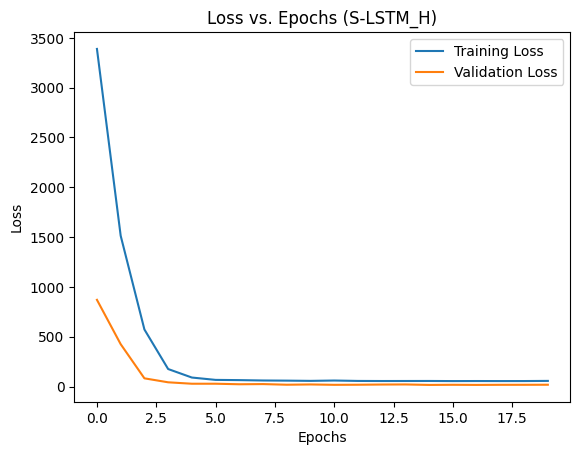

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE: 2.89
MAPE: 0.07
SMAPE: 0.07
MSE: 22.72
RMSE: 4.77
MASE: 4.43
MASEO: 4.43
R2: 0.95
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


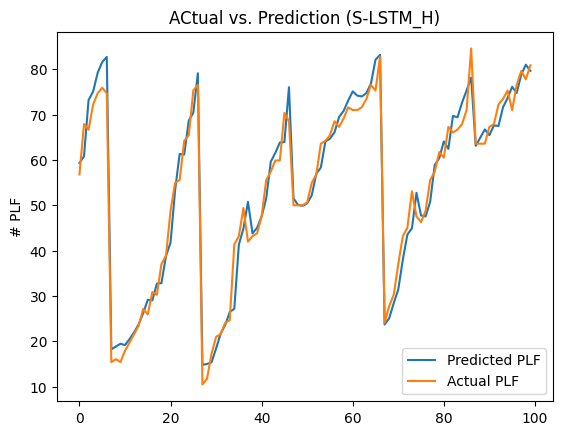

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3779.1155 - mae: 54.3541 - val_loss: 719.0214 - val_mae: 20.7823
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1570.2242 - mae: 33.0788 - val_loss: 524.9234 - val_mae: 19.4776
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 834.8664 - mae: 25.0253 - val_loss: 304.5505 - val_mae: 13.7899
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 407.4135 - mae: 16.3329 - val_loss: 317.6157 - val_mae: 14.4147
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 293.1397 - mae: 13.3656 - val_loss: 262.8258 - val_mae: 12.9526
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 264.0210 - mae: 12.5051 - val_loss: 254.7967 - val_mae: 12.4212
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 251.6526 - mae: 12.0884 - val_loss: 293.3622 - val_mae: 13.7727
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 249.0699 - mae: 12.0331 - val_loss: 250.3401 - val_mae: 12.5620
Epoch 

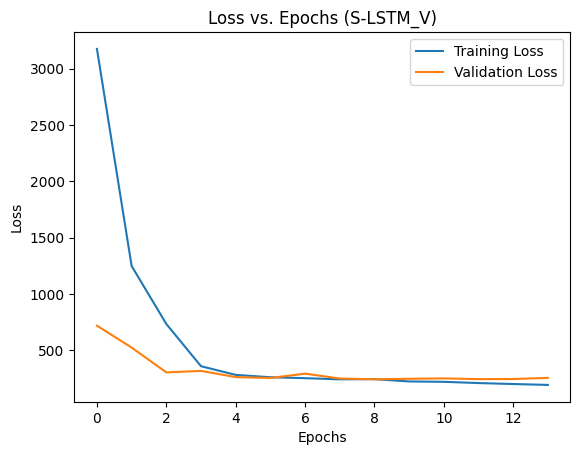

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE: 13.11
MAPE: 0.38
SMAPE: 0.38
MSE: 253.21
RMSE: 15.91
MASE: 3.84
MASEO: 3.84
R2: 0.47
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


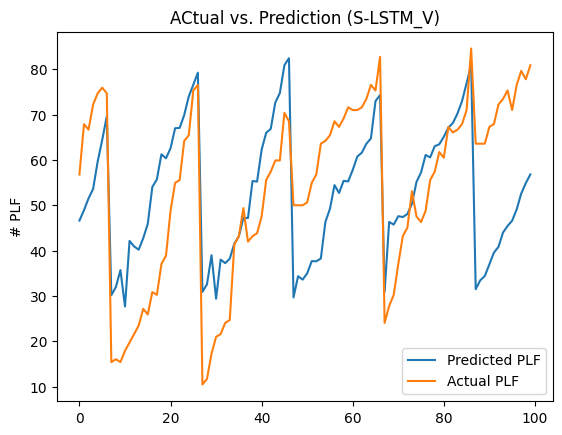

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3513.2598 - mae: 51.5983 - val_loss: 462.9436 - val_mae: 16.3640
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1108.0898 - mae: 27.8269 - val_loss: 169.7521 - val_mae: 10.5102
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 268.4286 - mae: 12.2706 - val_loss: 45.9987 - val_mae: 5.3867
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 91.4583 - mae: 7.3030 - val_loss: 28.8579 - val_mae: 3.9780
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 66.4175 - mae: 6.0991 - val_loss: 30.0376 - val_mae: 4.3186
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 60.8669 - mae: 5.9155 - val_loss: 20.9612 - val_mae: 3.3468
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 64.7470 - mae: 5.9261 - val_loss: 27.2118 - val_mae: 4.0991
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 58.1872 - mae: 5.7541 - val_loss: 19.9991 - val_mae: 3.2950
Epoch 9/30
163/163 ━━━━━━━━━

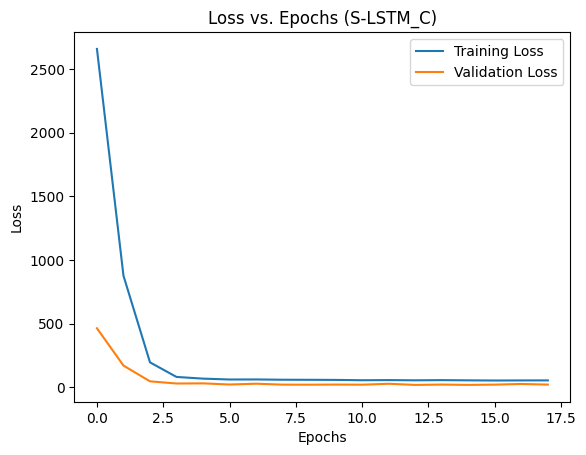

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
MAE: 3.01
MAPE: 0.08
SMAPE: 0.08
MSE: 23.58
RMSE: 4.86
MASE: 4.40
MASEO: 4.40
R2: 0.95
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


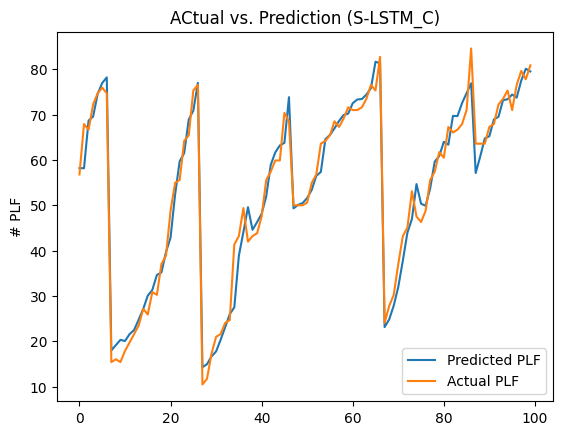

Epoch 1/30


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_21', 'keras_tensor_22']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 3352.6626 - mae: 50.4188 - val_loss: 416.0470 - val_mae: 16.3525
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 940.2927 - mae: 26.2014 - val_loss: 124.0645 - val_mae: 8.7234
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 230.7657 - mae: 11.7473 - val_loss: 39.9139 - val_mae: 4.8211
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 72.8351 - mae: 6.6179 - val_loss: 32.8679 - val_mae: 4.4580
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 56.8424 - mae: 5.6589 - val_loss: 23.7798 - val_mae: 3.6408
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 49.5104 - mae: 5.3426 - val_loss: 23.4868 - val_mae: 3.6715
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 48.2902 - mae: 5.2336 - val_loss: 21.1974 - val_mae: 3.4174
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 47.5765 - mae: 5.1133 - val_loss: 21.1626 - val_mae: 3.4787
Epoch 9/30
163/163 ━━━━━━━━━━━━━━━━━━

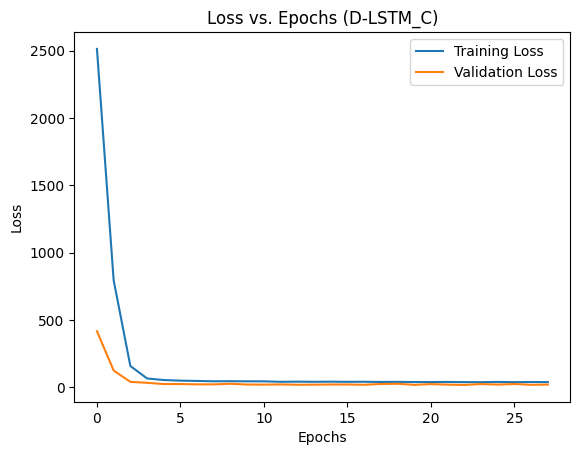

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
MAE: 3.00
MAPE: 0.08
SMAPE: 0.08
MSE: 24.06
RMSE: 4.90
MASE: 4.46
MASEO: 4.46
R2: 0.95
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


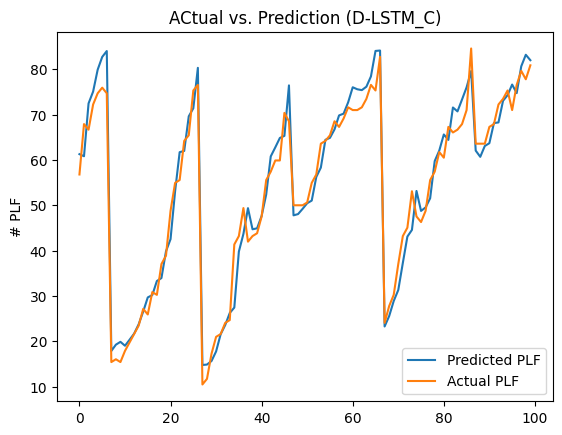

In [59]:
h_window_size = 9 
v_window_size = 9 
predict_days_before = 0

# processed dataset
X_horizontal,X_vertical,X_combined, y, dates, remaining_days = df_to_X_y_with_separated_sequences_same_window(df = processed_input_df, h_window_size = h_window_size, v_window_size=v_window_size, predict_days_before = predict_days_before)

# splitting 
X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled = dataset_splitting_X(X_horizontal,dates,horizontal_feature_names,"Horizontal")
X_vertical_train, X_vertical_val, X_vertical_test, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled  = dataset_splitting_X(X_vertical,dates,vertical_feature_names,"Vertical")
X_combined_train, X_combined_val, X_combined_test, \
    X_combined_train_scaled, X_combined_val_scaled, X_combined_test_scaled  = dataset_splitting_X(X_combined,dates,combined_feature_names,"Combined")
y_train, y_val, y_test, date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test = dataset_splitting_others(y, dates, remaining_days)

# model output: S-LSTM_H, S-LSTM_V, S-LSTM_C, D-LSTM_C
dev_train_eval_single_LSTM_model(X_horizontal_train, X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, y_train, y_val, y_test, "S-LSTM_H")
dev_train_eval_single_LSTM_model(X_vertical_train, X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled, y_train, y_val, y_test, "S-LSTM_V")
dev_train_eval_single_LSTM_model(X_combined_train, X_combined_train_scaled, X_combined_val_scaled, X_combined_test_scaled, y_train, y_val, y_test, "S-LSTM_C")
dev_train_eval_dual_LSTM_model(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, "D-LSTM_C")


<h2>Varying Window_size</h2>


🔍 [Horizontal] Numerical Features (5): ['plf', 'total_RPK', 'rolling_avg_plf', 'days_before_departure', 'record_date_day_of_year']
🔍 [Horizontal] Categorical Features (3): ['record_date_day', 'flight_date_day', 'flight_date_is_holiday']

🔍 [Vertical] Numerical Features (6): ['plf', 'total_RPK', 'plf_historical', 'rolling_avg_plf', 'flight_date_day_of_year', 'flight_date_week']
🔍 [Vertical] Categorical Features (3): ['flight_date_day', 'flight_date_is_holiday', 'flight_date_is_weekend']
Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 3891.3015 - mae: 55.4166 - val_loss: 776.8092 - val_mae: 21.7788 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1677.1136 - mae: 34.0688 - val_loss: 468.5068 - val_mae: 18.3020 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 861.3267 - mae: 25.3443 - val_loss: 124.0144 - val_mae: 8.5499 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss

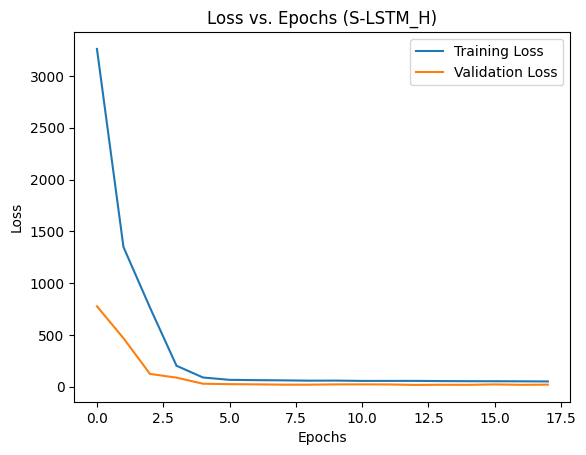

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
MAE: 3.07
MAPE: 0.08
SMAPE: 0.08
MSE: 23.46
RMSE: 4.84
MASE: 4.46
MASEO: 4.46
R2: 0.95
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


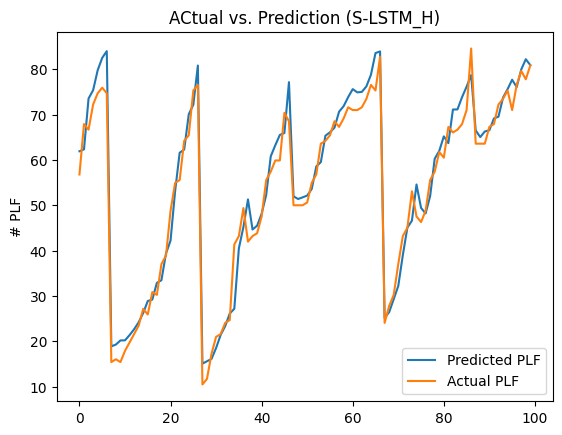

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 3647.6841 - mae: 53.0644 - val_loss: 454.1488 - val_mae: 16.2710 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1008.0631 - mae: 26.0363 - val_loss: 330.3634 - val_mae: 14.8051 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 378.1922 - mae: 15.6555 - val_loss: 277.0720 - val_mae: 12.8576 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 276.2938 - mae: 12.9195 - val_loss: 255.5253 - val_mae: 12.3282 - learning_rate: 0.0010
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 271.1442 - mae: 12.5050 - val_loss: 254.3749 - val_mae: 12.5249 - learning_rate: 0.0010
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 243.7705 - mae: 11.9374 - val_loss: 275.1340 - val_mae: 13.2220 - learning_rate: 0.0010
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 242.5456 - mae: 11.8054 - val_loss: 244.07

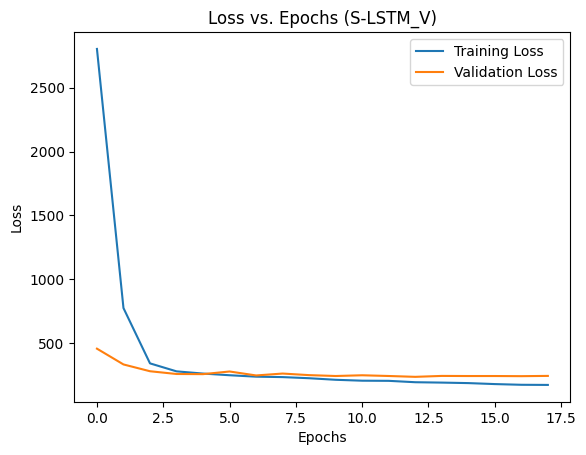

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
MAE: 12.70
MAPE: 0.35
SMAPE: 0.35
MSE: 250.64
RMSE: 15.83
MASE: 3.90
MASEO: 3.90
R2: 0.47
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


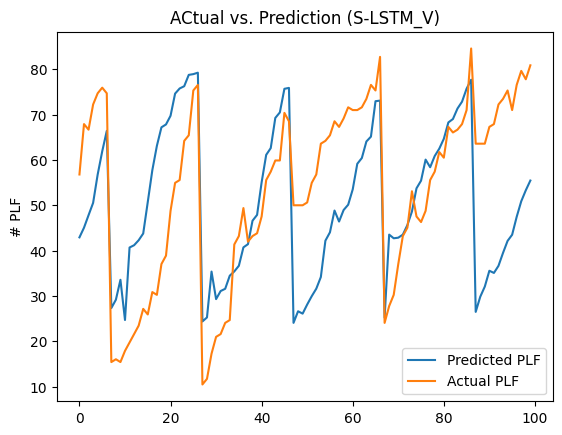

Epoch 1/30


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_454', 'keras_tensor_455']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 3418.9858 - mae: 50.8021 - val_loss: 406.0915 - val_mae: 16.6188 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 698.0674 - mae: 21.8398 - val_loss: 140.6723 - val_mae: 9.2922 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 145.2475 - mae: 9.4713 - val_loss: 55.4235 - val_mae: 5.8249 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 64.6880 - mae: 6.1742 - val_loss: 32.2978 - val_mae: 4.3327 - learning_rate: 0.0010
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 51.5423 - mae: 5.4927 - val_loss: 31.0592 - val_mae: 4.4338 - learning_rate: 0.0010
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 47.9653 - mae: 5.2974 - val_loss: 20.5926 - val_mae: 3.3894 - learning_rate: 0.0010
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 44.7849 - mae: 5.0617 - val_loss: 21.3333 - val_mae: 3.5252 - learning

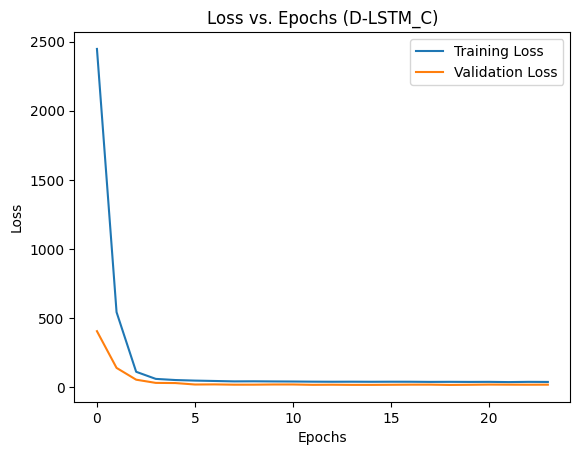

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
MAE: 2.99
MAPE: 0.08
SMAPE: 0.08
MSE: 23.69
RMSE: 4.87
MASE: 4.46
MASEO: 4.46
R2: 0.95
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


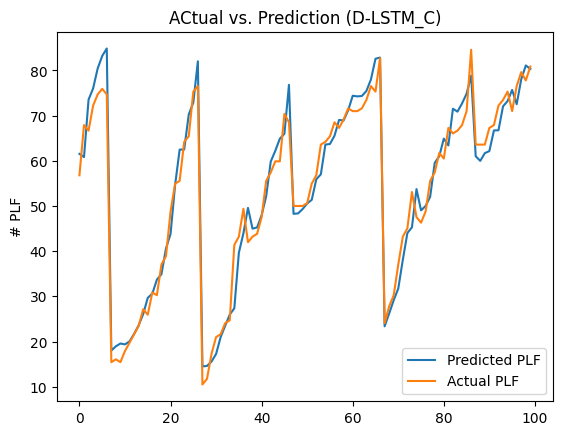

Epoch 1/30


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_467', 'keras_tensor_468']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 2245.3262 - mae: 37.2746 - val_loss: 80.5085 - val_mae: 7.0090 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 77.9913 - mae: 6.7115 - val_loss: 41.7596 - val_mae: 5.0457 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 50.6324 - mae: 5.3206 - val_loss: 32.3880 - val_mae: 4.2836 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 46.1053 - mae: 5.0358 - val_loss: 25.7680 - val_mae: 3.7620 - learning_rate: 0.0010
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 44.6485 - mae: 4.8596 - val_loss: 29.1417 - val_mae: 4.0636 - learning_rate: 0.0010
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 39.2734 - mae: 4.6157 - val_loss: 24.9977 - val_mae: 3.6998 - learning_rate: 0.0010
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 37.2977 - mae: 4.4441 - val_loss: 24.5600 - val_mae: 3.6283 - learning_rate:

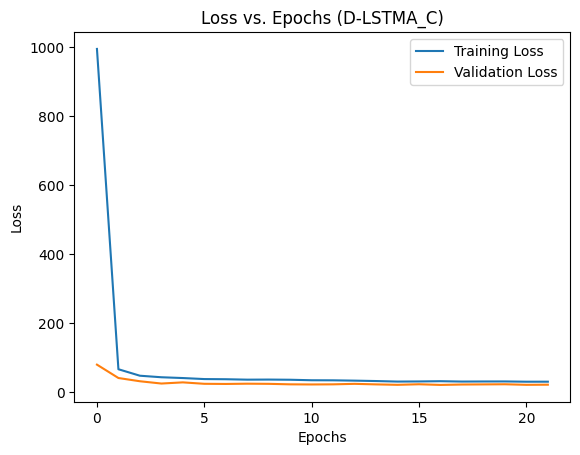

35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step
MAE: 3.50
MAPE: 0.09
SMAPE: 0.09
MSE: 33.79
RMSE: 5.81
MASE: 4.35
MASEO: 4.35
R2: 0.93
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


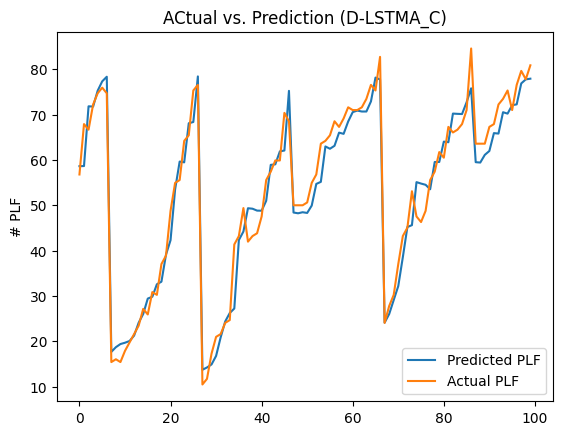

Epoch 1/30


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_490', 'keras_tensor_491']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - loss: 2520.0286 - mae: 40.5526 - val_loss: 60.9687 - val_mae: 6.0614 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 84.3672 - mae: 6.9204 - val_loss: 53.1777 - val_mae: 5.7342 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 61.7484 - mae: 5.8974 - val_loss: 39.7663 - val_mae: 4.7752 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 54.2656 - mae: 5.4443 - val_loss: 27.8626 - val_mae: 3.7742 - learning_rate: 0.0010
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 46.0308 - mae: 5.0482 - val_loss: 28.2973 - val_mae: 3.9554 - learning_rate: 0.0010
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 43.8218 - mae: 4.9120 - val_loss: 25.1563 - val_mae: 3.6792 - learning_rate: 0.0010
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 42.2829 - mae: 4.8064 - val_loss: 23.9903 - val_mae: 3.5141 - learning_rate:

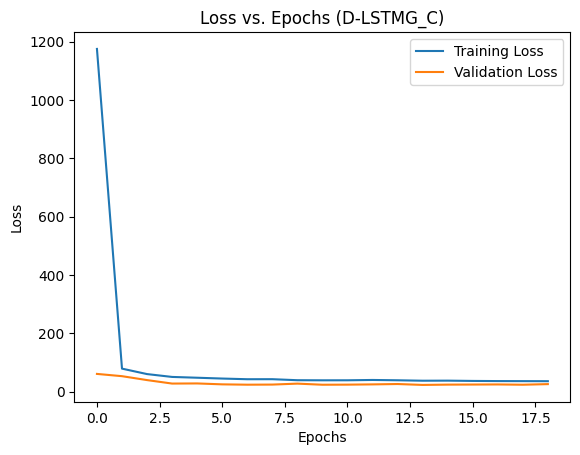

35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step
MAE: 3.44
MAPE: 0.08
SMAPE: 0.08
MSE: 34.24
RMSE: 5.85
MASE: 4.39
MASEO: 4.39
R2: 0.93
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


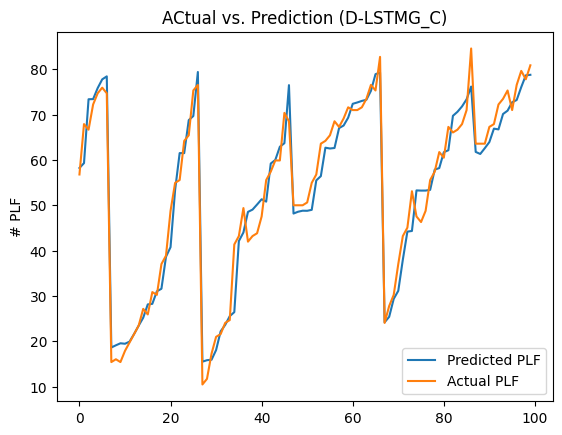

Epoch 1/30


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_525', 'keras_tensor_526']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - loss: 2244.3420 - mae: 37.3278 - val_loss: 77.3498 - val_mae: 6.9161 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 72.8908 - mae: 6.5544 - val_loss: 40.7713 - val_mae: 4.9091 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 51.4010 - mae: 5.4140 - val_loss: 31.4617 - val_mae: 4.2121 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 44.4185 - mae: 4.9537 - val_loss: 33.8335 - val_mae: 4.5152 - learning_rate: 0.0010
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 42.8094 - mae: 4.8783 - val_loss: 29.1968 - val_mae: 4.1662 - learning_rate: 0.0010
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 38.8706 - mae: 4.5737 - val_loss: 28.1330 - val_mae: 3.9905 - learning_rate: 0.0010
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 40.0614 - mae: 4.4830 - val_loss: 26.1765 - val_mae: 3.7884 - learning_rate:

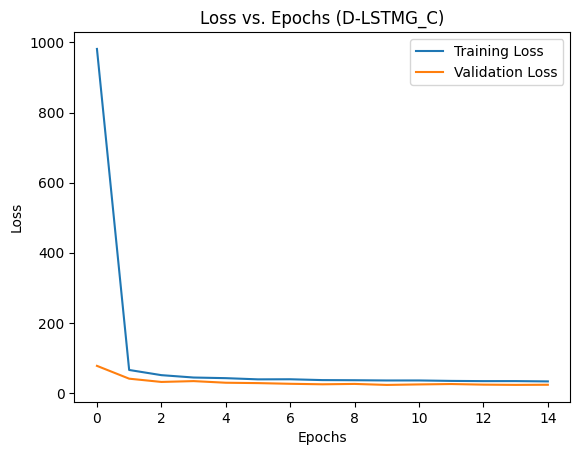

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step
MAE: 3.68
MAPE: 0.09
SMAPE: 0.09
MSE: 36.07
RMSE: 6.01
MASE: 4.34
MASEO: 4.34
R2: 0.92
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


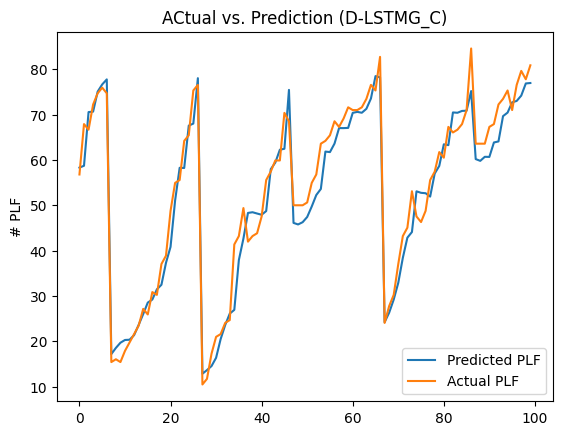

Epoch 1/30


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_549', 'keras_tensor_550']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - loss: 3362.0801 - mae: 50.3050 - val_loss: 352.4791 - val_mae: 15.5681 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 429.0775 - mae: 16.7435 - val_loss: 144.3698 - val_mae: 9.7458 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 104.9537 - mae: 7.9725 - val_loss: 86.5396 - val_mae: 7.4327 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 72.0814 - mae: 6.4308 - val_loss: 78.6294 - val_mae: 7.1730 - learning_rate: 0.0010
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 57.3176 - mae: 5.6025 - val_loss: 60.2899 - val_mae: 6.2436 - learning_rate: 0.0010
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 50.5144 - mae: 5.2607 - val_loss: 54.6531 - val_mae: 5.6604 - learning_rate: 0.0010
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 47.6203 - mae: 5.0475 - val_loss: 51.4205 - val_mae: 5.6517 - learning

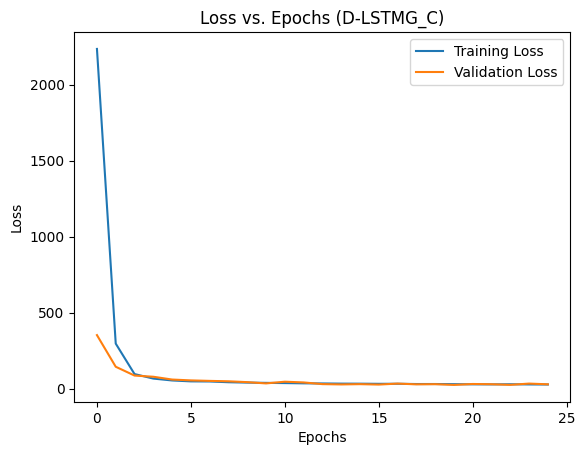

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
MAE: 3.71
MAPE: 0.09
SMAPE: 0.09
MSE: 40.11
RMSE: 6.33
MASE: 4.42
MASEO: 4.42
R2: 0.92
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


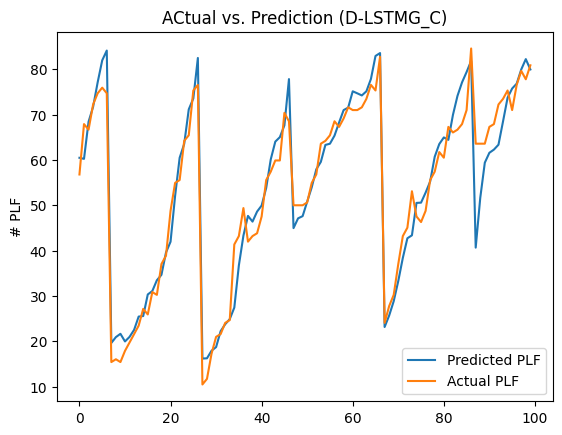

In [140]:
h_window_size = 9 
v_window_size = 5 
predict_days_before = 0

# processed dataset
X_horizontal,X_vertical, y, dates, remaining_days = df_to_X_y_with_separated_sequences_varying_window(df = processed_input_df, h_window_size = h_window_size, v_window_size=v_window_size, predict_days_before = predict_days_before)

# splitting 
X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled = dataset_splitting_X(X_horizontal,dates,horizontal_feature_names,"Horizontal")
X_vertical_train, X_vertical_val, X_vertical_test, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled  = dataset_splitting_X(X_vertical,dates,vertical_feature_names,"Vertical")
y_train, y_val, y_test, date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test = dataset_splitting_others(y, dates, remaining_days)

# model output: S-LSTM_H, S-LSTM_V, D-LSTM_C
dev_train_eval_single_LSTM_model(X_horizontal_train, X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, y_train, y_val, y_test, "S-LSTM_H")
dev_train_eval_single_LSTM_model(X_vertical_train, X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled, y_train, y_val, y_test, "S-LSTM_V")
dev_train_eval_dual_LSTM_model(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, "D-LSTM_C")
dev_train_eval_dual_LSTM_model_with_attention(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, "D-LSTMA_C")
dev_train_eval_dual_LSTM_model_with_gating(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, "D-LSTMG_C")
dev_train_eval_dual_LSTM_model_with_attention_residual_fusion(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, "D-LSTMG_C")
dev_train_eval_dual_LSTM_model_with_residual_fusion(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, "D-LSTMG_C")

Epoch 1/30


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_123', 'keras_tensor_124']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 2056.2056 - mae: 35.2003 - val_loss: 73.7891 - val_mae: 6.7958
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 75.5826 - mae: 6.5752 - val_loss: 41.2055 - val_mae: 4.9465
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 53.7515 - mae: 5.4502 - val_loss: 32.0122 - val_mae: 4.3151
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 43.0768 - mae: 4.9170 - val_loss: 31.7538 - val_mae: 4.2267
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 45.3178 - mae: 4.9536 - val_loss: 25.3424 - val_mae: 3.7132
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 37.8953 - mae: 4.4950 - val_loss: 23.7594 - val_mae: 3.5435
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 40.5941 - mae: 4.4978 - val_loss: 24.4760 - val_mae: 3.6071
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 37.8147 - mae: 4.4444 - val_loss: 24.0437 - val_mae: 3.5313
Epoch 9/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/

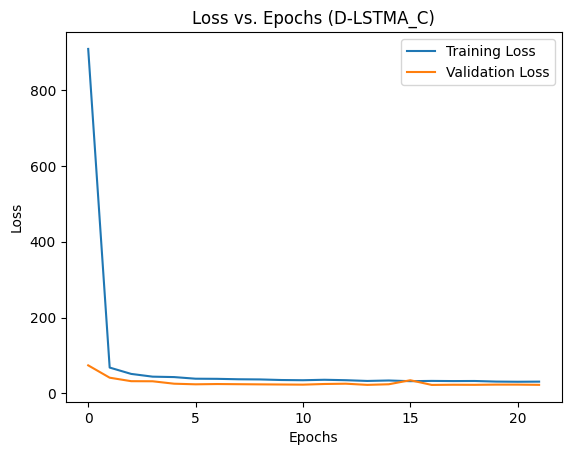

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
MAE: 3.37
MAPE: 0.08
SMAPE: 0.08
MSE: 33.18
RMSE: 5.76
MASE: 4.43
MASEO: 4.43
R2: 0.93
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


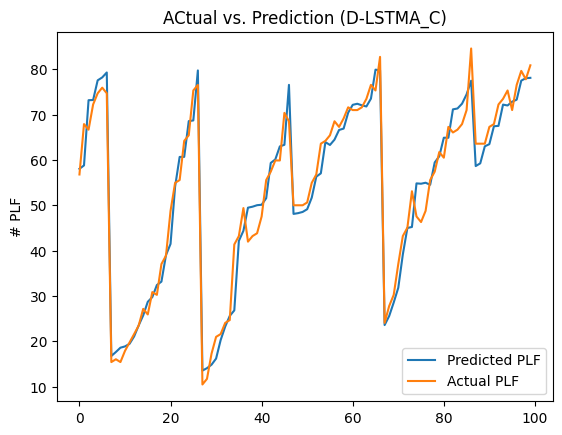

In [68]:
dev_train_eval_dual_LSTM_model_with_attention(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, "D-LSTMA_C")

Epoch 1/30


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_405', 'keras_tensor_406']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - loss: 2540.7805 - mae: 40.7824 - val_loss: 58.6554 - val_mae: 5.9016 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 71.1844 - mae: 6.3759 - val_loss: 42.5317 - val_mae: 5.1092 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 56.1271 - mae: 5.6316 - val_loss: 29.6222 - val_mae: 4.0327 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 47.7614 - mae: 5.1649 - val_loss: 27.4217 - val_mae: 3.9158 - learning_rate: 0.0010
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 45.3398 - mae: 4.9882 - val_loss: 24.5431 - val_mae: 3.5625 - learning_rate: 0.0010
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 43.2521 - mae: 4.8066 - val_loss: 23.7210 - val_mae: 3.4575 - learning_rate: 0.0010
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 43.5154 - mae: 4.7709 - val_loss: 25.3586 - val_mae: 3.7244 - learning_rate:

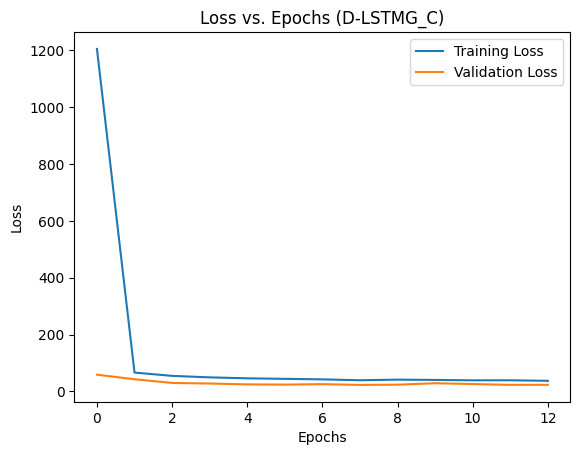

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step
MAE: 3.46
MAPE: 0.08
SMAPE: 0.08
MSE: 34.73
RMSE: 5.89
MASE: 4.43
MASEO: 4.43
R2: 0.93
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


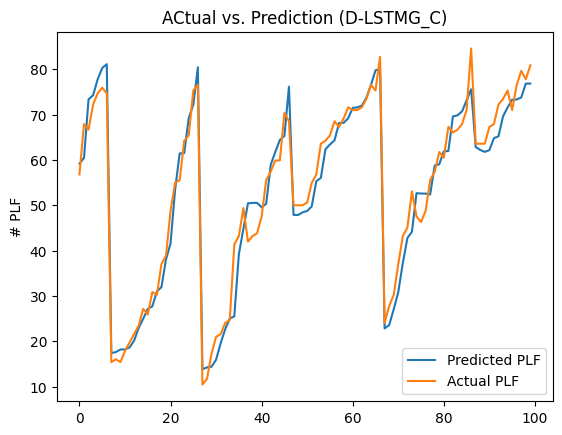

In [137]:
dev_train_eval_dual_LSTM_model_with_gating(X_horizontal_train, X_vertical_train, \
    X_horizontal_train_scaled,X_horizontal_val_scaled,X_horizontal_test_scaled,\
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    y_train, y_val, y_test, "D-LSTMG_C")

<h2>Splitting Dataset</h2>

In [59]:
len(dates), len(X_horizontal), len(X_vertical), X_horizontal.shape, X_vertical.shape

(7444, 7444, 7444, (7444, 9, 8), (7444, 9, 9))

In [ ]:
X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_vertical_train, X_vertical_val, X_vertical_test, \
    X_combined_train, X_combined_val, X_combined_test, \
    y_train, y_val, y_test, \
    date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    X_combined_train_scaled, X_combined_val_scaled, X_combined_test_scaled = dataset_splitting_furnished_airRM(X_horizontal, X_vertical, X_combined, y, dates, remaining_days, h_f_names, v_f_names)

print(f"\n🧪 Final Sanity Check:")
print(f"X_horizontal_train_scaled.shape: {X_horizontal_train_scaled.shape}")
print(f"X_horizontal_val_scaled.shape:   {X_horizontal_val_scaled.shape}")
print(f"X_horizontal_test_scaled.shape:  {X_horizontal_test_scaled.shape}")
print(f"Sum = {X_horizontal_train_scaled.shape[0] + X_horizontal_val_scaled.shape[0] + X_horizontal_test_scaled.shape[0]}")
print(f"X_vertical_train_scaled.shape: {X_vertical_train_scaled.shape}")
print(f"X_vertical_val_scaled.shape:   {X_vertical_val_scaled.shape}")
print(f"X_vertical_test_scaled.shape:  {X_vertical_test_scaled.shape}")
print(f"Sum = {X_vertical_train_scaled.shape[0] + X_vertical_val_scaled.shape[0] + X_vertical_test_scaled.shape[0]}")
print(f"X_combined_train_scaled.shape: {X_combined_train_scaled.shape}")
print(f"X_combined_val_scaled.shape:   {X_combined_val_scaled.shape}")
print(f"X_combined_test_scaled.shape:  {X_combined_test_scaled.shape}")
print(f"Sum = {X_combined_train_scaled.shape[0] + X_combined_val_scaled.shape[0] + X_combined_test_scaled.shape[0]}")


(66996, 8)
(66996, 9)
(66996, 17)

🔍 [Horizontal] Numerical Features (5): ['plf', 'total_RPK', 'rolling_avg_plf', 'days_before_departure', 'record_date_day_of_year']
🔍 [Horizontal] Categorical Features (3): ['record_date_day', 'flight_date_day', 'flight_date_is_holiday']

🔍 [Vertical] Numerical Features (6): ['plf', 'total_RPK', 'plf_historical', 'rolling_avg_plf', 'flight_date_day_of_year', 'flight_date_week']
🔍 [Vertical] Categorical Features (3): ['flight_date_day', 'flight_date_is_holiday', 'flight_date_is_weekend']

🔍 [Combined] Numerical Features (11): ['H_plf', 'H_total_RPK', 'H_rolling_avg_plf', 'H_days_before_departure', 'H_record_date_day_of_year', 'plf', 'total_RPK', 'plf_historical', 'rolling_avg_plf', 'flight_date_day_of_year', 'flight_date_week']
🔍 [Combined] Categorical Features (6): ['H_record_date_day', 'H_flight_date_day', 'H_flight_date_is_holiday', 'flight_date_day', 'flight_date_is_holiday', 'flight_date_is_weekend']

🔍 Splitting Debug:
Total samples: 7444
Train en

<h2>Model Output</h2>

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3489.2876 - mae: 51.6443 - val_loss: 457.9528 - val_mae: 16.3191
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1068.7778 - mae: 27.2097 - val_loss: 99.3561 - val_mae: 7.4131
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 219.2007 - mae: 11.1548 - val_loss: 48.0373 - val_mae: 5.4760
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 82.6549 - mae: 6.8959 - val_loss: 25.0833 - val_mae: 3.8031
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 65.7318 - mae: 6.1581 - val_loss: 30.9666 - val_mae: 4.3427
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 63.6749 - mae: 5.9543 - val_loss: 21.8803 - val_mae: 3.5673
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 58.7517 - mae: 5.7724 - val_loss: 24.8014 - val_mae: 3.9373
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 58.9866 - mae: 5.7026 - val_loss: 18.9585 - val_mae: 3.1640
Epoch 9/30
163/163 ━━━━━━━━━━━

c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_21', 'keras_tensor_22']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 3145.6084 - mae: 48.1856 - val_loss: 532.2836 - val_mae: 19.6212
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 655.2220 - mae: 21.4218 - val_loss: 84.1877 - val_mae: 7.5182
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 92.5067 - mae: 7.6022 - val_loss: 34.0470 - val_mae: 4.4546
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 57.7844 - mae: 5.8534 - val_loss: 38.6687 - val_mae: 5.0715
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 50.3807 - mae: 5.4812 - val_loss: 28.0888 - val_mae: 4.0909
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 51.5151 - mae: 5.3483 - val_loss: 24.7641 - val_mae: 3.8246
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 47.7236 - mae: 5.2034 - val_loss: 33.6671 - val_mae: 4.7451
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 46.3975 - mae: 5.1673 - val_loss: 24.4382 - val_mae: 3.8355
Epoch 9/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 

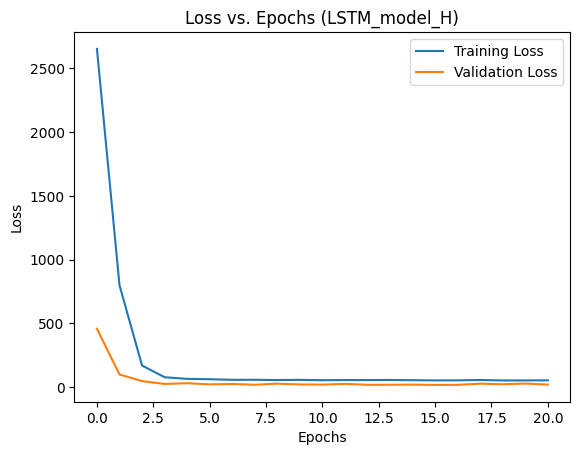

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
MAE: 3.02
MAPE: 0.08
SMAPE: 0.08
MSE: 22.84
RMSE: 4.78
MASE: 4.45
MASEO: 4.45
R2: 0.95
35/35 - 0s - 3ms/step - loss: 245.0529 - mae: 12.2541
Test Loss: 245.05287170410156, Test MAE: 12.254137992858887


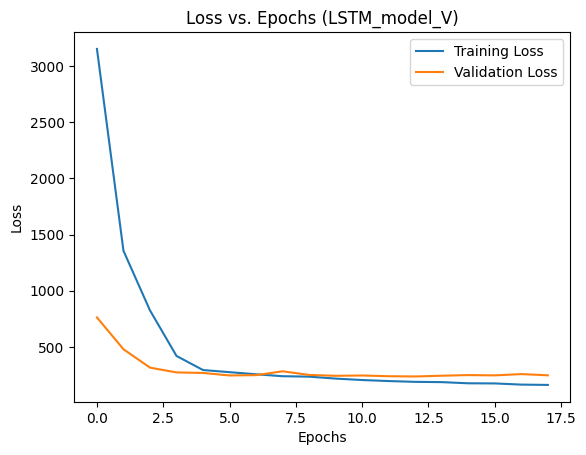

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
MAE: 12.25
MAPE: 0.32
SMAPE: 0.32
MSE: 245.05
RMSE: 15.65
MASE: 3.93
MASEO: 3.93
R2: 0.48
35/35 - 0s - 3ms/step - loss: 26.9100 - mae: 3.2628
Test Loss: 26.91000747680664, Test MAE: 3.262847423553467


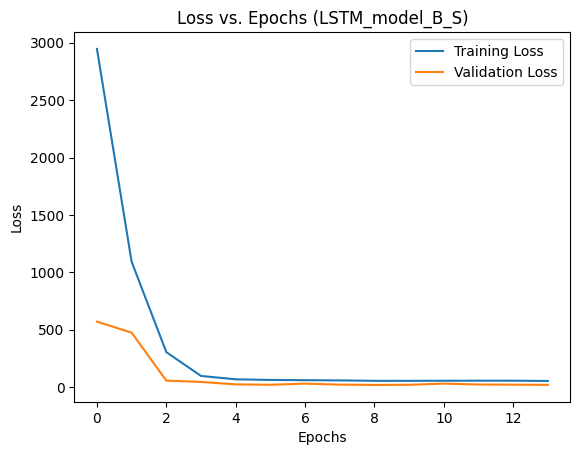

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
MAE: 3.26
MAPE: 0.08
SMAPE: 0.08
MSE: 26.91
RMSE: 5.19
MASE: 4.43
MASEO: 4.43
R2: 0.94
35/35 - 0s - 3ms/step - loss: 24.4573 - mae: 3.1659
Test Loss: 24.457313537597656, Test MAE: 3.1658945083618164


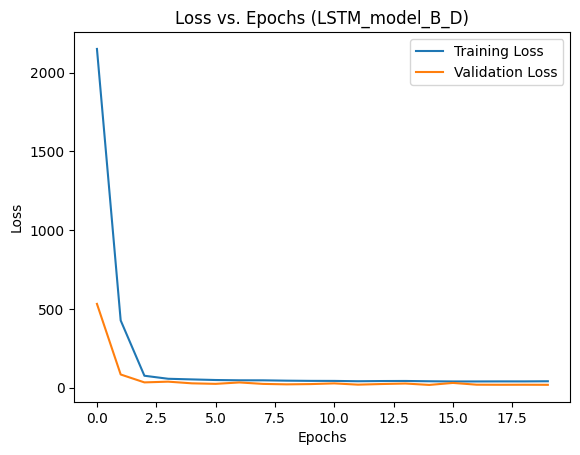

c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_21', 'keras_tensor_22']. Received: the structure of inputs=('*', '*')
  warnings.warn(


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
MAE: 3.17
MAPE: 0.09
SMAPE: 0.09
MSE: 24.46
RMSE: 4.95
MASE: 4.34
MASEO: 4.34
R2: 0.95
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


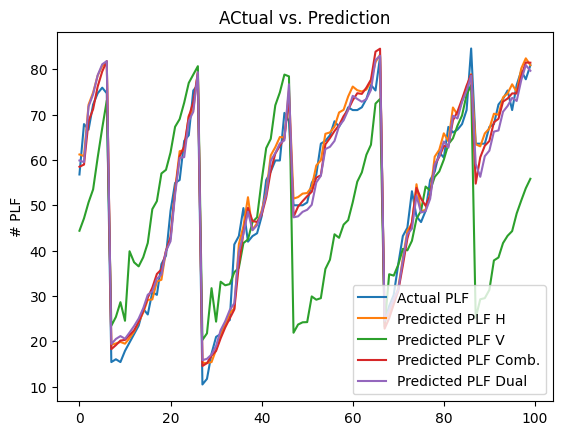

In [80]:
model_development_furnished_airRM(X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_vertical_train, X_vertical_val, X_vertical_test, \
    X_combined_train, X_combined_val, X_combined_test, \
    y_train, y_val, y_test, \
    date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled,\
    X_combined_train_scaled, X_combined_val_scaled, X_combined_test_scaled)

In [ ]:
# model_development_initial_airRM(X_train, X_val, X_test, y_train, y_val, y_test, \
#     date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, \
#     X_train_scaled, X_val_scaled, X_test_scaled)

(5210, 9, 8)
(1117, 9, 8)
(1117, 9, 8)
(5210, 9, 4)
(1117, 9, 4)
(1117, 9, 4)
Epoch 1/50


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_20', 'keras_tensor_21']. Received: the structure of inputs=('*', '*')
  warnings.warn(


163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 3505.6052 - mae: 52.0223 - val_loss: 420.7657 - val_mae: 16.9354
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 707.2567 - mae: 21.7863 - val_loss: 104.7094 - val_mae: 8.4059
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 119.4827 - mae: 8.7202 - val_loss: 54.5546 - val_mae: 5.7570
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 57.3711 - mae: 5.9422 - val_loss: 47.9945 - val_mae: 5.6900
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 56.0729 - mae: 5.8044 - val_loss: 34.2377 - val_mae: 4.6614
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 49.3013 - mae: 5.3637 - val_loss: 29.5804 - val_mae: 4.1475
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 49.4930 - mae: 5.3799 - val_loss: 23.8070 - val_mae: 3.7820
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 44.8045 - mae: 5.0525 - val_loss: 21.6765 - val_mae: 3.4977
Epoch 9/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1

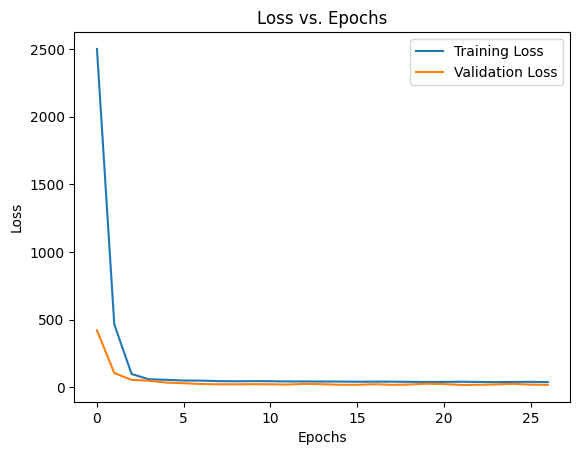

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
MAE: 2.98
MAPE: 0.08
SMAPE: 0.08
MSE: 23.15
RMSE: 4.81
MASE: 4.39
MASEO: 4.39
R2: 0.95
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


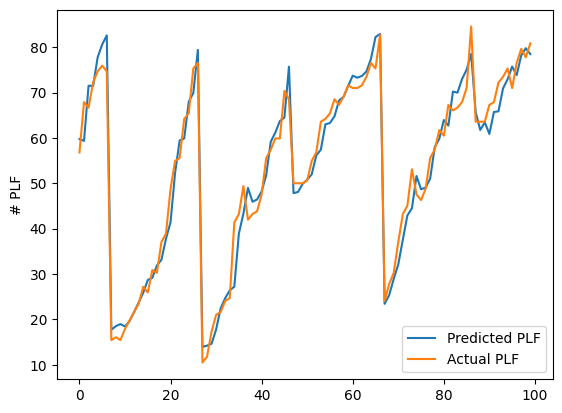

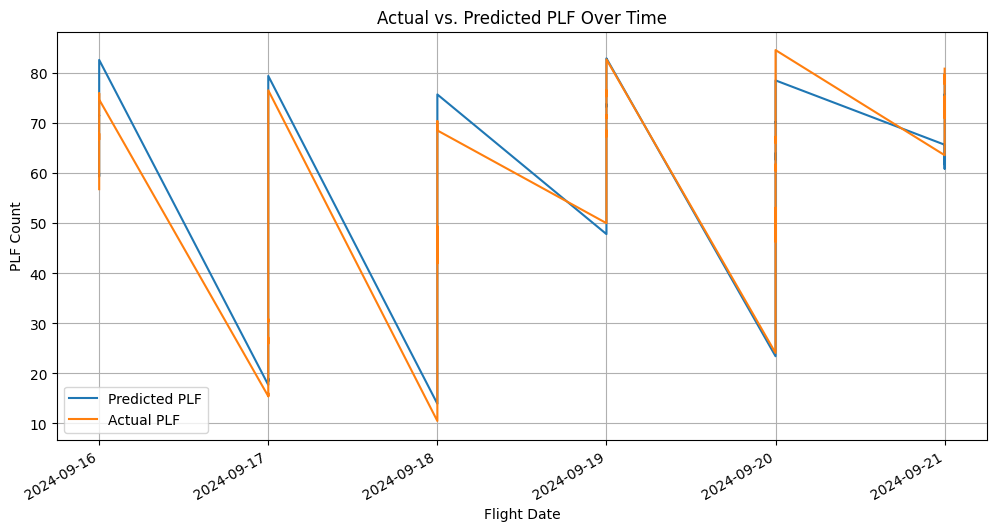

<Figure size 1200x600 with 0 Axes>

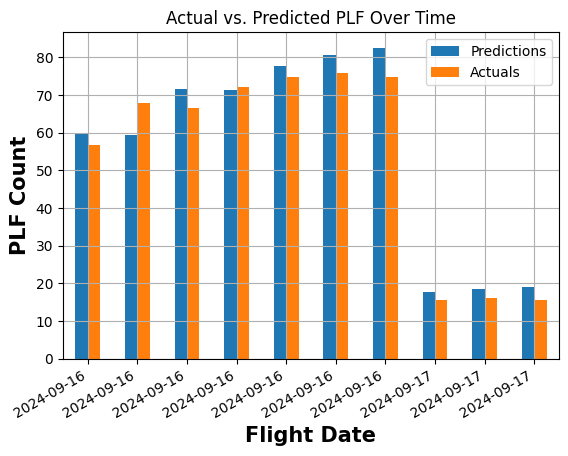

In [ ]:
# processed_input_df = data_preparation_furnished_airRM()
X_horizontal, X_vertical, y, dates, remaining_days = dataset_preparation_furnished_airRM(processed_input_df)
X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_vertical_train, X_vertical_val, X_vertical_test, \
    y_train, y_val, y_test, \
    date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled = dataset_splitting_furnished_airRM(X_horizontal, X_vertical, y, dates, remaining_days)
model_development_furnished_airRM(X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_vertical_train, X_vertical_val, X_vertical_test, \
    y_train, y_val, y_test, \
    date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled)

In [50]:
X[0]

array([[1.00000000e+02, 2.54068000e+05, 9.63000000e+01, 1.00000000e+01,
        1.00000000e+00, 4.00000000e+00, 2.06000000e+02, 0.00000000e+00,
        1.00000000e+02, 9.69100000e+01, 9.63000000e+01, 2.00000000e+00],
       [9.69100000e+01, 2.46227000e+05, 1.00000000e+02, 9.00000000e+00,
        2.00000000e+00, 4.00000000e+00, 2.07000000e+02, 0.00000000e+00,
        9.93800000e+01, 1.00000000e+02, 9.93800000e+01, 3.00000000e+00],
       [9.81500000e+01, 2.49363000e+05, 9.84550000e+01, 8.00000000e+00,
        3.00000000e+00, 4.00000000e+00, 2.08000000e+02, 0.00000000e+00,
        9.93800000e+01, 9.96900000e+01, 9.93800000e+01, 4.00000000e+00],
       [1.00000000e+02, 2.54068000e+05, 9.83533333e+01, 7.00000000e+00,
        4.00000000e+00, 4.00000000e+00, 2.09000000e+02, 0.00000000e+00,
        1.00000000e+02, 9.95866667e+01, 1.00000000e+02, 5.00000000e+00],
       [1.00000000e+02, 2.54068000e+05, 9.87650000e+01, 6.00000000e+00,
        5.00000000e+00, 4.00000000e+00, 2.10000000e+02, 0.00

In [52]:
X.shape, X.dtype

((7444, 9, 12), dtype('float64'))

(5210, 9, 13)
(1117, 9, 13)
(1117, 9, 13)
Epoch 1/50


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 3900.8706 - mae: 55.5327 - val_loss: 690.9874 - val_mae: 20.2846
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1536.6907 - mae: 32.6501 - val_loss: 172.8318 - val_mae: 9.7139
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 448.9652 - mae: 15.9985 - val_loss: 57.8689 - val_mae: 5.7080
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 128.9229 - mae: 8.6357 - val_loss: 61.1575 - val_mae: 6.3740
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 72.6516 - mae: 6.4899 - val_loss: 29.5255 - val_mae: 4.1994
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 63.5170 - mae: 5.9541 - val_loss: 27.7514 - val_mae: 4.0793
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 62.3130 - mae: 5.8758 - val_loss: 28.3360 - val_mae: 4.0609
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 61.9366 - mae: 5.8575 - val_loss: 32.9056 - val_mae: 4.5032
Epoch 9/50
163/163 ━━━━━━━━━━━━━━

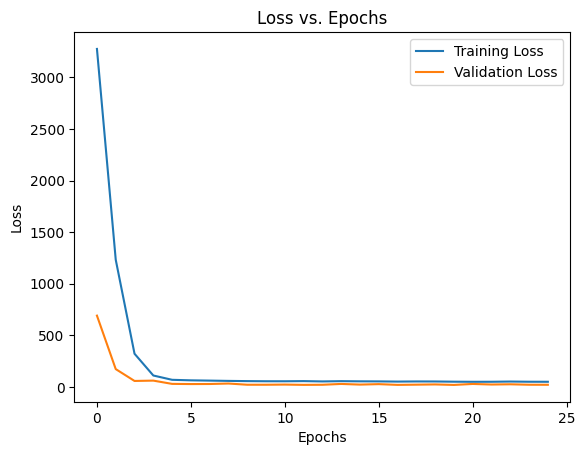

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
MAE: 3.30
MAPE: 0.09
SMAPE: 0.09
MSE: 24.26
RMSE: 4.93
MASE: 4.43
MASEO: 4.43
R2: 0.95
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


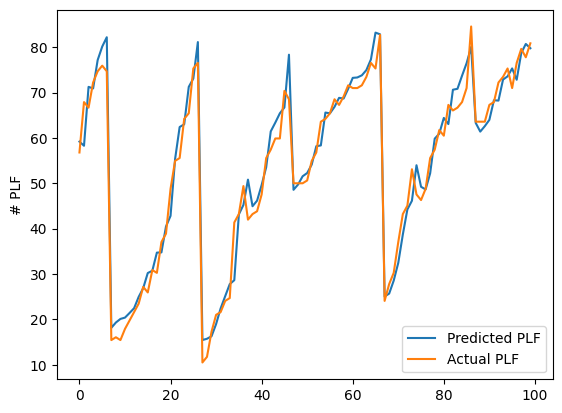

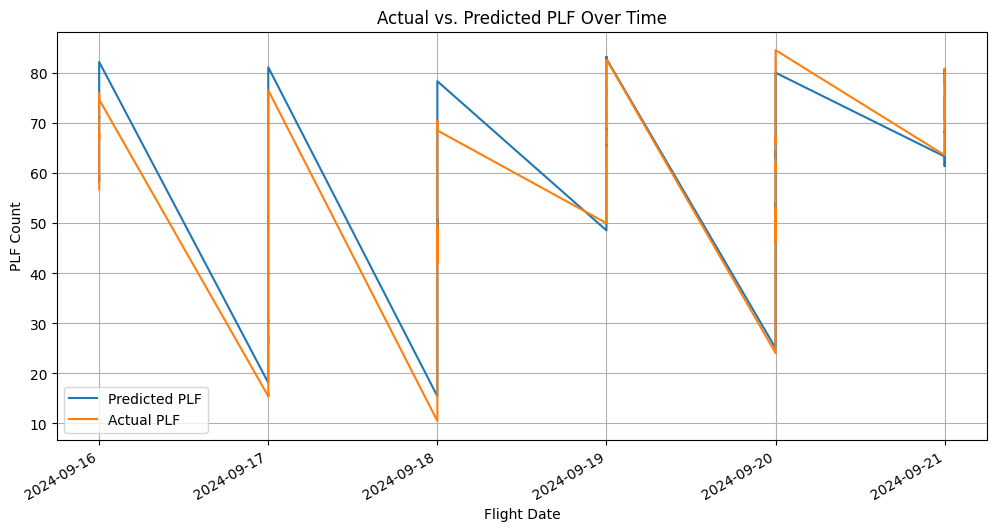

<Figure size 1200x600 with 0 Axes>

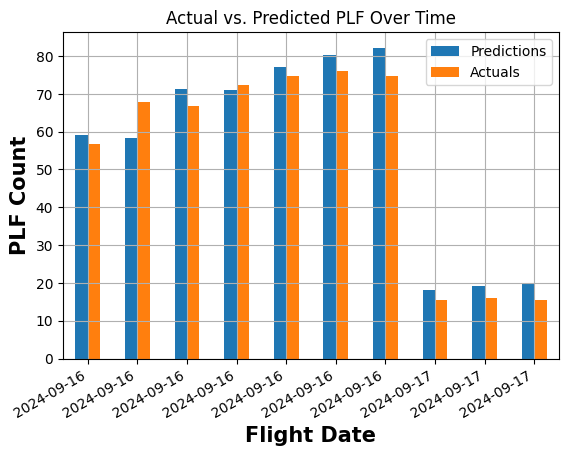

In [215]:

X, y, dates, remaining_days = dataset_preparation_initial_airRM_temp(processed_input_df)
X_train, X_val, X_test, y_train, y_val, y_test, \
    date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, \
    X_train_scaled, X_val_scaled, X_test_scaled = dataset_splitting_initial_airRM_temp(X, y, dates, remaining_days)
model_development_initial_airRM(X_train, X_val, X_test, y_train, y_val, y_test, \
    date_train, date_val, date_test, r_days_train, r_days_val, r_days_test, \
    X_train_scaled, X_val_scaled, X_test_scaled)

<h1>Finding data co-relations</h1>

In [87]:
processed_input_df.dtypes

flight_no                            object
route                                object
flight_date                  datetime64[ns]
total_seat                            int64
total_booked                          int64
total_distance                      float64
total_RPK                           float64
total_ASK                           float64
plf                                 float64
record_date                  datetime64[ns]
days_before_departure                 int64
flight_date_day                       int32
record_date_day                       int32
flight_date_day_sin                 float64
flight_date_day_cos                 float64
record_date_day_sin                 float64
record_date_day_cos                 float64
flight_date_month_sin               float64
flight_date_month_cos               float64
record_date_month_sin               float64
record_date_month_cos               float64
flight_date_month_day_sin           float64
flight_date_month_day_cos       

In [168]:

# Assuming `data` is the dataframe you used to create (X, y)
# Step 1: Convert categorical and datetime columns to numeric or remove them
data = processed_input_df.copy()

# If 'flight_route' or similar non-numeric columns exist, drop them
data = data.drop(columns=["route", "flight_no", "total_seat", "total_distance", "total_ASK"], errors="ignore")

# Ensure datetime features are handled correctly
if "flight_date" in data.columns:
    data["flight_date"] = data["flight_date"].astype("int64") // 1e9  # Convert datetime to numeric (UNIX timestamp)
if "record_date" in data.columns:
    data["record_date"] = data["record_date"].astype("int64") // 1e9

# Step 2: Select numeric columns
numeric_data = data.select_dtypes(include=[np.number])

# Step 3: Compute correlations
correlations = round(numeric_data.corr(),2)
print(correlations["plf"])



flight_date                 -0.33
total_booked                 1.00
total_RPK                    1.00
plf                          1.00
record_date                 -0.28
days_before_departure       -0.63
flight_date_day              0.04
record_date_day              0.01
flight_date_day_sin          0.02
flight_date_day_cos         -0.13
record_date_day_sin          0.01
record_date_day_cos         -0.03
flight_date_month_sin       -0.06
flight_date_month_cos        0.05
record_date_month_sin       -0.08
record_date_month_cos        0.09
flight_date_month_day_sin   -0.02
flight_date_month_day_cos   -0.10
record_date_month_day_sin    0.01
record_date_month_day_cos    0.02
flight_date_week             0.09
record_date_week             0.15
flight_date_quarter          0.10
record_date_quarter          0.12
flight_date_day_of_year      0.09
record_date_day_of_year      0.15
flight_date_is_holiday       0.13
record_date_is_holiday      -0.01
flight_date_is_weekend      -0.06
record_date_is

In [171]:
correlations.columns

Index(['flight_date', 'total_booked', 'total_RPK', 'plf', 'record_date', 'days_before_departure', 'flight_date_day', 'record_date_day', 'flight_date_day_sin', 'flight_date_day_cos', 'record_date_day_sin', 'record_date_day_cos', 'flight_date_month_sin', 'flight_date_month_cos', 'record_date_month_sin', 'record_date_month_cos', 'flight_date_month_day_sin', 'flight_date_month_day_cos', 'record_date_month_day_sin', 'record_date_month_day_cos', 'flight_date_week', 'record_date_week', 'flight_date_quarter', 'record_date_quarter', 'flight_date_day_of_year', 'record_date_day_of_year', 'flight_date_is_holiday', 'record_date_is_holiday', 'flight_date_is_weekend', 'record_date_is_weekend', 'rolling_avg_plf', 'rolling_avg_plf_missing', 'plf_historical_missing', 'plf_historical'], dtype='object')

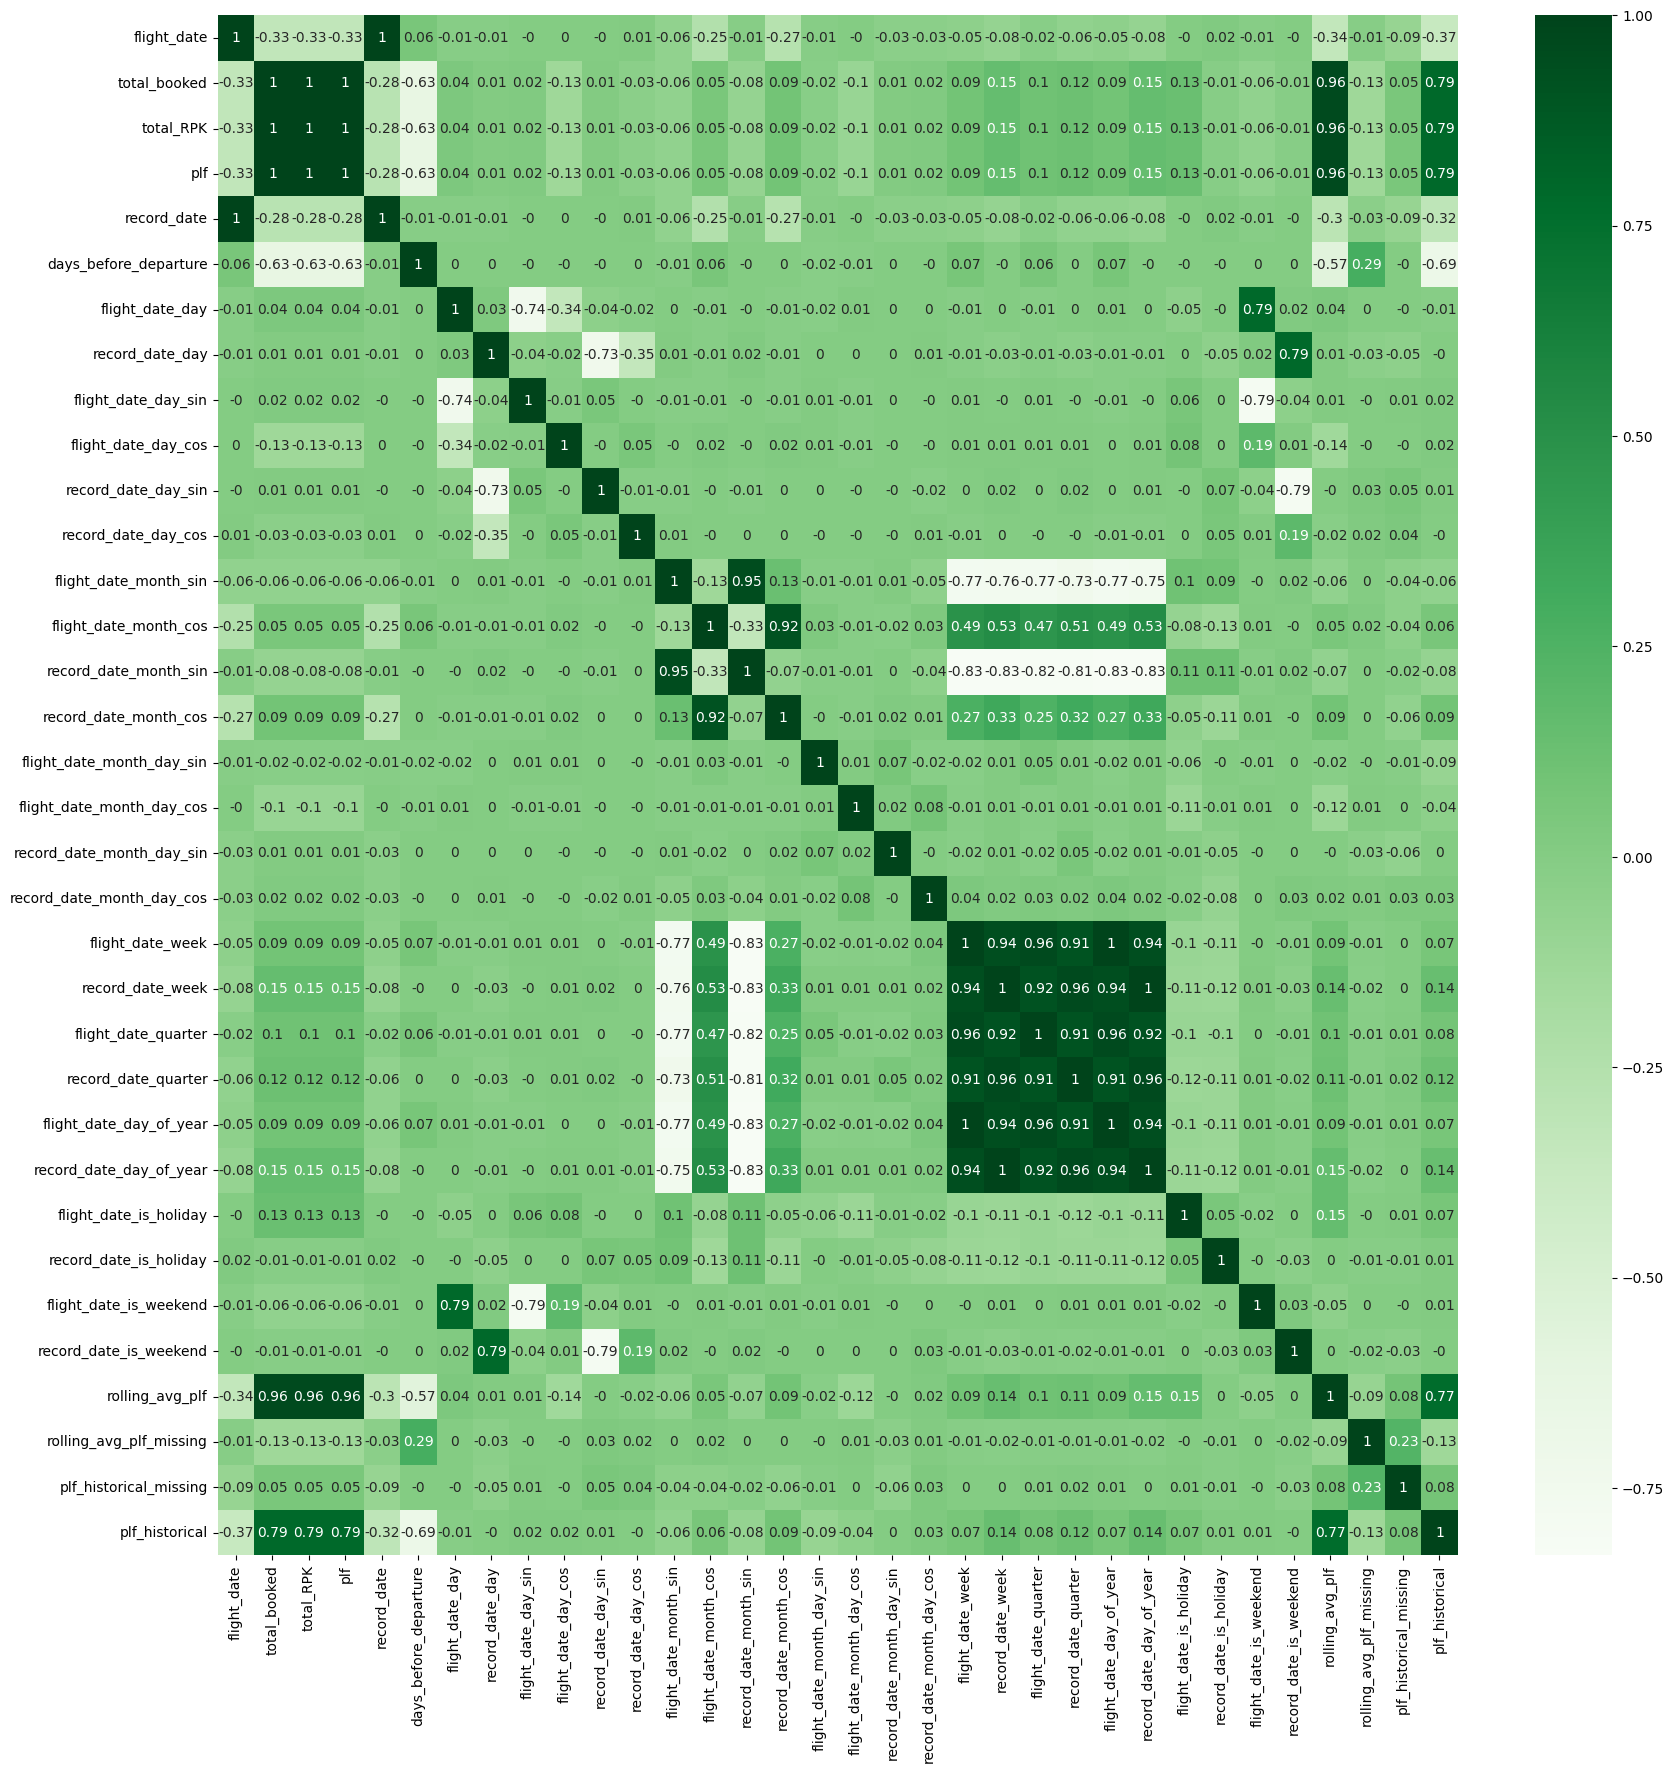

In [175]:
import seaborn as sns
plt.figure(figsize=(20,20))
sns.heatmap(correlations, cmap="Greens",annot=True)
plt.show()

C:\Users\programmer1.BG\AppData\Local\Temp\ipykernel_23024\3286616496.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(correlations.columns, rotation=90)
C:\Users\programmer1.BG\AppData\Local\Temp\ipykernel_23024\3286616496.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend() # to get identification of names along with color


<Figure size 2000x2000 with 0 Axes>

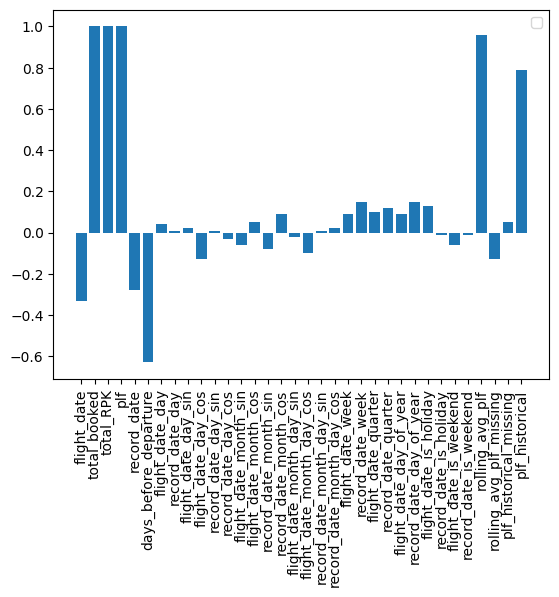

In [ ]:



fig, ax = plt.subplots()
ax.bar(correlations.columns, correlations["plf"])

# to make the x label rotated
ax.set_xticklabels(correlations.columns, rotation=90) 
ax.legend() # to get identification of names along with color

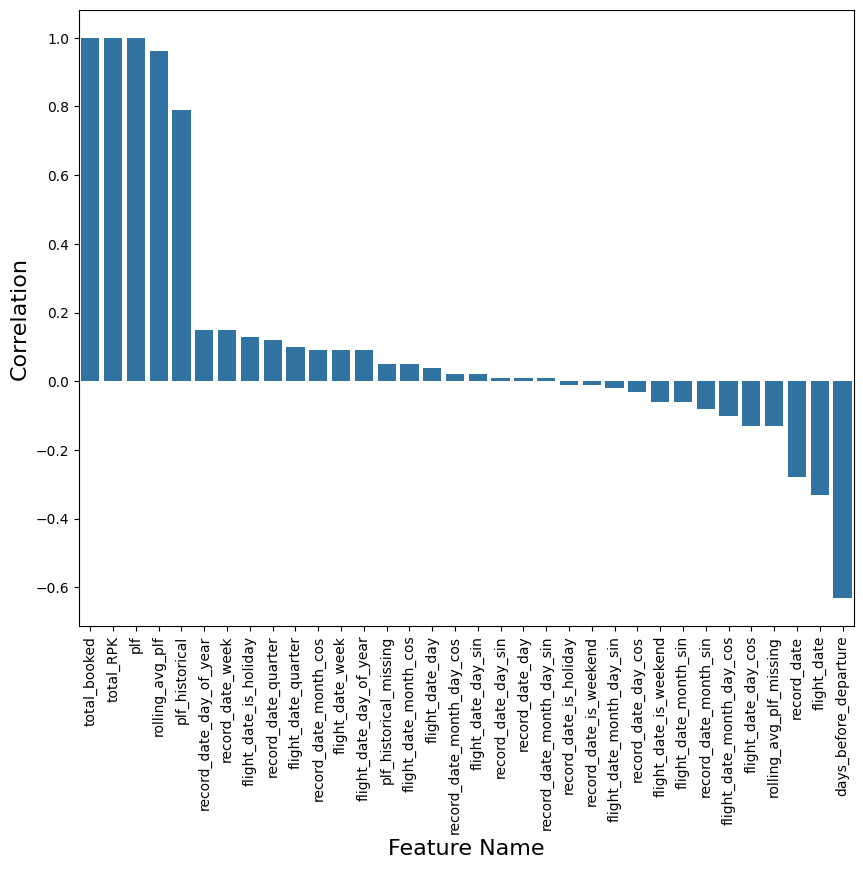

In [180]:
imp_df = pd.DataFrame({
    "Feature Name": correlations.columns,
    "Correlation": correlations["plf"]
})
fi = imp_df.sort_values(by="Correlation", ascending=False)

# fi2 = fi.head(10)
plt.figure(figsize=(10,8))
sns.barplot(data=fi, y='Correlation', x='Feature Name')
# plt.title('Feature Importance Each Attributes (Decision Tree Regressor)', fontsize=18)
plt.ylabel ('Correlation', fontsize=16)
plt.xlabel ('Feature Name', fontsize=16)
plt.xticks(rotation=90)
plt.show()

<h2>SHAP</h2>

In [107]:
Xh_sample = X_horizontal_test[:200]  # shape: (50, H_time, features)
Xv_sample = X_vertical_test[:200]    # shape: (50, V_time, features)
Xh_sample.shape, Xv_sample.shape

((200, 9, 8), (200, 9, 9))

In [108]:
# model = develop_dual_LSTM_with_attention(X_horizontal_train, X_vertical_train)
model = develop_dual_LSTM_model(X_horizontal_train, X_vertical_train)
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 9, 8)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_24      │ (None, 9, 9)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_46 (LSTM)      │ (None, 9, 64)     │     18,688 │ input_layer_23[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_48 (LSTM)      │ (None, 9, 64)     │     18,944 │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_46          │ (None, 9, 64)     │          0 │ lstm_46[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_48          │ (None, 9, 64)     │          0 │ lstm_48[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_47 (LSTM)      │ (None, 32)        │     12,416 │ dropout_46[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_49 (LSTM)      │ (None, 32)        │     12,416 │ dropout_48[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_47          │ (None, 32)        │          0 │ lstm_47[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_49          │ (None, 32)        │          0 │ lstm_49[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 64)        │          0 │ dropout_47[0][0], │
│ (Concatenate)       │                   │            │ dropout_49[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 16)        │      1,040 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 1)         │         17 │ dense_44[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 63,521 (248.13 KB)

 Trainable params: 63,521 (248.13 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
H, H_feat = Xh_sample.shape[1], Xh_sample.shape[2]
V, V_feat = Xv_sample.shape[1], Xv_sample.shape[2]

# Flatten the input to 2D for KernelExplainer
Xh_flat = Xh_sample.reshape((Xh_sample.shape[0], -1))  # shape: (samples, H * H_feat)
Xv_flat = Xv_sample.reshape((Xv_sample.shape[0], -1))  # shape: (samples, V * V_feat)
X_combined = np.concatenate([Xh_flat, Xv_flat], axis=1)  # shape: (samples, total_features)
Xh_flat.shape, Xv_flat.shape, X_combined.shape

((200, 72), (200, 81), (200, 153))

In [110]:
horizontal_feature_names = [
    "plf", "total_RPK", "rolling_avg_plf", "days_before_departure",
    "record_date_day", "flight_date_day", "record_date_day_of_year",
    "flight_date_is_holiday"
]

vertical_feature_names = [
    "plf", "total_RPK", "plf_historical", "rolling_avg_plf", "flight_date_day",
    "flight_date_day_of_year", "flight_date_week", "flight_date_is_holiday", "flight_date_is_weekend"
]

# Generate names for flattened features
h_feat_names = [f"{feat}_H{t}" for t in range(H) for feat in horizontal_feature_names]
v_feat_names = [f"{feat}_V{t}" for t in range(V) for feat in vertical_feature_names]
all_feature_names = h_feat_names + v_feat_names
all_feature_names

['plf_H0',
 'total_RPK_H0',
 'rolling_avg_plf_H0',
 'days_before_departure_H0',
 'record_date_day_H0',
 'flight_date_day_H0',
 'record_date_day_of_year_H0',
 'flight_date_is_holiday_H0',
 'plf_H1',
 'total_RPK_H1',
 'rolling_avg_plf_H1',
 'days_before_departure_H1',
 'record_date_day_H1',
 'flight_date_day_H1',
 'record_date_day_of_year_H1',
 'flight_date_is_holiday_H1',
 'plf_H2',
 'total_RPK_H2',
 'rolling_avg_plf_H2',
 'days_before_departure_H2',
 'record_date_day_H2',
 'flight_date_day_H2',
 'record_date_day_of_year_H2',
 'flight_date_is_holiday_H2',
 'plf_H3',
 'total_RPK_H3',
 'rolling_avg_plf_H3',
 'days_before_departure_H3',
 'record_date_day_H3',
 'flight_date_day_H3',
 'record_date_day_of_year_H3',
 'flight_date_is_holiday_H3',
 'plf_H4',
 'total_RPK_H4',
 'rolling_avg_plf_H4',
 'days_before_departure_H4',
 'record_date_day_H4',
 'flight_date_day_H4',
 'record_date_day_of_year_H4',
 'flight_date_is_holiday_H4',
 'plf_H5',
 'total_RPK_H5',
 'rolling_avg_plf_H5',
 'days_before_

In [111]:
X_combined.shape

(200, 153)

In [112]:
X_explain = X_combined[:100]         # data to explain
X_background = X_combined[100:200]    # background data for SHAP
X_explain.shape, X_background.shape

((100, 153), (100, 153))

In [113]:
def model_predict(X):
    if len(X.shape) == 1:
        X = X.reshape(1, -1)  # for single sample fallback

    h_len = Xh_sample.shape[1] * Xh_sample.shape[2]
    v_len = Xv_sample.shape[1] * Xv_sample.shape[2]

    h = X[:, :h_len].reshape(-1, Xh_sample.shape[1], Xh_sample.shape[2])
    v = X[:, h_len:].reshape(-1, Xv_sample.shape[1], Xv_sample.shape[2])

    preds = model.predict([h, v])
    return preds.flatten()  # ensure shape (N,)


In [114]:
test_preds = model_predict(X_explain)
print("Prediction shape:", test_preds.shape)


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_181', 'keras_tensor_182']. Received: the structure of inputs=('*', '*')
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 503ms/step
Prediction shape: (100,)


In [115]:
explainer = shap.KernelExplainer(model_predict, X_background) # x_background gives background samples
shap_values = explainer.shap_values(X_explain) #x_explain samples to explain

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
7332/7332 ━━━━━━━━━━━━━━━━━━━━ 80s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
7332/7332 ━━━━━━━━━━━━━━━━━━━━ 72s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
7332/7332 ━━━━━━━━━━━━━━━━━━━━ 54s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
7332/7332 ━━━━━━━━━━━━━━━━━━━━ 60s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
7332/7332 ━━━━━━━━━━━━━━━━━━━━ 105s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
7332/7332 ━━━━━━━━━━━━━━━━━━━━ 110s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
7332/7332 ━━━━━━━━━━━━━━━━━━━━ 114s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
7282/7282 ━━━━━━━━━━━━━━━━━━━━ 95s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
7282/7282 ━━━━━━━━━━━━━━━━━━━━ 64s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
7282/7282 ━━━━━━━━━━━━━━━━━━━━ 68s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
7275/7275 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
7282/7282 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step
1/

In [116]:
shap_values.shape

(100, 153)

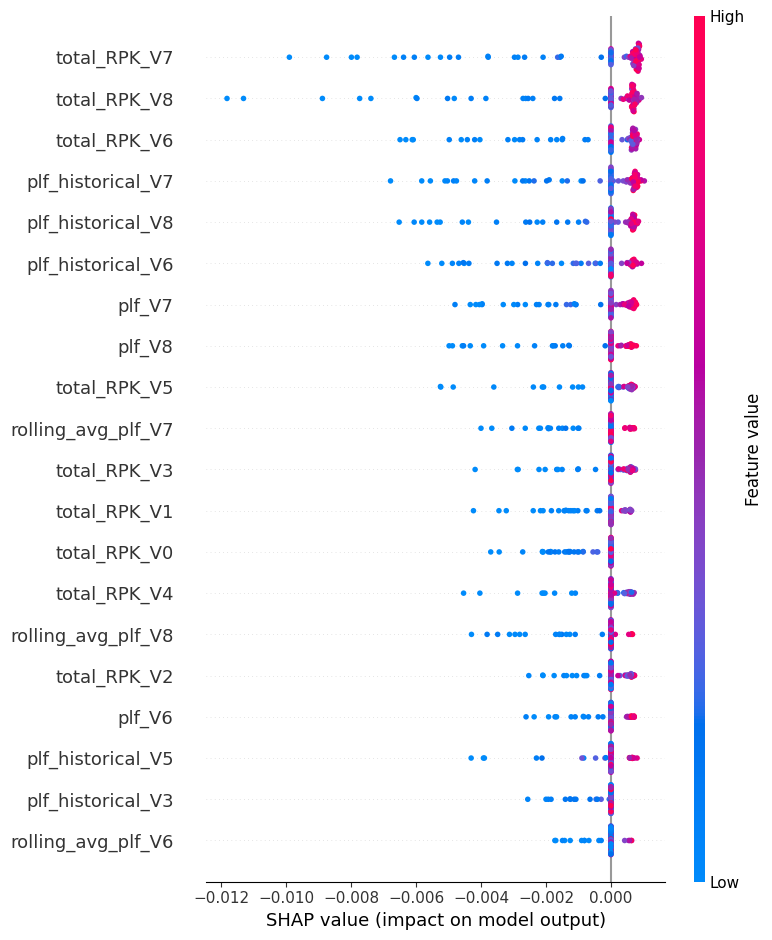

In [117]:
shap.summary_plot(shap_values, X_explain, feature_names=all_feature_names)

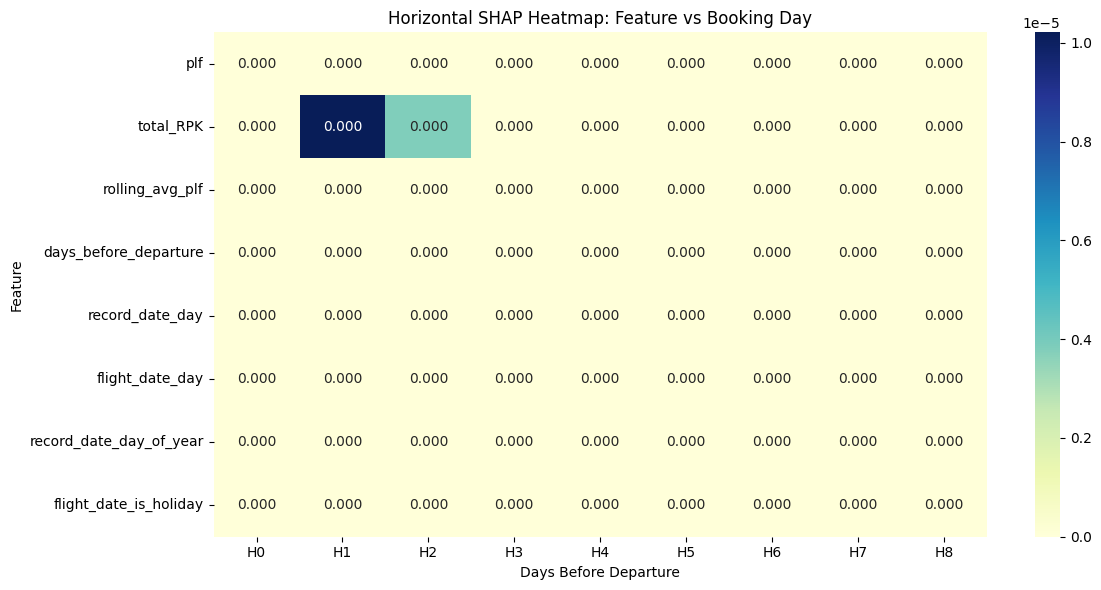

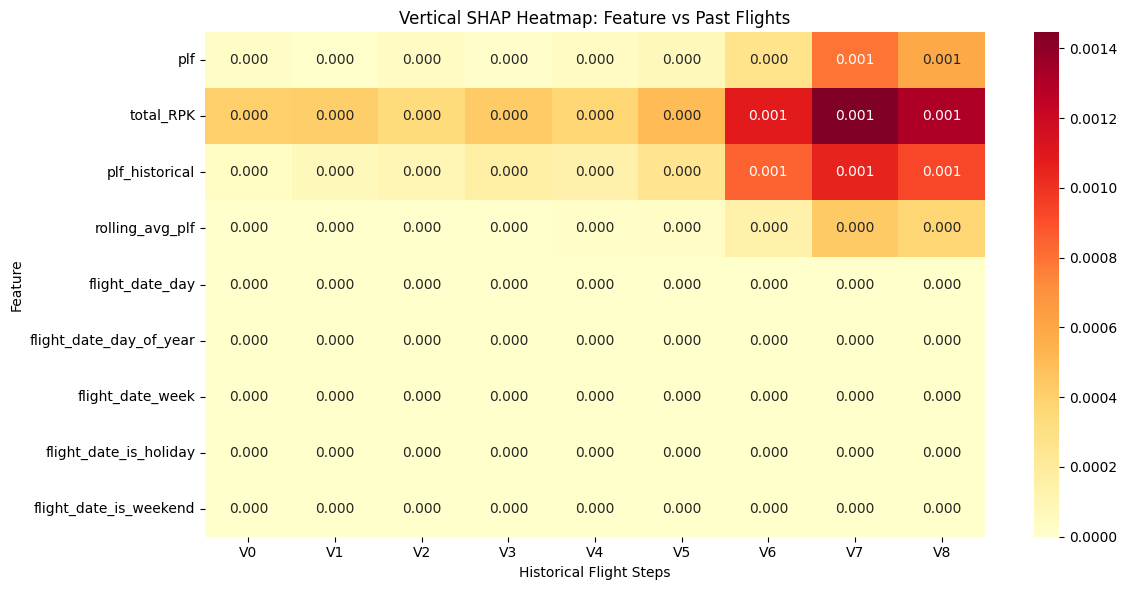

In [118]:
# 1. Generate a SHAP Heatmap: Impact Per Timestep and Feature
# Step A: Split and Reshape

N = X_explain.shape[0]
H_feat = len(horizontal_feature_names)
V_feat = len(vertical_feature_names)
H = Xh_sample.shape[1]
V = Xv_sample.shape[1]

shap_h = np.array(shap_values)[:, :H * H_feat].reshape(N, H, H_feat)
shap_v = np.array(shap_values)[:, H * H_feat:].reshape(N, V, V_feat)

# Step B: Average Over Samples → Get (Time, Feature) Matrix

mean_abs_shap_h = np.mean(np.abs(shap_h), axis=0)  # shape: (H, H_feat)
mean_abs_shap_v = np.mean(np.abs(shap_v), axis=0)  # shape: (V, V_feat)

# Step C: Plot Heatmaps

import matplotlib.pyplot as plt
import seaborn as sns

# Horizontal features
plt.figure(figsize=(12, 6))
sns.heatmap(mean_abs_shap_h.T, annot=True, fmt=".3f", cmap="YlGnBu",
            xticklabels=[f"H{t}" for t in range(H)],
            yticklabels=horizontal_feature_names)
plt.title("Horizontal SHAP Heatmap: Feature vs Booking Day")
plt.xlabel("Days Before Departure")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Vertical features
plt.figure(figsize=(12, 6))
sns.heatmap(mean_abs_shap_v.T, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=[f"V{t}" for t in range(V)],
            yticklabels=vertical_feature_names)
plt.title("Vertical SHAP Heatmap: Feature vs Past Flights")
plt.xlabel("Historical Flight Steps")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [119]:

# 2. Compare Horizontal vs. Vertical SHAP Impact (Aggregate)

# Total SHAP contribution (absolute)
total_shap_h = np.mean(np.abs(shap_h))
total_shap_v = np.mean(np.abs(shap_v))

print("Avg absolute SHAP (Horizontal):", total_shap_h)
print("Avg absolute SHAP (Vertical):", total_shap_v)


Avg absolute SHAP (Horizontal): 1.946484118786584e-07
Avg absolute SHAP (Vertical): 0.0001571653220533279


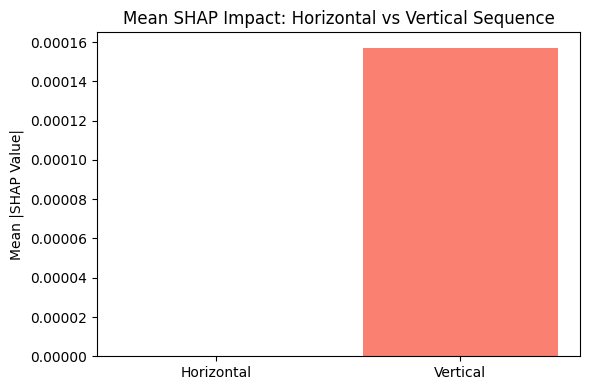

In [120]:
plt.figure(figsize=(6,4))
plt.bar(["Horizontal", "Vertical"], [total_shap_h, total_shap_v], color=["skyblue", "salmon"])
plt.title("Mean SHAP Impact: Horizontal vs Vertical Sequence")
plt.ylabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()


In [121]:
# to Confirm This is the Model’s Behavior (Not SHAP Bug)
#  1. Predict from vertical-only:

X_null_h = np.zeros_like(Xh_sample)
test_preds_vertical = model.predict([X_null_h, Xv_sample])

#  2. Predict from horizontal-only:
X_null_v = np.zeros_like(Xv_sample)
test_preds_horizontal = model.predict([Xh_sample, X_null_v])

# Then compare them to full predictions:
test_preds_full = model.predict([Xh_sample, Xv_sample])



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


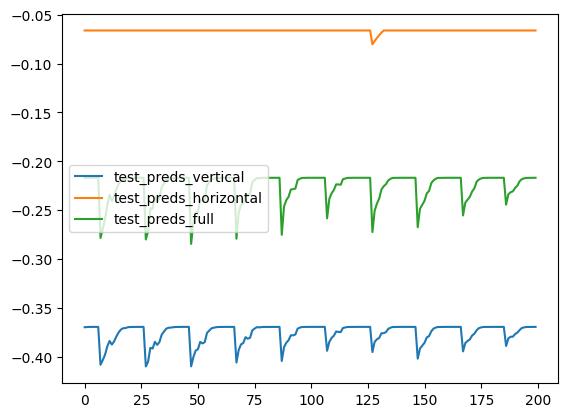

In [122]:
plt.plot(test_preds_vertical, label = 'test_preds_vertical')
plt.plot(test_preds_horizontal, label= 'test_preds_horizontal')
plt.plot(test_preds_full, label= 'test_preds_full')
# plt.ylabel('# PLF')
# plt.title('ACtual vs. Prediction')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [ ]:
# does not work
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# # Assuming X is your feature matrix (convert to DataFrame if necessary)
# if isinstance(X, np.ndarray):  # If X is a numpy array
#     X = pd.DataFrame(X, columns=feature_names)

# vif = pd.DataFrame()
# vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
# vif["Feature"] = X.columns
# print(vif)


NameError: name 'feature_names' is not defined

<h1>Selecting best window_size</h1>

<h2>code to select best window_size</h2>

In [ ]:
# latest for separate dataset, X
window_sizes = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]  # Example range of window sizes

# Store results for comparison
results_h = []
results_v = []
results_b = []

for window_size in window_sizes:
    print(f"Testing window_size = {window_size}")
    
    numerical_features_indices = [0,1,2,6,7,8, 9,10,11,12, 15,16]  # Example: plf, rolling_avg_plf, etc.
    categorical_features_indices = [3,4,5, 13,14]  # Example: weekend flags, etc.
    
    # Step 1: Prepare dataset with current window_size
    X_horizontal,X_vertical, y, dates, remaining_days, h_f_names, v_f_names = dataset_preparation_initial_airRM_B_SS(processed_input_df, window_size)
 
    X_horizontal_train, X_horizontal_val, X_horizontal_test, \
    X_vertical_train, X_vertical_val, X_vertical_test, \
    y_train, y_val, y_test, \
    date_train, date_val, date_test, \
    r_days_train, r_days_val, r_days_test, \
    X_horizontal_train_scaled, X_horizontal_val_scaled, X_horizontal_test_scaled, \
    X_vertical_train_scaled, X_vertical_val_scaled, X_vertical_test_scaled = dataset_splitting_furnished_airRM(X_horizontal, X_vertical, y, dates, remaining_days, h_f_names, v_f_names)
    
    # Step 2: Train your model (replace with your model of choice)
    
    # Prepare the inputs as lists for training and validation
    X_train_scaled = [X_horizontal_train_scaled, X_vertical_train_scaled]
    X_val_scaled = [X_horizontal_val_scaled, X_vertical_val_scaled]
    X_test_scaled = [X_horizontal_test_scaled, X_vertical_test_scaled]
    X_train = [X_horizontal_train, X_vertical_train]
    X_val = [X_horizontal_val, X_vertical_val]
    X_test = [X_horizontal_test, X_vertical_test]
    
    # Horizontal only
    LSTM_model_h = develop_horizontal_LSTM_model(X_horizontal_train)
    LSTM_history_h = train_model(LSTM_model_h, X_horizontal_train_scaled, y_train, X_horizontal_val_scaled, y_val)

    # Vertical only
    LSTM_model_v = develop_vertical_LSTM_model(X_vertical_train)
    LSTM_history_v = train_model(LSTM_model_v, X_vertical_train_scaled, y_train, X_vertical_val_scaled, y_val)
    
    LSTM_model_dual = develop_dual_LSTM_model(X_horizontal_train, X_vertical_train)
    LSTM_history_dual = train_model(LSTM_model_dual, X_train_scaled, y_train, X_val_scaled, y_val)
    
    # Step 3: Predict and evaluate on validation set
    y_pred_h = LSTM_model_h.predict(X_horizontal_test_scaled)
    y_pred_v = LSTM_model_v.predict(X_vertical_test_scaled)
    y_pred_b = LSTM_model_dual.predict(X_test_scaled)
    
    mae_h = mae(y_test, y_pred_h)
    mape_h = mape(y_test, y_pred_h)
    mse_h = mse(y_test, y_pred_h)
    rmse_h = rmse(y_test, y_pred_h)
    mase_h = mase(y_test, y_pred_h, y_train)
    r2_h = r2(y_test, y_pred_h)
    
    mae_v = mae(y_test, y_pred_v)
    mape_v = mape(y_test, y_pred_v)
    mse_v = mse(y_test, y_pred_v)
    rmse_v = rmse(y_test, y_pred_v)
    mase_v = mase(y_test, y_pred_v, y_train)
    r2_v = r2(y_test, y_pred_v)
    
    mae_b = mae(y_test, y_pred_b)
    mape_b = mape(y_test, y_pred_b)
    mse_b = mse(y_test, y_pred_b)
    rmse_b = rmse(y_test, y_pred_b)
    mase_b = mase(y_test, y_pred_b, y_train)
    r2_b = r2(y_test, y_pred_b)
    
    # Log results
    results_h.append({"window_size": window_size, "MAE": mae_h, "MAPE": mape_h, "MSE": mse_h, "RMSE": rmse_h, "MASE": mase_h, "R2": r2_h})
    print(f"Window Size {window_size} -> MAE: {mae_h},  MAPE: {mape_h}, MSE: {mse_h}, RMSE: {rmse_h}, MASE: {mase_h}, R2: {r2_h}")
    results_v.append({"window_size": window_size, "MAE": mae_v, "MAPE": mape_v, "MSE": mse_v, "RMSE": rmse_v, "MASE": mase_v, "R2": r2_v})
    print(f"Window Size {window_size} -> MAE: {mae_v},  MAPE: {mape_v}, MSE: {mse_v}, RMSE: {rmse_v}, MASE: {mase_v}, R2: {r2_v}")
    results_b.append({"window_size": window_size, "MAE": mae_b, "MAPE": mape_b, "MSE": mse_b, "RMSE": rmse_b, "MASE": mase_b, "R2": r2_b})
    print(f"Window Size {window_size} -> MAE: {mae_b},  MAPE: {mape_b}, MSE: {mse_b}, RMSE: {rmse_b}, MASE: {mase_b}, R2: {r2_b}")


Testing window_size = 3
(30456, 8)
(30456, 9)

🔍 [Horizontal] Numerical Features (5): ['plf', 'total_RPK', 'rolling_avg_plf', 'days_before_departure', 'record_date_day_of_year']
🔍 [Horizontal] Categorical Features (3): ['record_date_day', 'flight_date_day', 'flight_date_is_holiday']

🔍 [Vertical] Numerical Features (6): ['plf', 'total_RPK', 'plf_historical', 'rolling_avg_plf', 'flight_date_day_of_year', 'flight_date_week']
🔍 [Vertical] Categorical Features (3): ['flight_date_day', 'flight_date_is_holiday', 'flight_date_is_weekend']

🔍 Splitting Debug:
Total samples: 10152
Train end at:  7106 → 70.00%
Val end at:    8629 → 85.00%
Test end at:   10152 → 15.00%

📊 Total Horizontal samples before split: 10152
Expected: Train 7106, Val 1522, Test 1523
Total Horizontal samples after split: Train=7106, Val=1523, Test=1523
Total Horizontal samples after scalled: Train=7106, Val=1523, Test=1523

📊 Total Vertical samples before split: 10152
Expected: Train 7106, Val 1522, Test 1523
Actual: Train

c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_230', 'keras_tensor_231']. Received: the structure of inputs=('*', '*')
  warnings.warn(


223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 2977.8948 - mae: 45.9361 - val_loss: 164.9644 - val_mae: 9.7903
Epoch 2/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 313.5831 - mae: 13.4510 - val_loss: 48.1381 - val_mae: 5.4416
Epoch 3/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 70.5566 - mae: 6.4192 - val_loss: 25.4209 - val_mae: 3.7645
Epoch 4/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 51.5956 - mae: 5.3357 - val_loss: 22.5148 - val_mae: 3.5052
Epoch 5/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 49.7362 - mae: 5.2269 - val_loss: 19.6819 - val_mae: 3.1448
Epoch 6/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 44.9633 - mae: 4.9344 - val_loss: 25.7777 - val_mae: 3.9197
Epoch 7/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 42.0132 - mae: 4.7704 - val_loss: 20.6336 - val_mae: 3.3706
Epoch 8/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 38.6849 - mae: 4.6494 - val_loss: 21.9289 - val_mae: 3.4508
Epoch 9/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 7

c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_257', 'keras_tensor_258']. Received: the structure of inputs=('*', '*')
  warnings.warn(


212/212 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 3264.4456 - mae: 48.9371 - val_loss: 463.9689 - val_mae: 16.7493
Epoch 2/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 817.6301 - mae: 22.0572 - val_loss: 58.7999 - val_mae: 5.6612
Epoch 3/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 125.0932 - mae: 8.3951 - val_loss: 26.7990 - val_mae: 3.7629
Epoch 4/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 55.9362 - mae: 5.6130 - val_loss: 25.4022 - val_mae: 3.8792
Epoch 5/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 45.7347 - mae: 5.0866 - val_loss: 21.7367 - val_mae: 3.4812
Epoch 6/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 44.2685 - mae: 4.9539 - val_loss: 17.7439 - val_mae: 2.8823
Epoch 7/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 40.4694 - mae: 4.6795 - val_loss: 24.1823 - val_mae: 3.8369
Epoch 8/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 40.5646 - mae: 4.7128 - val_loss: 19.3412 - val_mae: 3.1113
Epoch 9/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 2

...

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 3768.0139 - mae: 54.4784 - val_loss: 448.3617 - val_mae: 16.2304
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1030.3356 - mae: 27.4119 - val_loss: 624.4401 - val_mae: 21.3977
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 689.1495 - mae: 22.3178 - val_loss: 163.9169 - val_mae: 10.8463
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 131.4341 - mae: 9.1770 - val_loss: 66.8537 - val_mae: 6.3510
Epoch 5/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 72.1980 - mae: 6.6016 - val_loss: 56.7990 - val_mae: 5.9825
Epoch 6/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 58.4264 - mae: 5.9458 - val_loss: 35.7071 - val_mae: 4.6288
Epoch 7/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 53.2718 - mae: 5.6639 - val_loss: 29.1116 - val_mae: 4.1633
Epoch 8/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 49.8133 - mae: 5.3826 - val_loss: 33.5655 - val_mae: 4.6605
Epoch 9/30
126/126 ━━━━━━━━━

c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_527', 'keras_tensor_528']. Received: the structure of inputs=('*', '*')
  warnings.warn(


117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 4018.0139 - mae: 57.0115 - val_loss: 559.3802 - val_mae: 17.7565
Epoch 2/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1263.8073 - mae: 30.5552 - val_loss: 557.4979 - val_mae: 20.1460
Epoch 3/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 745.6296 - mae: 23.7279 - val_loss: 163.1363 - val_mae: 10.3275
Epoch 4/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 209.8580 - mae: 11.7573 - val_loss: 72.7206 - val_mae: 6.6116
Epoch 5/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 95.1306 - mae: 7.7984 - val_loss: 58.1207 - val_mae: 6.2325
Epoch 6/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 65.3205 - mae: 6.1857 - val_loss: 43.8527 - val_mae: 5.3352
Epoch 7/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 53.1532 - mae: 5.6345 - val_loss: 43.8369 - val_mae: 5.0547
Epoch 8/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 54.9105 - mae: 5.6702 - val_loss: 31.7624 - val_mae: 4.4887
Epoch 9/30
117/117 ━━━━━━━━

c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_554', 'keras_tensor_555']. Received: the structure of inputs=('*', '*')
  warnings.warn(


107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 4363.2031 - mae: 60.1221 - val_loss: 964.5137 - val_mae: 25.2726
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1902.8245 - mae: 37.0823 - val_loss: 389.9838 - val_mae: 16.4136
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 845.8698 - mae: 25.4008 - val_loss: 613.7020 - val_mae: 21.2055
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 719.2109 - mae: 23.1503 - val_loss: 143.1204 - val_mae: 9.0545
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 276.9379 - mae: 13.2763 - val_loss: 73.8611 - val_mae: 6.9266
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 91.7079 - mae: 7.6157 - val_loss: 49.2517 - val_mae: 5.5239
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 63.5825 - mae: 6.2177 - val_loss: 40.6659 - val_mae: 4.9856
Epoch 8/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 57.6498 - mae: 5.8439 - val_loss: 38.9555 - val_mae: 4.9588
Epoch 9/30
107/107 ━━━━━

<h2>plotting results</h2>

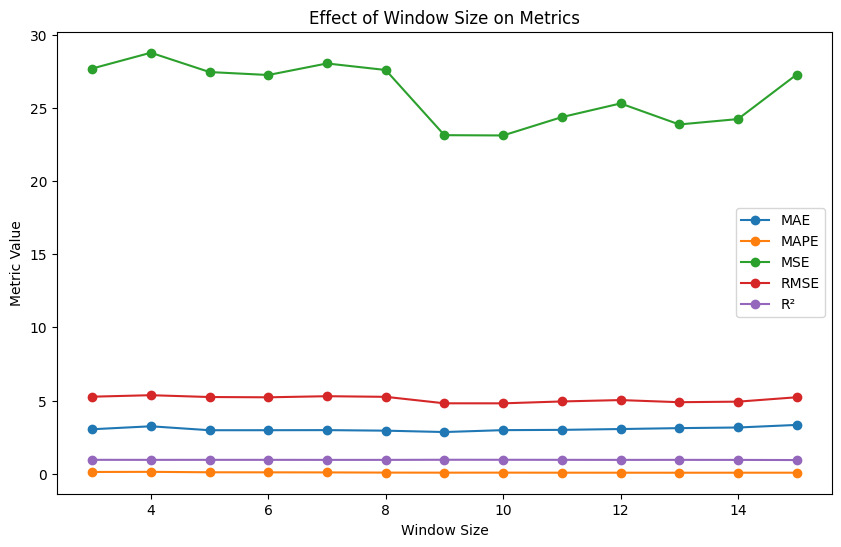

In [148]:

results_df = pd.DataFrame(results_h)

# Plot metrics
plt.figure(figsize=(10, 6))
plt.plot(results_df["window_size"], results_df["MAE"], label="MAE", marker='o')
plt.plot(results_df["window_size"], results_df["MAPE"], label="MAPE", marker='o')
plt.plot(results_df["window_size"], results_df["MSE"], label="MSE", marker='o')
plt.plot(results_df["window_size"], results_df["RMSE"], label="RMSE", marker='o')
plt.plot(results_df["window_size"], results_df["R2"], label="R²", marker='o')
plt.xlabel("Window Size")
plt.ylabel("Metric Value")
plt.title("Effect of Window Size on Metrics")
plt.legend()
plt.show()


<h2>getting best window_size</h2>

In [145]:
print("HORIZONTAL\n-----------------------------")
results_df = pd.DataFrame(results_h)
best_window = results_df.loc[results_df["MAE"].idxmin()]
print(f"Best Window Size  (MAE): {best_window['window_size']}")
best_window = results_df.loc[results_df["MAPE"].idxmin()]
print(f"Best Window Size (MAPE): {best_window['window_size']}")
best_window = results_df.loc[results_df["MSE"].idxmin()]
print(f"Best Window Size  (MSE): {best_window['window_size']}")
best_window = results_df.loc[results_df["RMSE"].idxmin()]
print(f"Best Window Size (RMSE): {best_window['window_size']}")
best_window = results_df.loc[results_df["MASE"].idxmin()]
print(f"Best Window Size (MASE): {best_window['window_size']}")
best_window = results_df.loc[results_df["R2"].idxmax()]
print(f"Best Window Size   (R2): {best_window['window_size']}")

print("VERTICAL\n-----------------------------")
results_df = pd.DataFrame(results_v)
best_window = results_df.loc[results_df["MAE"].idxmin()]
print(f"Best Window Size  (MAE): {best_window['window_size']}")
best_window = results_df.loc[results_df["MAPE"].idxmin()]
print(f"Best Window Size (MAPE): {best_window['window_size']}")
best_window = results_df.loc[results_df["MSE"].idxmin()]
print(f"Best Window Size  (MSE): {best_window['window_size']}")
best_window = results_df.loc[results_df["RMSE"].idxmin()]
print(f"Best Window Size (RMSE): {best_window['window_size']}")
best_window = results_df.loc[results_df["MASE"].idxmin()]
print(f"Best Window Size (MASE): {best_window['window_size']}")
best_window = results_df.loc[results_df["R2"].idxmax()]
print(f"Best Window Size   (R2): {best_window['window_size']}")

print("BOTH H & V\n-----------------------------")
results_df = pd.DataFrame(results_b)
best_window = results_df.loc[results_df["MAE"].idxmin()]
print(f"Best Window Size  (MAE): {best_window['window_size']}")
best_window = results_df.loc[results_df["MAPE"].idxmin()]
print(f"Best Window Size (MAPE): {best_window['window_size']}")
best_window = results_df.loc[results_df["MSE"].idxmin()]
print(f"Best Window Size  (MSE): {best_window['window_size']}")
best_window = results_df.loc[results_df["RMSE"].idxmin()]
print(f"Best Window Size (RMSE): {best_window['window_size']}")
best_window = results_df.loc[results_df["MASE"].idxmin()]
print(f"Best Window Size (MASE): {best_window['window_size']}")
best_window = results_df.loc[results_df["R2"].idxmax()]
print(f"Best Window Size   (R2): {best_window['window_size']}")


HORIZONTAL
-----------------------------
Best Window Size  (MAE): 9.0
Best Window Size (MAPE): 13.0
Best Window Size  (MSE): 10.0
Best Window Size (RMSE): 10.0
Best Window Size (MASE): 15.0
Best Window Size   (R2): 9.0
VERTICAL
-----------------------------
Best Window Size  (MAE): 5.0
Best Window Size (MAPE): 15.0
Best Window Size  (MSE): 15.0
Best Window Size (RMSE): 15.0
Best Window Size (MASE): 15.0
Best Window Size   (R2): 4.0
BOTH H & V
-----------------------------
Best Window Size  (MAE): 5.0
Best Window Size (MAPE): 13.0
Best Window Size  (MSE): 10.0
Best Window Size (RMSE): 10.0
Best Window Size (MASE): 15.0
Best Window Size   (R2): 10.0


<h2>plotting metrics</h2>

C:\Users\programmer1.BG\AppData\Local\Temp\ipykernel_26900\1181737509.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)
C:\Users\programmer1.BG\AppData\Local\Temp\ipykernel_26900\1181737509.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)
C:\Users\programmer1.BG\AppData\Local\Temp\ipykernel_26900\1181737509.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)
C:\Users\programmer1.BG\AppData\Local\Temp\ipykernel_26900\1181737509.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

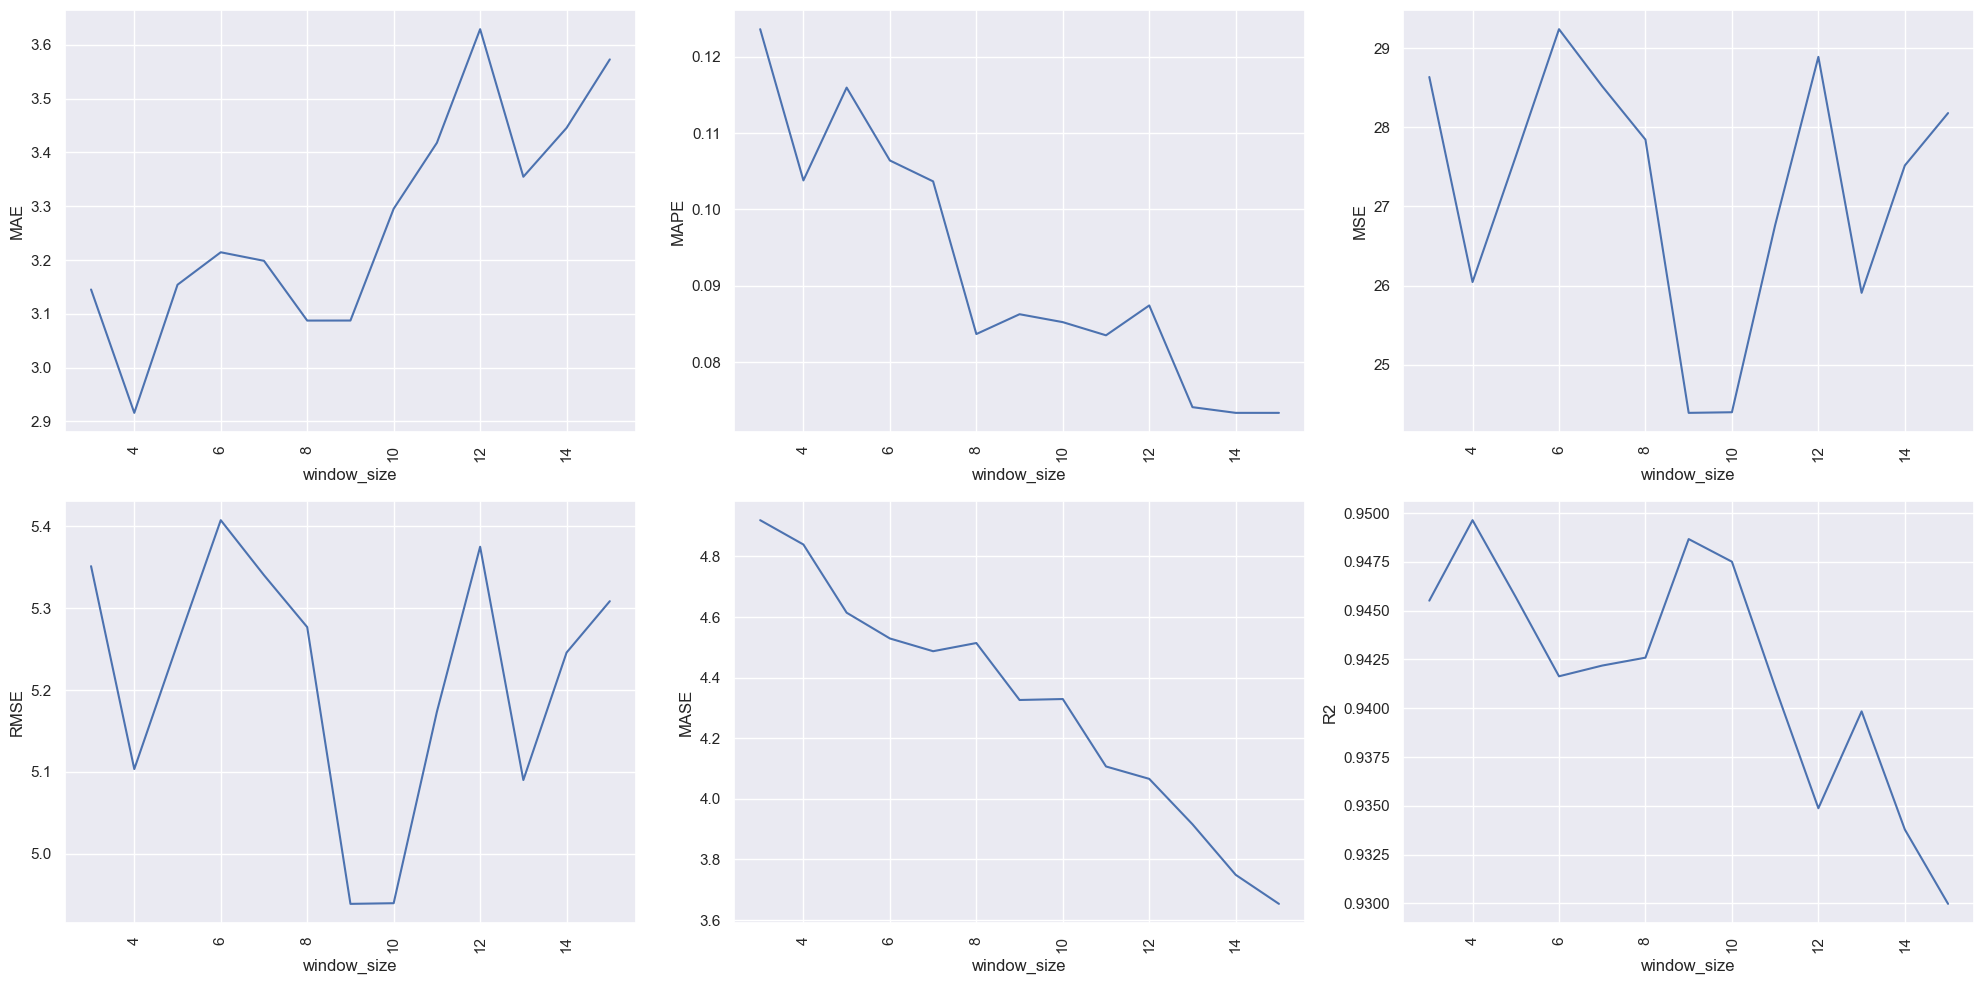

In [1162]:
# # Plot metrics

import seaborn as sns

sns.set_theme(color_codes=True)
# list of categorical variables to plot

cat_vars = ['MAE','MAPE', 'MSE', 'RMSE', 'MASE', 'R2']

# create figure with subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
axs = axs.flatten()

# create lineplot for each categorical variable
for i, var in enumerate(cat_vars):
    sns.lineplot(x='window_size', y=var, data=results_df, ax=axs[i], estimator=np.mean)
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=90)

# adjust spacing between subplots
fig.tight_layout()

# show plot
plt.show()

In [ ]:
# to check the entries of date vs remaining_days in X
# for i in range(0,len(X)):
#     print(f'Date: {dates[i]} - {remaining_days[i]}')

In [ ]:
# to check the entries of date vs remaining_days in splitted dataset
# for i in date_train.index:
#     print(f'Date: {date_train[i]} - {r_days_train[i]}')

In [62]:
# X, y, dates, remaining_days = df_to_X_y_with_vertical_and_horizontal_sequences(df = processed_input_df, window_size = 5, predict_days_before = 0)

<h1>Forming X(features) dataset</h1>

<h2>checking first values</h2>

In [56]:
X[0],y[0], dates[0], remaining_days[0]

(array([[1.00000e+02, 2.54068e+05, 9.63000e+01, 4.00000e+00, 1.00000e+00,
         5.00000e+00, 2.06000e+02, 1.00000e+00, 1.00000e+02, 9.69100e+01,
         9.63000e+01, 2.00000e+00],
        [1.00000e+02, 2.54068e+05, 1.00000e+02, 3.00000e+00, 2.00000e+00,
         5.00000e+00, 2.07000e+02, 1.00000e+00, 9.93800e+01, 1.00000e+02,
         9.93800e+01, 3.00000e+00],
        [1.00000e+02, 2.54068e+05, 1.00000e+02, 2.00000e+00, 3.00000e+00,
         5.00000e+00, 2.08000e+02, 1.00000e+00, 9.93800e+01, 9.96900e+01,
         9.93800e+01, 4.00000e+00]]),
 np.float64(100.0),
 Timestamp('2023-07-29 00:00:00'),
 np.int64(1))

<h2>Reshaping X</h2>

In [57]:
# reshaping and dataframing the X dataset 
reshaped_x = X.reshape(X.shape[0],-1)
x_df = pd.DataFrame(data=reshaped_x)
x_df.shape

(10152, 36)

In [58]:
x_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
0,100.00,254068.0,96.30,4.0,1.0,5.0,206.0,1.0,100.00,96.910000,96.30,2.0,100.00,254068.0,100.000000,3.0,2.0,5.0,207.0,1.0,99.38,100.000000,99.380000,3.0,100.00,254068.0,100.000000,2.0,3.0,5.0,208.0,1.0,99.38,99.690000,99.380000,4.0
1,100.00,254068.0,96.30,5.0,1.0,6.0,206.0,0.0,99.38,96.910000,96.30,3.0,98.77,250932.0,100.000000,4.0,2.0,6.0,207.0,0.0,99.38,99.380000,99.380000,4.0,100.62,255637.0,99.385000,3.0,3.0,6.0,208.0,0.0,100.00,99.380000,100.000000,5.0
2,98.77,250932.0,100.00,4.0,2.0,6.0,207.0,0.0,99.38,100.000000,99.38,3.0,100.62,255637.0,99.385000,3.0,3.0,6.0,208.0,0.0,99.38,99.690000,99.380000,4.0,100.62,255637.0,99.796667,2.0,4.0,6.0,209.0,0.0,100.00,99.586667,100.000000,5.0
3,100.62,255637.0,96.30,6.0,1.0,0.0,206.0,0.0,99.38,96.910000,96.30,4.0,100.00,254068.0,100.620000,5.0,2.0,0.0,207.0,0.0,100.00,99.380000,100.000000,5.0,100.00,254068.0,100.310000,4.0,3.0,0.0,208.0,0.0,100.62,99.690000,99.385000,6.0
4,100.00,254068.0,100.62,5.0,2.0,0.0,207.0,0.0,99.38,99.380000,99.38,4.0,100.00,254068.0,100.310000,4.0,3.0,0.0,208.0,0.0,100.00,99.380000,100.000000,5.0,98.77,250932.0,100.206667,3.0,4.0,0.0,209.0,0.0,100.62,99.586667,99.796667,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10147,13.58,34503.1,14.20,29.0,1.0,2.0,303.0,0.0,16.67,30.061671,16.67,6.0,13.58,34503.1,13.890000,28.0,2.0,2.0,304.0,0.0,8.64,30.026797,6.170000,0.0,15.43,39208.1,13.786667,27.0,3.0,2.0,305.0,0.0,14.20,29.971247,12.035000,1.0
10148,13.58,34503.1,13.89,28.0,2.0,2.0,304.0,0.0,17.28,30.674661,16.67,6.0,15.43,39208.1,13.786667,27.0,3.0,2.0,305.0,0.0,7.41,30.639870,6.664000,0.0,17.28,43913.1,14.197500,26.0,4.0,2.0,306.0,0.0,16.67,30.579689,12.468000,1.0
10149,8.64,21956.5,14.20,30.0,1.0,3.0,303.0,0.0,6.17,29.296901,6.17,0.0,10.49,26661.5,8.640000,29.0,2.0,3.0,304.0,0.0,13.58,29.236831,11.520000,1.0,11.73,29798.2,9.565000,28.0,3.0,3.0,305.0,0.0,15.43,29.196269,13.786667,2.0
10150,10.49,26661.5,8.64,29.0,2.0,3.0,304.0,0.0,8.64,30.026797,6.17,0.0,11.73,29798.2,9.565000,28.0,3.0,3.0,305.0,0.0,14.20,29.971247,12.035000,1.0,11.73,29798.2,10.286667,27.0,4.0,3.0,306.0,0.0,17.28,29.930389,14.197500,2.0


<h2>Renaming columns of X</h2>

In [1058]:
# naming the columns of the remodeled X dataframe i.e. farthest is equivalent to the window size
window_size = 9
feature_size = 11
horizontal_feature = 7
vertical_feature = 4
feature_names_H = [ 
    "H_plf",
    "H_flight_date_is_weekend", 
    "H_record_date_is_weekend",
    "H_flight_date_is_holiday",
    "H_rolling_avg_bookings",    # Add rolling average for horizontal sequences
    "H_days_before_departure",    # Add days before departure
    "H_hours_before_departure"    # Add days before departure
]


feature_names_V = [ 
    "V_plf",
    "V_flight_date_is_weekend",
    "V_flight_date_is_holiday",
    "V_days_before_departure"          # Add historical PLF for vertical sequences
]

all_feature_names = feature_names_H + feature_names_V

for i in range (0, len(x_df.columns), feature_size):
    window_v = str(window_size - np.floor(i/feature_size).astype(int))
    for j in range(0, feature_size):
        x_df.rename(columns={x_df.columns[i+j]:all_feature_names[0+j]+'_'+window_v}, inplace=True)
         
    # x_df.rename(columns={x_df.columns[i]:all_feature_names[0]+'_'+window_v}, inplace=True)
    # x_df.rename(columns={x_df.columns[i+1]:all_feature_names[1]+'_'+window_v}, inplace=True)
    # x_df.rename(columns={x_df.columns[i+2]:all_feature_names[2]+'_'+window_v}, inplace=True)
    # x_df.rename(columns={x_df.columns[i+3]:all_feature_names[3]+'_'+window_v}, inplace=True)
    # x_df.rename(columns={x_df.columns[i+4]:all_feature_names[4]+'_'+window_v}, inplace=True)
    
x_df.columns


Index(['H_plf_9', 'H_flight_date_is_weekend_9', 'H_record_date_is_weekend_9', 'H_flight_date_is_holiday_9', 'H_rolling_avg_bookings_9', 'H_days_before_departure_9', 'H_hours_before_departure_9', 'V_plf_9', 'V_flight_date_is_weekend_9', 'V_flight_date_is_holiday_9', 'V_days_before_departure_9', 'H_plf_8', 'H_flight_date_is_weekend_8', 'H_record_date_is_weekend_8', 'H_flight_date_is_holiday_8', 'H_rolling_avg_bookings_8', 'H_days_before_departure_8', 'H_hours_before_departure_8', 'V_plf_8', 'V_flight_date_is_weekend_8', 'V_flight_date_is_holiday_8', 'V_days_before_departure_8', 'H_plf_7', 'H_flight_date_is_weekend_7', 'H_record_date_is_weekend_7', 'H_flight_date_is_holiday_7', 'H_rolling_avg_bookings_7', 'H_days_before_departure_7', 'H_hours_before_departure_7', 'V_plf_7', 'V_flight_date_is_weekend_7', 'V_flight_date_is_holiday_7', 'V_days_before_departure_7', 'H_plf_6', 'H_flight_date_is_weekend_6', 'H_record_date_is_weekend_6', 'H_flight_date_is_holiday_6', 'H_rolling_avg_bookings_6',


<h2>calculating variance inflation factor (VIF)</h2>

In [ ]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# # Assuming X is your feature matrix (convert to DataFrame if necessary)
# if isinstance(X, np.ndarray):  # If X is a numpy array
#     X = pd.DataFrame(X, columns=feature_names)

# vif = pd.DataFrame()
# vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
# vif["Feature"] = X.columns
# print(vif)

pd.set_option('display.max_rows', 100)

# variance inflation factor 

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(x_df.values, i) for i in range(x_df.shape[1])]
vif["Feature"] = x_df.columns
vif


c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Feature
0,inf,H_plf_9
1,inf,H_flight_date_is_weekend_9
2,4.086139e+00,H_record_date_is_weekend_9
3,inf,H_flight_date_is_holiday_9
4,8.700708e+01,H_rolling_avg_bookings_9
5,inf,H_days_before_departure_9
6,inf,H_hours_before_departure_9
7,1.761748e+01,V_plf_9
8,3.569052e+00,V_flight_date_is_weekend_9
9,1.163587e+00,V_flight_date_is_holiday_9


<h2>Formulating feature dataset form X</h2>

In [35]:
# preparing another dataframe with other info and concatinating both   
other_df = pd.DataFrame(data={'Date':dates,'Remaining_day':remaining_days, 'Actual':y})
x_df = x_df.reindex(sorted(x_df.columns), axis=1)
df = pd.concat([other_df,x_df], axis=1)
df

,Date,Remaining_day,Actual,H_days_before_departure_1,H_days_before_departure_2,H_days_before_departure_3,H_days_before_departure_4,H_days_before_departure_5,H_days_before_departure_6,H_days_before_departure_7,H_days_before_departure_8,H_days_before_departure_9,H_flight_date_is_weekend_1,H_flight_date_is_weekend_2,H_flight_date_is_weekend_3,H_flight_date_is_weekend_4,H_flight_date_is_weekend_5,H_flight_date_is_weekend_6,H_flight_date_is_weekend_7,H_flight_date_is_weekend_8,H_flight_date_is_weekend_9,H_plf_1,H_plf_2,H_plf_3,H_plf_4,H_plf_5,H_plf_6,H_plf_7,H_plf_8,H_plf_9,H_record_date_is_weekend_1,H_record_date_is_weekend_2,H_record_date_is_weekend_3,H_record_date_is_weekend_4,H_record_date_is_weekend_5,H_record_date_is_weekend_6,H_record_date_is_weekend_7,H_record_date_is_weekend_8,H_record_date_is_weekend_9,H_rolling_avg_bookings_1,H_rolling_avg_bookings_2,H_rolling_avg_bookings_3,H_rolling_avg_bookings_4,H_rolling_avg_bookings_5,H_rolling_avg_bookings_6,H_rolling_avg_bookings_7,H_rolling_avg_bookings_8,H_rolling_avg_bookings_9,V_flight_date_is_weekend_1,V_flight_date_is_weekend_2,V_flight_date_is_weekend_3,V_flight_date_is_weekend_4,V_flight_date_is_weekend_5,V_flight_date_is_weekend_6,V_flight_date_is_weekend_7,V_flight_date_is_weekend_8,V_flight_date_is_weekend_9,V_plf_1,V_plf_2,V_plf_3,V_plf_4,V_plf_5,V_plf_6,V_plf_7,V_plf_8,V_plf_9,V_plf_historical_1,V_plf_historical_2,V_plf_historical_3,V_plf_historical_4,V_plf_historical_5,V_plf_historical_6,V_plf_historical_7,V_plf_historical_8,V_plf_historical_9
0,2023-08-04,1,98.77,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,98.77,100.00,100.00,100.00,100.00,98.15,96.91,100.00,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,99.754,99.630,99.012,99.012,98.7650,98.353333,98.455000,100.000,NaN,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,100.62,100.00,100.00,97.53,99.38,100.00,99.38,99.38,100.00,99.458750,99.381429,99.278333,99.628000,99.690000,99.586667,99.690000,100.000000,NaN
1,2023-08-05,2,100.00,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,100.00,99.38,100.00,100.00,100.00,99.38,100.00,99.38,98.15,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,99.752,99.876,99.752,99.382,99.2275,99.176667,98.765000,98.150,NaN,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,100.00,101.23,100.00,100.00,98.77,100.62,100.00,99.38,99.38,99.922500,99.735714,99.691667,99.630000,99.845000,99.586667,99.380000,99.380000,NaN
2,2023-08-05,1,100.00,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,100.00,100.00,99.38,100.00,100.00,100.00,99.38,100.00,99.38,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,99.876,99.752,99.876,99.752,99.3820,99.227500,99.176667,98.765,98.15,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,98.77,100.62,100.00,100.00,97.53,99.38,100.00,99.38,99.38,99.587778,99.458750,99.381429,99.278333,99.628000,99.690000,99.586667,99.690000,100.000000
3,2023-08-06,3,100.00,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,100.00,100.00,100.00,99.38,98.77,99.38,96.30,96.30,91.36,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,99.506,98.766,98.026,96.422,95.8350,94.653333,93.830000,91.360,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,100.00,98.77,101.23,100.00,100.00,98.77,100.62,100.00,99.38,99.846250,100.000000,99.795000,99.754000,99.692500,100.000000,99.690000,99.380000,NaN
4,2023-08-06,2,100.00,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,100.00,100.00,100.00,100.00,99.38,98.77,99.38,96.30,96.30,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,99.630,99.506,98.766,98.026,96.4220,95.835000,94.653333,93.830,91.36,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,100.00,100.00,101.23,100.00,100.00,98.77,100.62,100.00,99.38,99.931111,99.922500,99.735714,99.691667,99.630000,99.845000,99.586667,99.380000,99.380000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

<h1>model comparison</h1>

<h2>getting prediction of models</h2>

In [ ]:
# FOR SAME WINDOW SIZE
y_pred_lr = baseline_model_LR(X_combined_train_scaled, X_combined_test_scaled, y_train)
y_pred_ma = baseline_model_moving_average(X_combined_train_scaled, y_train, window_size=5)

# Example usage for a specific route's PLF data
train_data_arima = y_train[:100]  # Replace with actual training data
test_data_arima = y_test[:20]     # Replace with actual test data

y_pred_arima = arima_model(train_data_arima, test_data_arima, order=(5, 1, 0))
y_pred_sarima = sarima_model(train_data_arima, test_data_arima, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))


y_pred_rf = contemporary_model_RF(X_combined_train_scaled, y_train, X_combined_test_scaled)
# y_pred_dt = contemporary_model_DT()
y_pred_xgb = contemporary_model_XGBoost_model(X_combined_train_scaled, y_train, X_combined_test_scaled)
y_pred_lgb = contemporary_model_lightGBM(X_combined_train_scaled, y_train, X_combined_test_scaled)
y_pred_gru = contemporary_model_GRU(X_combined_train_scaled, y_train,X_combined_val_scaled, y_val, X_combined_test_scaled)
# y_pred_transformer = contemporary_model_transformer(X_train_scaled, y_train,X_val_scaled, y_val, X_test_scaled)

LSTM_model = develop_single_LSTM_model(X_combined_train)
y_pred_LSTM = LSTM_model.predict(X_combined_test_scaled).flatten()

    # LSTM_history = train_model(LSTM_model, X_train_scaled, y_train, X_val_scaled, y_val)

# Build and train the hybrid model
input_shape = (X_combined_train_scaled.shape[1], X_combined_train_scaled.shape[2])
hybrid_model = hybrid_model_with_attention(input_shape)
history = train_hybrid_model(hybrid_model, X_combined_train_scaled, y_train, X_combined_val_scaled, y_val)

# Make predictions
y_pred_hybrid = hybrid_model.predict(X_combined_test_scaled).flatten()


[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18132
[LightGBM] [Info] Number of data points in the train set: 5210, number of used features: 153
[LightGBM] [Info] Start training from score 60.358171
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature

c:\Users\programmer1.BG\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


163/163 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 3234.9663 - mae: 49.4633 - val_loss: 958.8375 - val_mae: 24.7612
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 2246.0891 - mae: 40.0095 - val_loss: 618.7808 - val_mae: 18.9611
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1638.4342 - mae: 33.5545 - val_loss: 458.2336 - val_mae: 16.3228
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1303.1227 - mae: 30.3287 - val_loss: 415.0993 - val_mae: 16.4664
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1035.4714 - mae: 27.2732 - val_loss: 201.5759 - val_mae: 10.0179
Epoch 6/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 674.9299 - mae: 19.3473 - val_loss: 118.4292 - val_mae: 6.8306
Epoch 7/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 465.8979 - mae: 15.4668 - val_loss: 80.3598 - val_mae: 5.7019
Epoch 8/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 336.3431 - mae: 12.8876 - val_loss: 55.0856 - val_mae: 4.7076
Epoc

In [245]:
# FOR DIFFERENT WINDOW SIZE

# Prepare the inputs as lists for training and validation
X_train_scaled = [X_horizontal_train_scaled, X_vertical_train_scaled]
X_val_scaled = [X_horizontal_val_scaled, X_vertical_val_scaled]
X_test_scaled = [X_horizontal_test_scaled, X_vertical_test_scaled]


y_pred_lr = baseline_model_LR(X_train_scaled, X_test_scaled, y_train)
y_pred_ma = baseline_model_moving_average(X_train_scaled, y_train, window_size=5)

# Example usage for a specific route's PLF data
train_data_arima = y_train[:100]  # Replace with actual training data
test_data_arima = y_test[:20]     # Replace with actual test data

y_pred_arima = arima_model(train_data_arima, test_data_arima, order=(5, 1, 0))
y_pred_sarima = sarima_model(train_data_arima, test_data_arima, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))


y_pred_rf = contemporary_model_RF(X_train_scaled, y_train, X_test_scaled)
# y_pred_dt = contemporary_model_DT()
y_pred_xgb = contemporary_model_XGBoost_model(X_train_scaled, y_train, X_test_scaled)
y_pred_lgb = contemporary_model_lightGBM(X_train_scaled, y_train, X_test_scaled)
y_pred_gru = contemporary_model_GRU(X_train_scaled, y_train,X_val_scaled, y_val, X_test_scaled)
# y_pred_transformer = contemporary_model_transformer(X_train_scaled, y_train,X_val_scaled, y_val, X_test_scaled)

LSTM_model = develop_dual_LSTM_model(X_horizontal_train, X_vertical_train)
y_pred_LSTM = LSTM_model.predict(X_test_scaled).flatten()


# Build and train the hybrid model
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])
hybrid_model = hybrid_model_with_attention(input_shape)
history = train_hybrid_model(hybrid_model, X_train_scaled, y_train, X_val_scaled, y_val)

# Make predictions
y_pred_hybrid = hybrid_model.predict(X_test_scaled).flatten()


AttributeError: 'list' object has no attribute 'reshape'

<h2>evaluation of models</h2>

In [243]:
# from sklearn.metrics import normalized_mean_absolute_error as nmae

def mean_absolute_scaled_error(y_true, y_pred, y_train):
    e_t = y_true - y_pred
    scale = mae(y_train[1:], y_train[:-1])
    return np.mean(np.abs(e_t / scale))

def evaluate_model_comp(y_true, y_pred):
    
    # Calculate evaluation metrics
    mae_v = mae(y_true, y_pred)
    mape_v = mape(y_true, y_pred)
    mse_v = mse(y_true, y_pred)
    rmse_v = rmse(y_true, y_pred)
    mase_v = mean_absolute_scaled_error(y_true, y_pred, y_train)
    # nmae_v = nmae(y_true, y_pred)
    r2_v = r2(y_true, y_pred)
        
    return {"MAE": mae_v,"MASE": mase_v, "MAPE": mape_v, "MSE": mse_v, "RMSE": rmse_v, "R2": r2_v}

# Collect results
results = {
    "Linear Regression": evaluate_model_comp(y_test, y_pred_lr),
    # "Moving Average": evaluate_model_comp(y_train, y_pred_ma),
    "Random Forest": evaluate_model_comp(y_test, y_pred_rf),
    "XGBoost": evaluate_model_comp(y_test, y_pred_xgb),
    "LightGBM": evaluate_model_comp(y_test, y_pred_lgb),
    "GRU": evaluate_model_comp(y_test, y_pred_gru),
    "LSTM": evaluate_model_comp(y_test, y_pred_LSTM),
    "HybridLSTM": evaluate_model_comp(y_test, y_pred_hybrid)
    # "Transformer": evaluate_model_comp(y_test, y_pred_transformer)
}

# Print results
for model, metrics in results.items():
    print(f"{model} Performance:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


Linear Regression Performance:
  MAE: 7.2580
  MASE: 1.3164
  MAPE: 0.1848
  MSE: 575.8308
  RMSE: 23.9965
  R2: -0.2119
Random Forest Performance:
  MAE: 3.3210
  MASE: 0.6023
  MAPE: 0.0889
  MSE: 24.6750
  RMSE: 4.9674
  R2: 0.9481
XGBoost Performance:
  MAE: 3.6180
  MASE: 0.6562
  MAPE: 0.1002
  MSE: 27.7381
  RMSE: 5.2667
  R2: 0.9416
LightGBM Performance:
  MAE: 3.2929
  MASE: 0.5972
  MAPE: 0.0856
  MSE: 24.3702
  RMSE: 4.9366
  R2: 0.9487
GRU Performance:
  MAE: 3.0654
  MASE: 0.5560
  MAPE: 0.0797
  MSE: 23.2783
  RMSE: 4.8248
  R2: 0.9510
LSTM Performance:
  MAE: 47.7768
  MASE: 8.6653
  MAPE: 1.0081
  MSE: 2757.8350
  RMSE: 52.5151
  R2: -4.8042
HybridLSTM Performance:
  MAE: 3.2718
  MASE: 0.5934
  MAPE: 0.0888
  MSE: 26.1947
  RMSE: 5.1181
  R2: 0.9449


<h2>plotting metrics of models</h2>

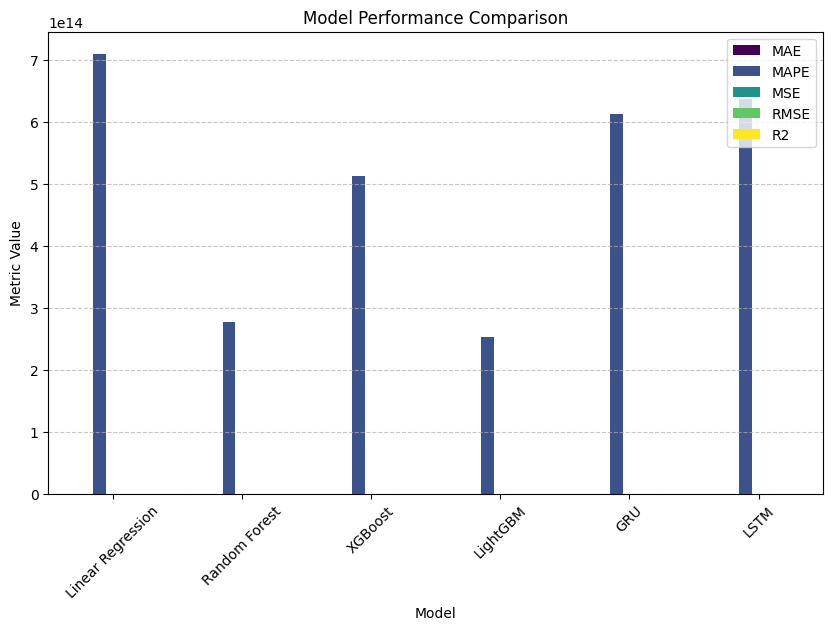

In [476]:
# visualize results

# Convert results to DataFrame
metrics_df = pd.DataFrame(results).T

# Plot MAE, RMSE, and R2
metrics_to_plot = ["MAE", "MAPE", "MSE", "RMSE", "R2"]
metrics_df[metrics_to_plot].plot(kind="bar", figsize=(10, 6), colormap="viridis", rot=45)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Metric Value")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


<h2>plotting prediction of models</h2>

In [ ]:
# for each model
def plot_for_each_model(dates_test, y_test, y_pred_lr, y_pred_ma, y_pred_rf, y_pred_xgb, y_pred_lgb, y_pred_gru, y_pred_hybrid):
    plt.figure(figsize=(12, 6))
    plt.plot(dates_test, y_test, label="Actual", color="blue")
    plt.plot(dates_test, y_pred_lr, label="Linear Regression Predictions", linestyle="--")
    # plt.plot(dates_test, y_pred_ma, label="Moving Average Predictions", linestyle="--")
    plt.plot(dates_test, y_pred_rf, label="Random Forest Predictions", linestyle="--")
    plt.plot(dates_test, y_pred_xgb, label="XGBoost Predictions", linestyle="--")
    plt.plot(dates_test, y_pred_lgb, label="LightGBM Predictions", linestyle="--")
    plt.plot(dates_test, y_pred_gru, label="GRU Predictions", linestyle="--")
    # plt.plot(dates_test, y_pred_transformer, label="Transformer Predictions", linestyle="--")
    plt.xlabel("Flight Date")
    plt.ylabel("Booking Count")
    plt.title("Actual vs Predicted: Model Comparison")
    plt.legend()
    plt.grid()
    plt.show()


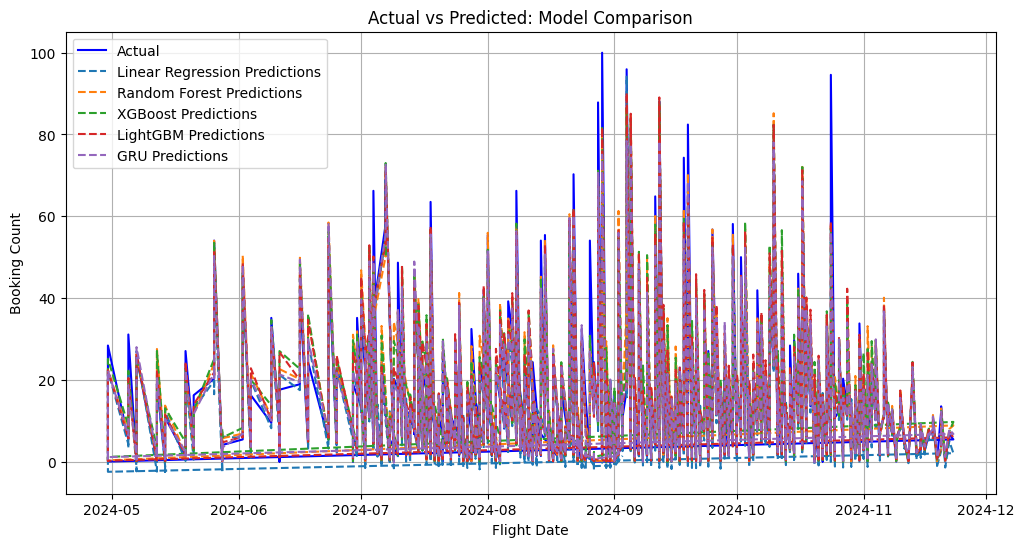

In [ ]:
plot_for_each_model(date_test, y_test, y_pred_lr, y_pred_ma, y_pred_rf, y_pred_xgb, y_pred_lgb, y_pred_gru, y_pred_hybrid)

<h1>evaluation of the LSTM model</h1>

<h2>cross-validation of the LSTM model</h2>

In [53]:

# Perform k-fold cross-validation
avg_metrics = cross_validate_lstm(X_train_scaled, y_train)

Training Fold 1/5
[57.94003677368164, 4.738667011260986, 7.267611503601074]
Fold 1 Metrics: Loss=57.9400, MAE=4.7387, MAPE=7.2676
Training Fold 2/5
[56.05789566040039, 4.633781433105469, 7.221492290496826]
Fold 2 Metrics: Loss=56.0579, MAE=4.6338, MAPE=7.2215
Training Fold 3/5
[52.993099212646484, 4.67533016204834, 7.968916416168213]
Fold 3 Metrics: Loss=52.9931, MAE=4.6753, MAPE=7.9689
Training Fold 4/5
[52.562686920166016, 5.054811000823975, 9.36463451385498]
Fold 4 Metrics: Loss=52.5627, MAE=5.0548, MAPE=9.3646
Training Fold 5/5
[55.49271774291992, 4.668272972106934, 7.343738079071045]
Fold 5 Metrics: Loss=55.4927, MAE=4.6683, MAPE=7.3437

Average Metrics Across 5 Folds:
Loss=55.0093, MAE=4.7542, MAPE=7.8333


<h1>tuning LSTM hyperparameters</h1>

<h2>building the LSTM model</h2>

In [1169]:
#  Define the Model

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

def build_lstm_model(hp):
    model = Sequential()
    
    # First LSTM layer
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))

    # Second LSTM layer
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        return_sequences=False
    ))
    model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))

    # Dense layers
    model.add(Dense(units=hp.Int('dense_units', min_value=16, max_value=64, step=16), activation='relu'))
    model.add(Dense(1))  # Output layer

    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
        loss='mse',
        metrics=['mae', 'mape']
    )
    return model


<h2>tuning the LSTM model</h2>

In [1170]:
# run the tuning
# Initialize tuner
tuner = kt.Hyperband(
    build_lstm_model,
    objective='val_loss',
    max_epochs=60,
    factor=3,
    directory='lstm_tuning',
    project_name='flight_booking_prediction'
)

# Run search
tuner.search(X_train, y_train, validation_split=0.2, epochs=50, callbacks=[
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters: {best_hps.values}")


Trial 84 Complete [00h 00m 30s]
val_loss: 82.69883728027344

Best val_loss So Far: 34.64408874511719
Total elapsed time: 00h 24m 14s
Best Hyperparameters: {'units': 96, 'dropout': 0.1, 'dense_units': 32, 'learning_rate': 0.0032207647478067728, 'tuner/epochs': 60, 'tuner/initial_epoch': 20, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0061'}


<h2>training the best model</h2>

In [1171]:
# train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)]
)

# Evaluate on the test set
test_metrics = best_model.evaluate(X_test, y_test)
print(f"Test Metrics: Loss={test_metrics[0]}, MAE={test_metrics[1]}, MAPE={test_metrics[2]}")


Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 2748.2803 - mae: 44.5017 - mape: 74.5682 - val_loss: 642.8337 - val_mae: 22.5304 - val_mape: 43.4669
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 752.3353 - mae: 23.5453 - mape: 66.6361 - val_loss: 642.0526 - val_mae: 22.5570 - val_mape: 44.6771
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 760.4377 - mae: 23.7199 - mape: 68.3277 - val_loss: 458.1727 - val_mae: 19.0546 - val_mape: 38.1671
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 267.0719 - mae: 12.7506 - mape: 33.0943 - val_loss: 65.0514 - val_mae: 6.5207 - val_mape: 12.5000
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 73.4021 - mae: 6.5539 - mape: 13.5794 - val_loss: 49.0952 - val_mae: 4.9268 - val_mape: 8.4517
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 68.1414 - mae: 6.3631 - mape: 12.7569 - val_loss: 65.2207 - val_mae: 6.4888 - val_mape: 11.5582
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - los

<h2>evaluation of the best model</h2>

23/23 - 0s - 5ms/step - loss: 1475.6556 - mae: 32.5201 - mape: 55.9447
Test Loss: 1475.6556396484375, Test MAE: 32.52005386352539, Test MAPE: 55.9447021484375


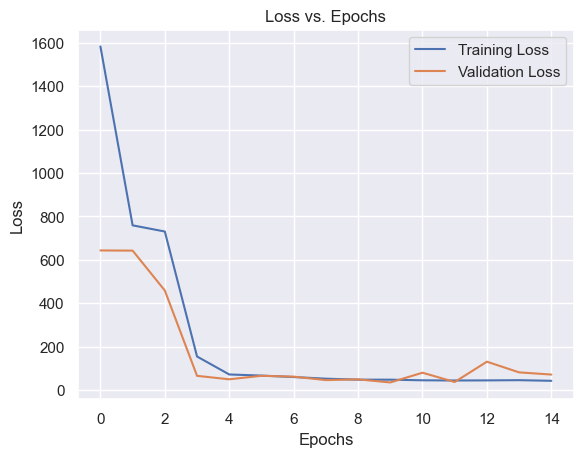

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
MAE: 32.52
MAPE: 0.56
MSE: 1475.66
RMSE: 38.41
MASE: 4.99
R2: -2.67


In [1172]:
test_loss, test_mae, test_mape = best_model.evaluate(X_test_scaled, y_test, verbose=2)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}, Test MAPE: {test_mape}")


# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.show()

predictions = best_model.predict(X_test_scaled)
# print(predictions)

# Calculate evaluation metrics
mae_v = mae(y_test, predictions)
mape_v = mape(y_test, predictions)
mse_v = mse(y_test, predictions)
rmse_v = rmse(y_test, predictions)
mase_v = mase(y_test, predictions, y_train)
r2_v = r2(y_test, predictions)

print(f'MAE: {mae_v:.2f}')
print(f'MAPE: {mape_v:.2f}')
print(f'MSE: {mse_v:.2f}')
print(f'RMSE: {rmse_v:.2f}')
print(f'MASE: {mase_v:.2f}')
print(f'R2: {r2_v:.2f}')

23/23 - 0s - 5ms/step - loss: 107.2762 - mae: 8.7167 - mape: 20.5418
Test Loss: 107.27622985839844, Test MAE: 8.716727256774902, Test MAPE: 20.541818618774414


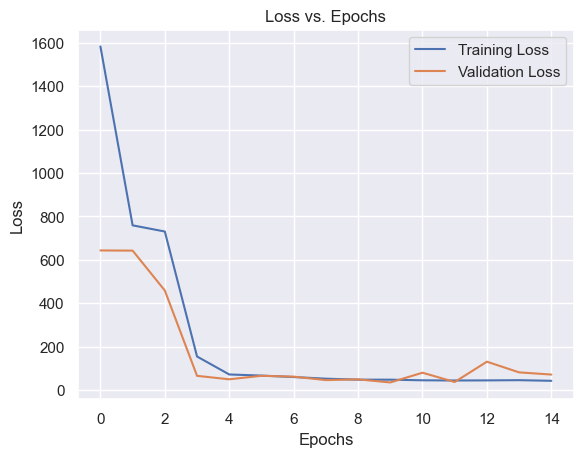

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MAE: 8.72
MAPE: 0.21
MSE: 107.28
RMSE: 10.36
MASE: 3.63
R2: 0.73


In [1173]:
test_loss, test_mae, test_mape = best_model.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}, Test MAPE: {test_mape}")


# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs')
plt.show()

predictions = best_model.predict(X_test)
# print(predictions)

# Calculate evaluation metrics
mae_v = mae(y_test, predictions)
mape_v = mape(y_test, predictions)
mse_v = mse(y_test, predictions)
rmse_v = rmse(y_test, predictions)
mase_v = mase(y_test, predictions, y_train)
r2_v = r2(y_test, predictions)

print(f'MAE: {mae_v:.2f}')
print(f'MAPE: {mape_v:.2f}')
print(f'MSE: {mse_v:.2f}')
print(f'RMSE: {rmse_v:.2f}')
print(f'MASE: {mase_v:.2f}')
print(f'R2: {r2_v:.2f}')

<h1>Misc code snippets</h1>

In [ ]:
# required misc code snippets

# getting object columns
# cat_col = [col for col in processed_input_df.columns if processed_input_df[col].dtype=="object"]
# cat_col

# getting non object columns
# num_col = [col for col in processed_input_df.columns if processed_input_df[col].dtype!="object"]
# num_col


# # One-hot encoding of flight_category
# one_hot_encoded_data = pd.get_dummies(processed_input_df, columns=['route_category'])
# print(one_hot_encoded_data)
# one_hot_encoded_data["route_category_Domestic"].value_counts()